# Adaptive NIDS → Reinforcement-Learning IPS: Full Codebase Lab

This notebook is the single entry point for the project. Each section explains **why the cell exists**, runs the real repository code, and interprets what the current output proves. It distinguishes saved historical model evidence, live tests, simulator evidence, dataset-backed observations, and cyber-range work that is still missing.

## 0 — Runtime controls

`RUN_HEAVY=False` keeps the notebook suitable for a quick demonstration. Set it to `True` for more DQN episodes, five seeds, and the full pytest suite. Training and evaluation seeds remain separate.

In [1]:
from pathlib import Path
import inspect, json, subprocess, sys
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

REPO = Path.cwd().resolve()
if REPO.name == 'notebooks': REPO = REPO.parent
SRC = REPO / 'src'
if str(SRC) not in sys.path: sys.path.insert(0, str(SRC))
RUN_HEAVY = False
SEED = 42
OUTPUT = REPO / 'results' / 'notebook_ips_lab'
OUTPUT.mkdir(parents=True, exist_ok=True)
print({'repo': str(REPO), 'python': sys.version.split()[0], 'run_heavy': RUN_HEAVY, 'output': str(OUTPUT)})

{'repo': "/Users/hexenmeister/Desktop/don't delete update/codes/network-intrusion-detection-ml", 'python': '3.14.6', 'run_heavy': False, 'output': "/Users/hexenmeister/Desktop/don't delete update/codes/network-intrusion-detection-ml/results/notebook_ips_lab"}


## 1 — Dynamic project inventory

This calls the same reporting code as `src/project_benchmark.py`. It discovers dependencies, local datasets, implemented tracks, saved benchmarks, feature representations, and IPS baselines from the current checkout. Missing data remains visible rather than being silently replaced.

In [2]:
import project_benchmark as PB
report = PB.build_report(full=False, episodes=200 if RUN_HEAVY else 50, seed=SEED, output_dir=OUTPUT / 'benchmark')
display(pd.DataFrame(report['datasets']))
display(pd.DataFrame(report['features']))
display(pd.DataFrame(report['tracks']))
print('Artifact counts:', report['artifact_counts'])

,dataset,role,status,limitation
0,NSL-KDD,Controlled baseline for every new method.,available,None for current NSL-KDD baseline; temporal cl...
1,CICIoT2023 dev parquet,Fast modern IoT dev sample for quality checks ...,missing,Do not treat dev-sample results as full offici...
2,CICIoT2023 raw CSV,"Primary modern IoT supervised dataset: binary,...",blocked_missing_local_files,No full raw CSV modelling or quality claim unt...
3,TON_IoT,"Multimodal SOC/EDR-style track: network, IoT t...",blocked_missing_local_files,"No multimodal fusion, host telemetry, or TON_I..."
4,CSE-CIC-IDS2018,Enterprise-scale/day-based drift and chronolog...,available,Only the audited three-day subset is supported...
5,Common NetFlow schema,Cross-dataset generalization using shared NetF...,blocked_missing_local_files,No cross-dataset score is valid without a comm...


,representation,features,details
0,NSL-KDD raw flow,41,3 categorical + 38 numeric; difficulty excluded
1,Adaptive IPS state,7,"threat probability, anomaly, attack stage, com..."
2,CICIoT2023,46,published expected model features; local parqu...


,track,status,evidence
0,Leakage-safe preprocessing,PROVEN,src/preprocess.py + tests
1,Supervised reference models,PROVEN,results/reference_track.csv
2,RF/LightGBM official split,PROVEN,results/metrics.md
3,Weighted/unweighted MLP,PROVEN,results/stability.md
4,Threshold tuning,PROVEN,results/threshold_ablation.csv
5,Normal-only anomaly detection,PROVEN,results/anomaly_detection.csv
6,Semi-supervised learning,PROVEN,results/semi_supervised.csv
7,Online partial-fit proxy,PARTIAL,not chronological drift
8,CICIoT2023 supervised dev,PARTIAL,"random dev split, not full raw CSV"
9,Adaptive IPS environment,PROVEN,src/ips + safety tests


Artifact counts: {'figures': 43, 'csv_results': 26, 'markdown_results': 19, 'test_files': 33}


**How to read the output:** `PROVEN` means code plus saved evidence exists; `PARTIAL` means the method exists but the data/protocol cannot support the full claim; `BLOCKED` identifies the exact missing local data. Dataset availability and saved-result availability are different—committed metrics can exist while raw files are intentionally gitignored.

## 2 — Model training status and metric mathematics

This section shows where every model fitted, how it was selected, where it was evaluated, and the command that reproduces it. The formulas prevent incompatible leaderboards—for example, CICIoT random-dev macro-F1 must not be ranked directly against NSL-KDD official-shift macro-F1.

In [3]:
display(pd.DataFrame(report['model_training']))
display(pd.DataFrame(report['metric_definitions']))
display(pd.DataFrame(report['saved_benchmarks']))

,dataset_task,models,status,fit_selection,evaluation,run
0,NSL-KDD binary + 5-class,"Dummy, LogReg, RF, ExtraTrees, HistGB, LightGBM",TRAINED / SAVED,official train; class balancing; train-only va...,official KDDTest+; macro-F1 + per-class recall,.venv/bin/python src/reference_track.py
1,NSL-KDD binary + 5-class,MLP unweighted + class-weighted,TRAINED / 5-SEED,official train; internal early-stopping valida...,official KDDTest+; macro-F1 and rare-family re...,.venv/bin/python src/train_mlp.py
2,NSL-KDD anomaly,"IsolationForest, LOF, KMeans distance",TRAINED / SAVED,normal training rows only; train-normal quanti...,official KDDTest+ attack/family recall,.venv/bin/python src/anomaly_detection.py
3,CICIoT2023 dev binary + category,"Dummy, LogReg, RF, HistGB, LightGBM",TRAINED / DEV ONLY,stratified 200k train sample; random dev parti...,full dev test partition; not raw/temporal evid...,.venv/bin/python src/ciciot2023_baselines.py
4,Adaptive IPS simulated episodes,"Allow-only, rule-based, aggressive",RUN LIVE IN THIS REPORT,no fitting; identical seeded scenarios,"containment, compromise, disruption, false pre...",.venv/bin/python src/project_benchmark.py
5,Adaptive IPS simulated episodes,Masked Double DQN,IMPLEMENTED / SMOKE WITH --full,training seed range; disjoint validation seed ...,safety-first checkpoint ordering; simulator ev...,.venv/bin/python src/project_benchmark.py --full


,metric,calculation,use
0,accuracy,correct predictions / all predictions,secondary under imbalance
1,per-class recall,TP / (TP + FN) for that class,how many attacks of each family are caught
2,macro-F1,unweighted mean of each class F1; F1=2PR/(P+R),primary classifier comparison
3,weighted-F1,class F1 weighted by class support,overall volume-weighted quality
4,ROC-AUC,area under TPR versus FPR across thresholds,binary ranking; can flatter imbalance
5,PR-AUC,area under precision versus recall,preferred binary ranking under imbalance
6,containment rate,contained attack episodes / attack episodes,IPS prevention outcome
7,compromise rate,compromised attack episodes / attack episodes,lower is better; first checkpoint criterion
8,false prevention,disruptive actions in benign episodes / episodes,availability/safety cost
9,mean return,mean sum of transition rewards per episode,RL objective; never interpreted alone


,track,artifact,status,best_macro_f1,best_method
0,NSL-KDD reference,results/reference_track.csv,missing,NaN,NaN
1,CICIoT2023 dev,results/ciciot2023_baselines.csv,available,0.856267,RandomForest (balanced)
2,Threshold ablation,results/threshold_ablation.csv,available,0.823031,HistGB_balanced
3,Anomaly detection,results/anomaly_detection.csv,available,0.841344,KMeans_distance
4,Semi-supervised,results/semi_supervised.csv,available,0.754244,labelled_only_logreg
5,Online proxy,results/online_learning.csv,available,0.764180,SGD_log_loss_balanced
6,Neural ablation,results/neural_ablation.csv,available,0.775930,NaN


## 3 — Inspect the real implementation

Rather than duplicating source code in notebook cells, this dynamically displays the current implementations. Changes to the Python modules therefore appear here automatically.

In [4]:
from IPython.display import display
from ips.environment import AdaptiveIpsEnv
from ips.actions import valid_action_mask
from ips.train_dqn import optimize_batch
from ips.dataset import build_episodes, split_episodes_by_group
for title, obj in [('Safety mask', valid_action_mask), ('IPS environment step', AdaptiveIpsEnv.step), ('Masked Double-DQN update', optimize_batch), ('Dataset episode builder', build_episodes), ('Group-safe split', split_episodes_by_group)]:
    print('\n###', title)
    print(inspect.getsource(obj))


### Safety mask
def valid_action_mask(
    threat_probability: float,
    critical_service: bool,
    host_compromise: float,
) -> np.ndarray:
    """Return a boolean mask that prevents unjustified disruptive actions.

    The mask is a hard safety layer, independent of what an RL policy proposes.
    Critical hosts require stronger evidence before port blocking or isolation.
    """
    if not 0.0 <= threat_probability <= 1.0:
        raise ValueError("threat_probability must be in [0, 1]")
    if not 0.0 <= host_compromise <= 1.0:
        raise ValueError("host_compromise must be in [0, 1]")

    mask = np.ones(len(IpsAction), dtype=bool)
    mask[IpsAction.TEMP_BLOCK_SOURCE] = threat_probability >= 0.60
    mask[IpsAction.BLOCK_DESTINATION_PORT] = (
        threat_probability >= (0.90 if critical_service else 0.70)
    )
    mask[IpsAction.ISOLATE_HOST] = (
        host_compromise >= (0.90 if critical_service else 0.70)
        and threat_probability >= 0.80
    )
    return mask



## 4 — Live verification

The tests verify schema validation, train/test leakage rules, safety masking, deterministic transitions, Bellman targets, replay memory, checkpoint artifacts, and multi-seed final-test plumbing. Data-dependent tests skip honestly when raw datasets are absent.

In [5]:
test_targets = [] if RUN_HEAVY else ['tests/test_ips_environment.py', 'tests/test_ips_training.py', 'tests/test_ips_dataset.py', 'tests/test_project_benchmark.py']
command = [sys.executable, '-m', 'pytest', '-p', 'no:cacheprovider', *test_targets]
tests = subprocess.run(command, cwd=REPO, text=True, capture_output=True)
print(tests.stdout); print(tests.stderr)
assert tests.returncode == 0, 'Verification failed—inspect the output above before trusting later cells.'

..........................                                               [100%]
26 passed in 0.92s




## 5 — Prevention actions, safety masks, and one episode

The detector supplies risk estimates; the policy selects an intervention. A hard mask outside the learned policy prevents unjustified source blocks, port blocks, or host isolation. This cell prints each transition so reward terms and action overrides are visible.

In [6]:
from ips.actions import IpsAction
from ips.policies import rule_based_policy
env = AdaptiveIpsEnv(max_steps=12, seed=SEED)
obs, info = env.reset(seed=SEED, attack_present=True, critical_service=True)
trajectory = []
while True:
    action = rule_based_policy(obs, info['action_mask'])
    result = env.step(action)
    trajectory.append({'threat': obs.threat_probability, 'stage': obs.attack_stage, 'proposed': action.name, 'executed': result.info['executed_action'], 'masked': result.info['action_was_masked'], 'reward': result.reward, 'contained': result.info['contained'], 'compromised': result.info['compromised']})
    obs, info = result.observation, {'action_mask': result.info['action_mask']}
    if result.terminated or result.truncated or result.info['contained']: break
display(pd.DataFrame(trajectory))
print('Interpretation: positive reward comes from containment; compromise and critical-service disruption are strongly penalized.')

,threat,stage,proposed,executed,masked,reward,contained,compromised
0,0.594377,0.553008,RATE_LIMIT,RATE_LIMIT,False,-0.50,False,False
1,0.413917,0.444578,MONITOR,MONITOR,False,-0.55,False,False
2,0.568656,0.545404,RATE_LIMIT,RATE_LIMIT,False,-0.50,False,False
3,0.575282,0.618359,RATE_LIMIT,RATE_LIMIT,False,-0.50,False,False
4,0.719500,0.637176,DROP_FLOW,DROP_FLOW,False,-0.50,False,False
5,0.675211,0.618117,DROP_FLOW,DROP_FLOW,False,-0.50,False,False
6,0.655734,0.616965,DROP_FLOW,DROP_FLOW,False,8.00,True,False


Interpretation: positive reward comes from containment; compromise and critical-service disruption are strongly penalized.


## 6 — Required policy baselines

RL is credible only if it beats simple policies. All policies below receive identical seeded scenarios. Containment and compromise are conditional on attack episodes; disruption exposes policies that appear secure only by blocking everything.

,episodes,attack_episodes,benign_episodes,mean_return,return_std,containment_rate,compromise_rate,false_preventions_per_episode,disruptive_actions_per_episode,masked_actions_per_episode,mean_steps
policy,,,,,,,,,,,
allow_only,50,26,24,-14.100,13.5643,0.0000,1.0000,0.0,0.00,0.0,26.72
rule_based,50,26,24,2.789,5.8913,0.9615,0.0385,0.0,1.06,0.0,25.12
aggressive,50,26,24,-34.360,43.8501,1.0000,0.0000,9.6,10.36,0.0,10.36


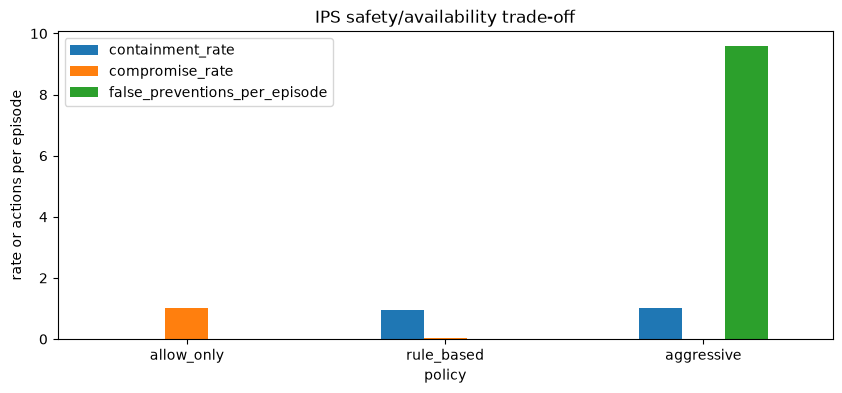

In [7]:
baseline_df = pd.DataFrame(report['ips_baselines']).set_index('policy')
display(baseline_df.round(4))
baseline_df[['containment_rate', 'compromise_rate', 'false_preventions_per_episode']].plot.bar(figsize=(10,4), title='IPS safety/availability trade-off')
plt.ylabel('rate or actions per episode'); plt.xticks(rotation=0); plt.show()

## 7 — Train masked Double DQN

The online network selects the best valid next action and the target network evaluates it. Replay memory breaks temporal correlation; Huber loss limits sensitivity to large penalties; the target network updates periodically. Validation seeds never overlap training seeds. This is still simulator training.

In [8]:
from ips.dqn import DqnConfig
from ips.train_dqn import TrainConfig, train
dqn_config = DqnConfig(hidden_dim=64, batch_size=64, replay_capacity=10000, warmup_steps=128, target_update_steps=250, epsilon_decay_steps=5000)
train_config = TrainConfig(episodes=1000 if RUN_HEAVY else 100, validation_interval=100 if RUN_HEAVY else 25, validation_episodes=300 if RUN_HEAVY else 50)
trained = train(dqn_config, train_config, seed=SEED, output_dir=OUTPUT / 'simulator_dqn')
display(pd.DataFrame([trained.best_validation.to_dict()]))
print('Checkpoint:', trained.best_checkpoint, 'steps:', trained.total_steps, 'updates:', trained.updates)

,episodes,attack_episodes,benign_episodes,mean_return,return_std,containment_rate,compromise_rate,false_preventions_per_episode,disruptive_actions_per_episode,masked_actions_per_episode,mean_steps
0,50,20,30,3.067,3.766664,1.0,0.0,0.0,0.6,0.0,30.66


Checkpoint: /Users/hexenmeister/Desktop/don't delete update/codes/network-intrusion-detection-ml/results/notebook_ips_lab/simulator_dqn/dqn_best.pt steps: 2593 updates: 2466


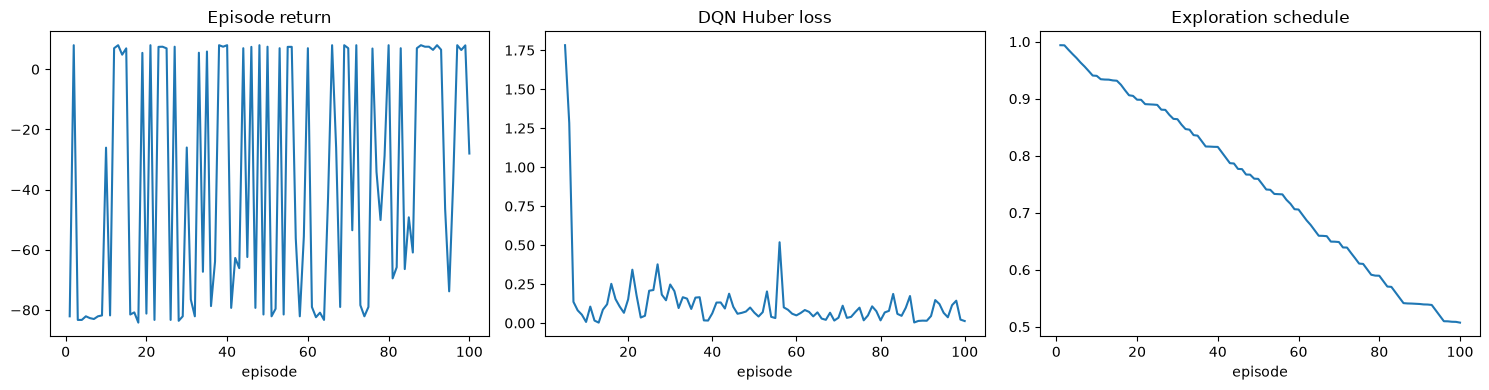

Interpretation: loss need not decrease monotonically in RL. Prevention metrics on disjoint scenarios decide the checkpoint.


In [9]:
history = pd.read_json(trained.history_path, lines=True)
fig, axes = plt.subplots(1, 3, figsize=(15,4))
history.plot(x='episode', y='episode_return', ax=axes[0], title='Episode return', legend=False)
history.dropna(subset=['mean_loss']).plot(x='episode', y='mean_loss', ax=axes[1], title='DQN Huber loss', legend=False)
history.plot(x='episode', y='epsilon', ax=axes[2], title='Exploration schedule', legend=False)
plt.tight_layout(); plt.show()
print('Interpretation: loss need not decrease monotonically in RL. Prevention metrics on disjoint scenarios decide the checkpoint.')

## 8 — Construct dataset-backed episodes

If `data/ips_events/events.parquet` exists, it is loaded. It must contain timestamps, campaign/group IDs, labels, criticality, attack stage, anomaly scores, and **out-of-fold detector probabilities**. Otherwise this cell creates an explicitly synthetic fixture to demonstrate the contract—it never labels that fixture as dataset evidence.

In [10]:
from ips.dataset import build_episodes, split_episodes_by_group, assert_group_disjoint
event_path = REPO / 'data' / 'ips_events' / 'events.parquet'
if event_path.exists():
    events = pd.read_parquet(event_path); evidence_kind = 'REAL DATASET-BACKED OBSERVATIONS'
else:
    rng = np.random.default_rng(SEED); rows=[]
    family_cycle = ['normal','DoS','Probe','BruteForce','Exploitation','R2L','U2R']
    for group in range(350 if RUN_HEAVY else 140):
        family = family_cycle[group % len(family_cycle)]; attack = family != 'normal'
        for step in range(6):
            rows.append({'episode_id': f'ep-{group}', 'group_id': f'campaign-{group}', 'timestamp': float(step), 'threat_probability': float(np.clip(rng.normal(0.72 if attack else 0.15, .1),0,1)), 'anomaly_score': float(np.clip(rng.normal(0.75 if attack else 0.2,.1),0,1)), 'attack_present': attack, 'attack_stage': (step+1)/6 if attack else 0.0, 'critical_service': group%5==0, 'attack_family': family})
    events = pd.DataFrame(rows); evidence_kind = 'SYNTHETIC CONTRACT FIXTURE — NOT DATASET EVIDENCE'
episodes = build_episodes(events)
splits = split_episodes_by_group(episodes, seed=SEED)
assert_group_disjoint(splits)
print(evidence_kind)
display(events.head())
display(pd.DataFrame([{'split': name, 'episodes': len(value), 'groups': len({e.group_id for e in value}), 'attack_episodes': sum(e.contains_attack for e in value)} for name, value in [('train', splits.train), ('validation', splits.validation), ('final_test', splits.test)]]))

SYNTHETIC CONTRACT FIXTURE — NOT DATASET EVIDENCE


,episode_id,group_id,timestamp,threat_probability,anomaly_score,attack_present,attack_stage,critical_service,attack_family
0,ep-0,campaign-0,0.0,0.180472,0.096002,False,0.0,True,normal
1,ep-0,campaign-0,1.0,0.225045,0.294056,False,0.0,True,normal
2,ep-0,campaign-0,2.0,0.000000,0.069782,False,0.0,True,normal
3,ep-0,campaign-0,3.0,0.162784,0.168376,False,0.0,True,normal
4,ep-0,campaign-0,4.0,0.148320,0.114696,False,0.0,True,normal


,split,episodes,groups,attack_episodes
0,train,98,98,85
1,validation,21,21,16
2,final_test,21,21,19


## 9 — Multi-seed dataset-backed experiment

Each seed independently trains on training episodes. Validation chooses that seed's checkpoint. The final-test split is then evaluated once. Mean ± standard deviation is reported across seeds. Observations may be real; action outcomes remain counterfactual until cyber-range interventions replace them.

In [11]:
from ips.dataset_experiment import DatasetTrainConfig, run_multi_seed
seeds = (42,43,44,45,46) if RUN_HEAVY else (42,43,44)
dataset_dqn = DqnConfig(hidden_dim=32, batch_size=16, replay_capacity=2000, warmup_steps=32, target_update_steps=50, epsilon_decay_steps=1000)
dataset_training = DatasetTrainConfig(episodes=500 if RUN_HEAVY else 40, validation_interval=100 if RUN_HEAVY else 20)
per_seed = run_multi_seed(splits, seeds=seeds, dqn=dataset_dqn, training=dataset_training, output_dir=OUTPUT / 'dataset_multi_seed')
display(per_seed.round(4))
summary = per_seed.drop(columns='seed').agg(['mean','std']).T
display(summary.round(4))
print('Evidence label:', evidence_kind)

,seed,episodes,attack_episodes,containment_rate,compromise_rate,false_preventions_per_episode,disruptive_actions_per_episode,mean_return,return_std
0,42,21,19,1.0,0.0,0.5714,1.8095,4.7857,9.3447
1,43,21,19,1.0,0.0,0.0000,1.1905,7.0000,2.2991
2,44,21,19,1.0,0.0,0.0000,1.0952,6.9190,2.8418


,mean,std
episodes,21.0000,0.0000
attack_episodes,19.0000,0.0000
containment_rate,1.0000,0.0000
compromise_rate,0.0000,0.0000
false_preventions_per_episode,0.1905,0.3299
disruptive_actions_per_episode,1.3651,0.3878
mean_return,6.2349,1.2557
return_std,4.8285,3.9205


Evidence label: SYNTHETIC CONTRACT FIXTURE — NOT DATASET EVIDENCE


## 10 — Candidate model discovery: measured versus theoretical

The executed candidate set varies DQN capacity, horizon discount, learning rate, batch size, and target-update frequency because these directly affect discrete sequential control. Masked PPO, constrained PPO, and a contextual bandit are listed separately as theoretically justified but **not executed** in this notebook. Quantization and context length are not relevant here: this is a small FP32 control network, not a language model.

In [12]:
from ips.analysis.experiments import DEFAULT_CANDIDATES, THEORETICAL_CANDIDATES, parameter_count, factorial_candidates
executed_catalog = pd.DataFrame([{**c.__dict__, 'parameters': parameter_count(c), 'quantization': 'FP32', 'executed': True} for c in DEFAULT_CANDIDATES])
theory_catalog = pd.DataFrame(THEORETICAL_CANDIDATES)
display(executed_catalog)
display(theory_catalog)
print('Interpretation: DQN variants can run comfortably on CPU because even the largest tested network has only thousands of parameters. PPO remains a recommendation, not a benchmark result.')

,name,hidden_dim,gamma,learning_rate,batch_size,target_update_steps,episodes,parameters,quantization,executed
0,DQN-small-fast,16,0.95,0.0010,16,50,60,519,FP32,True
1,DQN-small-long-horizon,16,0.99,0.0010,16,50,60,519,FP32,True
2,DQN-balanced,32,0.99,0.0010,32,75,60,1543,FP32,True
3,DQN-low-lr,32,0.99,0.0003,32,75,60,1543,FP32,True
4,DQN-large,64,0.99,0.0010,32,100,60,5127,FP32,True
5,DQN-large-batch,64,0.99,0.0010,64,100,60,5127,FP32,True


,model,executed,why,strength,weakness,environment_fit
0,Masked PPO,False,stable policy-gradient comparison with the sam...,less sensitive than DQN to Q-value scale and r...,less sample-efficient; needs a vectorized envi...,realistic after dataset episodes and reward se...
1,Constrained PPO,False,separates prevention reward from explicit disr...,directly models an availability/safety budget,more complex optimization and multiplier tuning,recommended final simulator/cyber-range policy
2,Contextual bandit,False,tests whether sequential credit assignment is ...,"simple, fast, highly interpretable baseline",cannot value delayed containment or attack pro...,strong additional baseline


Interpretation: DQN variants can run comfortably on CPU because even the largest tested network has only thousands of parameters. PPO remains a recommendation, not a benchmark result.


## 11 — Controlled multi-configuration benchmark

Every candidate uses the same campaign-disjoint split and final-test episodes. Runtime is wall-clock time, checkpoint memory is serialized model size, and peak memory is measured with Python `tracemalloc`—it does not include every native allocator, so it is a comparative development metric rather than total process RAM.

In [13]:
from ips.analysis.experiments import benchmark_candidates, add_objective_scores
candidates = factorial_candidates(episodes=120 if RUN_HEAVY else 30)
bench = benchmark_candidates(splits, candidates=candidates, seed=SEED, output_dir=OUTPUT / 'candidate_benchmark')
bench = add_objective_scores(bench)
comparison_cols = ['name','parameters','quantization','checkpoint_mb','peak_python_memory_mb','runtime_s','throughput_steps_s','containment_rate','compromise_rate','false_preventions_per_episode','safety_quality','pareto_optimal']
display(bench[comparison_cols].sort_values('safety_quality', ascending=False).round(4))
print('Result:', bench.loc[bench.safety_quality.idxmax(), 'name'], 'has the highest observed safety quality.')
print('Next implication: inspect whether that gain survives runtime/memory trade-offs and parameter sensitivity before selecting it.')

,name,parameters,quantization,checkpoint_mb,peak_python_memory_mb,runtime_s,throughput_steps_s,containment_rate,compromise_rate,false_preventions_per_episode,safety_quality,pareto_optimal
0,DQN-h16-b16,519,FP32,0.0052,0.2981,0.0711,872.4418,1.000,0.000,0.0000,1.0000,False
1,DQN-h16-b32,519,FP32,0.0052,0.2442,0.0510,1216.2606,1.000,0.000,0.0000,1.0000,False
2,DQN-h16-b64,519,FP32,0.0052,0.2441,0.0508,1221.2527,1.000,0.000,0.0000,1.0000,True
6,DQN-h64-b16,5127,FP32,0.0228,0.2504,0.0713,869.5551,1.000,0.000,0.0000,1.0000,False
7,DQN-h64-b32,5127,FP32,0.0228,0.2427,0.0521,1189.7433,1.000,0.000,0.0000,1.0000,False
8,DQN-h64-b64,5127,FP32,0.0228,0.2434,0.0518,1196.6244,1.000,0.000,0.0000,1.0000,False
3,DQN-h32-b16,1543,FP32,0.0091,0.2523,0.0758,818.1102,1.000,0.000,1.4286,0.9286,False
4,DQN-h32-b32,1543,FP32,0.0091,0.2438,0.0645,961.3832,0.875,0.125,0.0000,0.7500,False
5,DQN-h32-b64,1543,FP32,0.0091,0.2428,0.0643,964.9780,0.875,0.125,0.0000,0.7500,False


Result: DQN-h16-b16 has the highest observed safety quality.
Next implication: inspect whether that gain survives runtime/memory trade-offs and parameter sensitivity before selecting it.


## 12 — Visual model comparison and Pareto frontier

A model is Pareto-optimal when no other measured configuration is at least as good in quality, runtime, and checkpoint size while being strictly better in one. Dominated candidates are usually poor follow-up choices unless they contribute stability or an unmeasured operational property.

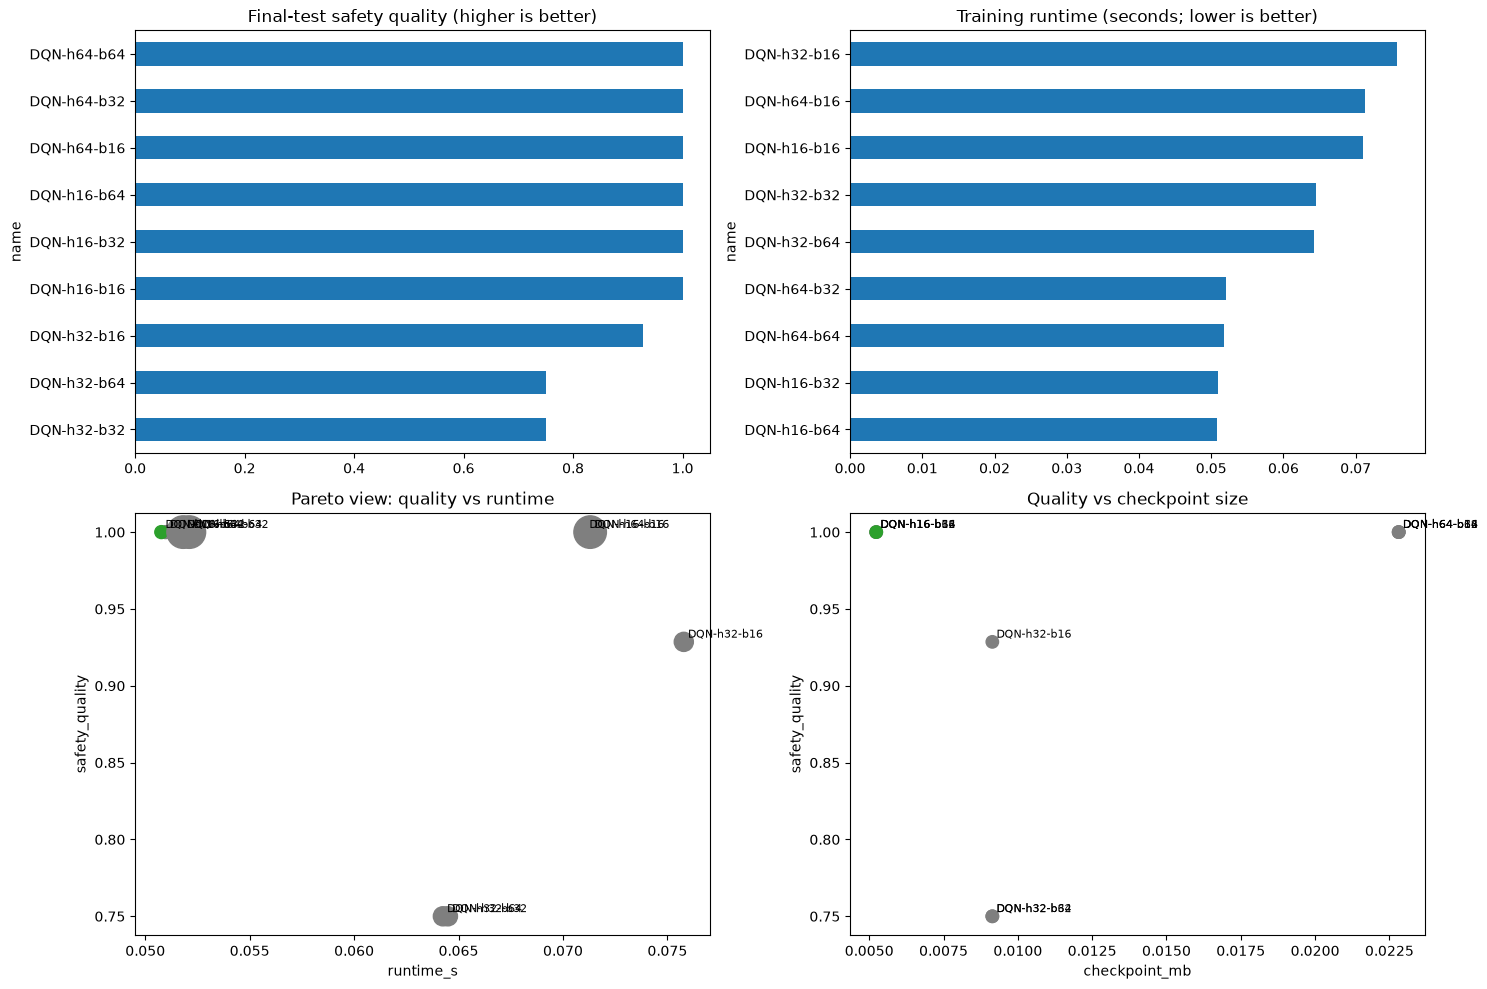

Pareto candidates: DQN-h16-b64


In [14]:
fig, axes = plt.subplots(2, 2, figsize=(15,10))
bench.sort_values('safety_quality').plot.barh(x='name', y='safety_quality', ax=axes[0,0], legend=False, title='Final-test safety quality (higher is better)')
bench.sort_values('runtime_s').plot.barh(x='name', y='runtime_s', ax=axes[0,1], legend=False, title='Training runtime (seconds; lower is better)')
bench.plot.scatter(x='runtime_s', y='safety_quality', s=bench.parameters/10+35, c=bench.pareto_optimal.map({True:'tab:green',False:'tab:gray'}), ax=axes[1,0], title='Pareto view: quality vs runtime')
bench.plot.scatter(x='checkpoint_mb', y='safety_quality', s=80, c=bench.pareto_optimal.map({True:'tab:green',False:'tab:gray'}), ax=axes[1,1], title='Quality vs checkpoint size')
for ax in (axes[1,0], axes[1,1]):
    for _, r in bench.iterrows(): ax.annotate(r['name'], (r[ax.get_xlabel()], r['safety_quality']), fontsize=8, xytext=(3,3), textcoords='offset points')
plt.tight_layout(); plt.show()
print('Pareto candidates:', ', '.join(bench.loc[bench.pareto_optimal, 'name']))

## 13 — Parameter impact and sensitivity

Spearman correlation measures monotonic association and is appropriate for this small, non-Gaussian grid. It does not establish causality, especially because parameters were not varied in a full factorial design. Sensitivity plots reveal whether larger capacity or batch size improves quality consistently or only in certain regions.

,parameter,rho_safety_quality,rho_runtime_s,rho_checkpoint_mb,rho_throughput_steps_s,importance
0,hidden_dim,0.000,0.264,1.0,-0.264,1.000
3,batch_size,-0.094,-0.791,0.0,0.791,0.791
1,gamma,NaN,NaN,NaN,NaN,NaN
2,learning_rate,NaN,NaN,NaN,NaN,NaN
4,target_update_steps,NaN,NaN,NaN,NaN,NaN


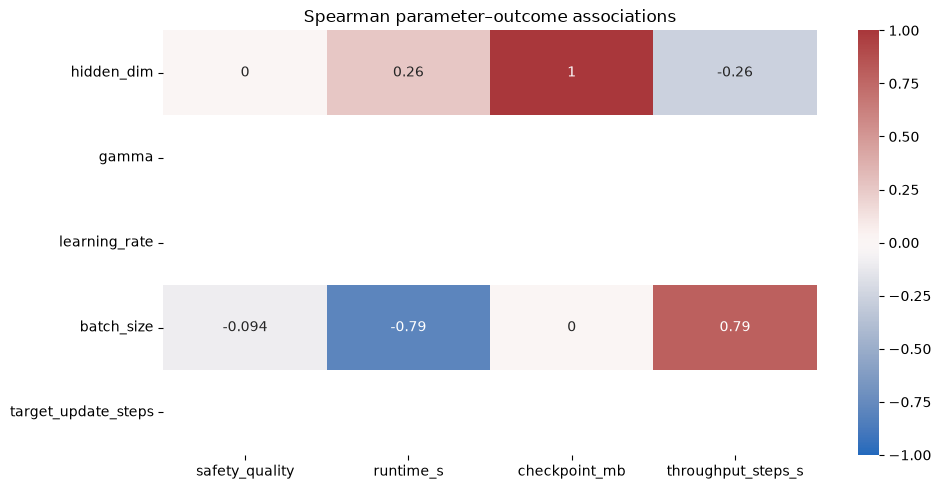

Most influential measured parameter: hidden_dim (max |rho|=1.00). Treat as association, not causal importance.


In [15]:
import seaborn as sns
from ips.analysis.experiments import parameter_effects
effects = parameter_effects(bench)
display(effects.round(3))
params = ['hidden_dim','gamma','learning_rate','batch_size','target_update_steps']
outs = ['safety_quality','runtime_s','checkpoint_mb','throughput_steps_s']
corr = bench[params+outs].corr(method='spearman').loc[params, outs]
plt.figure(figsize=(10,5)); sns.heatmap(corr, annot=True, center=0, cmap='vlag', vmin=-1, vmax=1)
plt.title('Spearman parameter–outcome associations'); plt.tight_layout(); plt.show()
top_effect = effects.iloc[0]
print(f"Most influential measured parameter: {top_effect.parameter} (max |rho|={top_effect.importance:.2f}). Treat as association, not causal importance.")

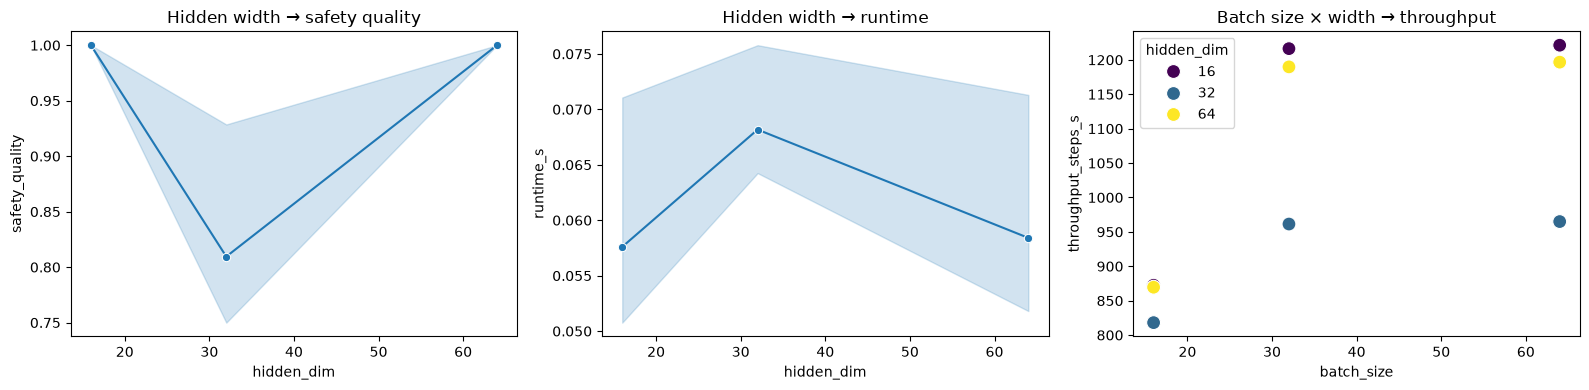

Expected: width generally increases parameter/checkpoint cost. Observed quality may be non-monotonic because additional capacity does not guarantee better policy learning.


In [16]:
fig, axes = plt.subplots(1, 3, figsize=(16,4))
sns.lineplot(data=bench, x='hidden_dim', y='safety_quality', marker='o', ax=axes[0]); axes[0].set_title('Hidden width → safety quality')
sns.lineplot(data=bench, x='hidden_dim', y='runtime_s', marker='o', ax=axes[1]); axes[1].set_title('Hidden width → runtime')
sns.scatterplot(data=bench, x='batch_size', y='throughput_steps_s', hue='hidden_dim', palette='viridis', s=100, ax=axes[2]); axes[2].set_title('Batch size × width → throughput')
plt.tight_layout(); plt.show()
print('Expected: width generally increases parameter/checkpoint cost. Observed quality may be non-monotonic because additional capacity does not guarantee better policy learning.')

## 14 — Parameter interactions

The grid supports a bounded width × batch-size interaction view. Blank combinations were not executed and must not be interpolated as measured evidence. A surprising reversal—where a larger batch helps one width but hurts another—is a reason to run a factorial follow-up.

batch_size,16,32,64
hidden_dim,,,
16,1.000,1.00,1.00
32,0.929,0.75,0.75
64,1.000,1.00,1.00


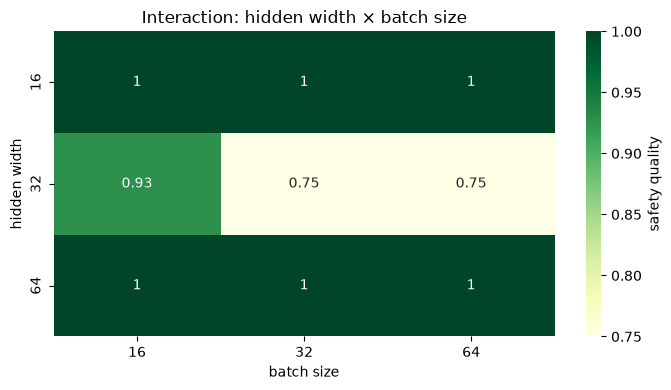

Observed 9/9 interaction cells. Next step should fill missing cells before strong interaction claims.


In [17]:
from ips.analysis.experiments import interaction_table
interaction = interaction_table(bench)
display(interaction.round(3))
plt.figure(figsize=(7,4)); sns.heatmap(interaction, annot=True, cmap='YlGn', cbar_kws={'label':'safety quality'})
plt.title('Interaction: hidden width × batch size'); plt.ylabel('hidden width'); plt.xlabel('batch size'); plt.tight_layout(); plt.show()
observed_cells = int(interaction.notna().sum().sum())
print(f'Observed {observed_cells}/{interaction.size} interaction cells. Next step should fill missing cells before strong interaction claims.')

## 15 — Automatic outlier detection and root-cause association

Robust median absolute deviation (MAD) is used because benchmark grids are small and runtime distributions can be skewed. Runs are never deleted automatically. For each flagged run, the notebook names the anomalous outcome and the most unusual tested parameter, explicitly labelling this as association rather than causation.

,name,outlier_score,runtime_s,peak_python_memory_mb,safety_quality,outlier_explanation
0,DQN-h16-b16,27.799,0.071,0.298,1.000,peak_python_memory_mb is robustly above median...
3,DQN-h32-b16,4.226,0.076,0.252,0.929,peak_python_memory_mb is robustly above median...


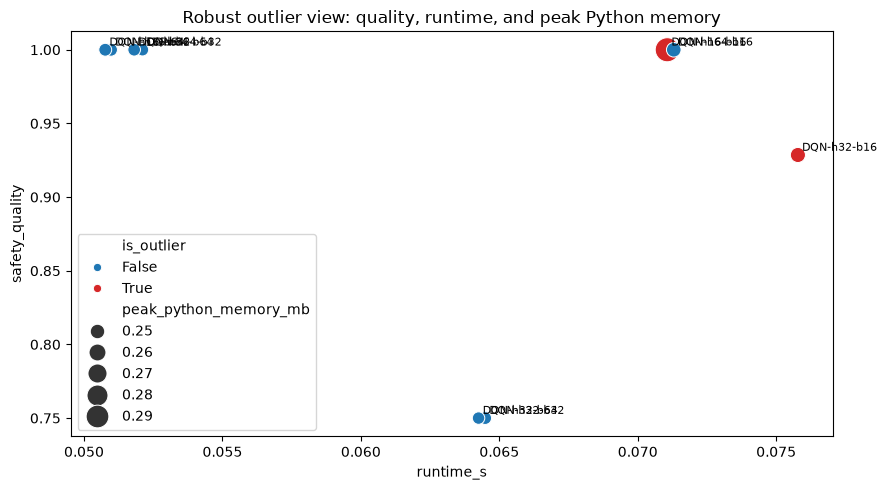

Detected outliers: 2 — retain and investigate them; do not silently remove them.


In [18]:
from ips.analysis.experiments import detect_outliers
diagnosed = detect_outliers(bench)
outliers = diagnosed[diagnosed.is_outlier]
display(outliers[['name','outlier_score','runtime_s','peak_python_memory_mb','safety_quality','outlier_explanation']].round(3))
plt.figure(figsize=(9,5)); sns.scatterplot(data=diagnosed, x='runtime_s', y='safety_quality', hue='is_outlier', size='peak_python_memory_mb', sizes=(80,300), palette={False:'tab:blue',True:'tab:red'})
for _, r in diagnosed.iterrows(): plt.annotate(r['name'], (r.runtime_s,r.safety_quality), fontsize=8, xytext=(3,3), textcoords='offset points')
plt.title('Robust outlier view: quality, runtime, and peak Python memory'); plt.tight_layout(); plt.show()
print('Detected outliers:', len(outliers), '— retain and investigate them; do not silently remove them.')

## 16 — Statistical reliability

The earlier dataset-backed DQN run supplies repeated final-test measurements. Mean, median, standard deviation, range, coefficient of variation, and a normal-approximation 95% confidence interval are shown. With only three quick-mode seeds, intervals are descriptive; heavy mode's five seeds is the minimum project standard.

,mean,median,std,min,max,cv,ci95_halfwidth
episodes,21.0000,21.0000,0.0000,21.0000,21.0000,0.0000,0.0000
attack_episodes,19.0000,19.0000,0.0000,19.0000,19.0000,0.0000,0.0000
containment_rate,1.0000,1.0000,0.0000,1.0000,1.0000,0.0000,0.0000
compromise_rate,0.0000,0.0000,0.0000,0.0000,0.0000,NaN,0.0000
false_preventions_per_episode,0.1905,0.0000,0.3299,0.0000,0.5714,1.7321,0.3733
disruptive_actions_per_episode,1.3651,1.1905,0.3878,1.0952,1.8095,0.2841,0.4389
mean_return,6.2349,6.9190,1.2557,4.7857,7.0000,0.2014,1.4210
return_std,4.8285,2.8418,3.9205,2.2991,9.3447,0.8119,4.4365


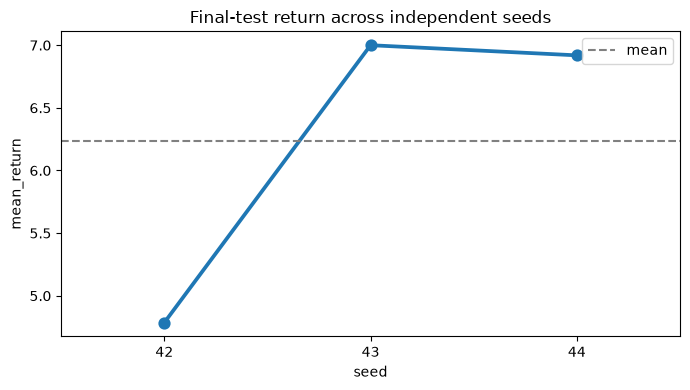

If confidence intervals overlap materially between finalists, report a tie and collect more seeds rather than naming a winner.


In [19]:
numeric = per_seed.select_dtypes('number').drop(columns='seed')
reliability = pd.DataFrame({'mean':numeric.mean(), 'median':numeric.median(), 'std':numeric.std(ddof=1), 'min':numeric.min(), 'max':numeric.max()})
reliability['cv'] = reliability['std'] / reliability['mean'].abs().replace(0,np.nan)
reliability['ci95_halfwidth'] = 1.96 * reliability['std'] / np.sqrt(len(per_seed))
display(reliability.round(4))
metric='mean_return'; plt.figure(figsize=(7,4)); sns.pointplot(data=per_seed, x='seed', y=metric, errorbar=None); plt.axhline(per_seed[metric].mean(), ls='--', color='gray', label='mean'); plt.title('Final-test return across independent seeds'); plt.legend(); plt.tight_layout(); plt.show()
print('If confidence intervals overlap materially between finalists, report a tie and collect more seeds rather than naming a winner.')

## 17 — Optimal configurations and dynamic recommendations

There is no universal best model. Quality, speed, memory, and overall winners are calculated independently. The overall score is transparent: 60% normalized safety quality, 25% speed, and 15% checkpoint memory. Change these weights if deployment priorities differ.

In [20]:
from ips.analysis.experiments import objective_winners, dynamic_recommendations
winners = objective_winners(bench)
display(winners[['objective','name','safety_quality','runtime_s','checkpoint_mb','overall_score','pareto_optimal']].round(4))
recommendations = dynamic_recommendations(bench)
for message in recommendations: print('•', message)

,objective,name,safety_quality,runtime_s,checkpoint_mb,overall_score,pareto_optimal
0,best_quality,DQN-h16-b16,1.0,0.0711,0.0052,0.7972,False
1,fastest,DQN-h16-b64,1.0,0.0508,0.0052,1.0000,True
2,lowest_checkpoint_memory,DQN-h16-b16,1.0,0.0711,0.0052,0.7972,False
3,best_overall_60Q_25S_15M,DQN-h16-b64,1.0,0.0508,0.0052,1.0000,True


• Best observed overall trade-off: DQN-h16-b64 (score=1.000).
• Quality priority: DQN-h16-b16 with safety_quality=1.000.
• Speed priority: DQN-h16-b64 at 0.051s.
• Strongest measured monotonic association: hidden_dim (max |Spearman rho|=1.00).
• Pareto candidates: DQN-h16-b64.
• Next experiment: add an intermediate/extended hidden-width point to resolve the quality-cost curve.
• Reliability gap: repeat Pareto finalists across at least five seeds before declaring a winner.
• Model-family gap: benchmark a contextual bandit and masked PPO only after the DQN reward-sensitivity check.


## 18 — Dynamic experiment dashboard

This compact dashboard is generated entirely from the current run. Rerunning with different candidates, data, or seeds updates every winner, outlier count, influential parameter, Pareto set, and next recommendation.

In [21]:
best_quality = winners.set_index('objective').loc['best_quality']
fastest = winners.set_index('objective').loc['fastest']
lowest_memory = winners.set_index('objective').loc['lowest_checkpoint_memory']
best_overall = winners.set_index('objective').loc['best_overall_60Q_25S_15M']
dashboard = pd.Series({'experiments_executed':len(bench), 'models_compared':bench.name.nunique(), 'configurations_tested':len(bench), 'best_quality':f"{best_quality['name']} ({best_quality['safety_quality']:.3f})", 'fastest':f"{fastest['name']} ({fastest['runtime_s']:.3f}s)", 'lowest_memory':f"{lowest_memory['name']} ({lowest_memory['checkpoint_mb']:.3f} MB)", 'best_overall':best_overall['name'], 'detected_outliers':len(outliers), 'most_influential_parameter':effects.iloc[0].parameter, 'interaction_coverage':f'{observed_cells}/{interaction.size}', 'pareto_candidates':', '.join(bench.loc[bench.pareto_optimal,'name']), 'recommended_next_experiment':recommendations[-1]}, name='Current dynamic result')
display(dashboard.to_frame())
dashboard.to_json(OUTPUT / 'experiment_dashboard.json', indent=2)

,Current dynamic result
experiments_executed,9
models_compared,9
configurations_tested,9
best_quality,DQN-h16-b16 (1.000)
fastest,DQN-h16-b64 (0.051s)
lowest_memory,DQN-h16-b16 (0.005 MB)
best_overall,DQN-h16-b64
detected_outliers,2
most_influential_parameter,hidden_dim
interaction_coverage,9/9


## 19 — Interim interpretation before advanced evidence tests

A strong result requires all of the following: group-disjoint episodes, out-of-fold detector scores, at least three RL seeds, validation-only checkpoint selection, one final-test evaluation per seed, and comparison against allow/rule/aggressive policies. If this notebook used the synthetic fixture, it proves software correctness only. The next evidence gate is creating `data/ips_events/events.parquet` from a timestamped dataset, followed by contained cyber-range intervention logs that can replace counterfactual outcomes.

In [22]:
final = {'evidence_kind': evidence_kind, 'tests_passed': tests.returncode == 0, 'simulator_dqn': trained.best_validation.to_dict(), 'dataset_multi_seed_mean': per_seed.drop(columns='seed').mean(numeric_only=True).to_dict(), 'dataset_multi_seed_std': per_seed.drop(columns='seed').std(ddof=0, numeric_only=True).to_dict()}
(OUTPUT / 'notebook_summary.json').write_text(json.dumps(final, indent=2, sort_keys=True)+'\n', encoding='utf-8')
display(pd.Series(final, name='current project conclusion'))
print('Saved:', OUTPUT / 'notebook_summary.json')

evidence_kind              SYNTHETIC CONTRACT FIXTURE — NOT DATASET EVIDENCE
tests_passed                                                            True
simulator_dqn              {'episodes': 50, 'attack_episodes': 20, 'benig...
dataset_multi_seed_mean    {'episodes': 21.0, 'attack_episodes': 19.0, 'c...
dataset_multi_seed_std     {'episodes': 0.0, 'attack_episodes': 0.0, 'con...
Name: current project conclusion, dtype: object

Saved: /Users/hexenmeister/Desktop/don't delete update/codes/network-intrusion-detection-ml/results/notebook_ips_lab/notebook_summary.json


## 20 — Real timestamped dataset adapter

The adapter reads CSV/Parquet traffic, excludes configured identifiers and labels from detector features, creates campaign/time-window episodes, and generates group-safe out-of-fold HistGB probabilities plus benign-only Isolation Forest anomaly scores. It never guesses group columns because a wrong grouping would invalidate the experiment.

In [23]:
from ips.adapters.real_events import AdapterConfig, write_events
source_config_path = REPO / 'data' / 'ips_events' / 'source_config.json'
if source_config_path.exists():
    source_spec = json.loads(source_config_path.read_text())
    events = write_events(REPO/source_spec['source'], event_path, AdapterConfig(**source_spec['adapter']))
    episodes=build_episodes(events); splits=split_episodes_by_group(episodes,seed=SEED); assert_group_disjoint(splits)
    evidence_kind='REAL DATASET-BACKED OBSERVATIONS WITH GROUP-SAFE OOF SCORES'
    adapter_status={'status':'generated','source':source_spec['source'],'events':len(events),'episodes':len(episodes),'groups':events.group_id.nunique()}
else:
    adapter_status={'status':'blocked_missing_source_config','required':'data/ips_events/source_config.json','output':'data/ips_events/events.parquet','safeguard':'No raw schema/group IDs guessed'}
display(pd.Series(adapter_status,name='real-data adapter status').to_frame())
print('CLI example: python -m ips.adapters.real_events SOURCE.csv --timestamp-col Timestamp --label-col Label --group-cols "Source IP,Destination IP"')
print('Current evidence:',evidence_kind)

,real-data adapter status
status,blocked_missing_source_config
required,data/ips_events/source_config.json
output,data/ips_events/events.parquet
safeguard,No raw schema/group IDs guessed


CLI example: python -m ips.adapters.real_events SOURCE.csv --timestamp-col Timestamp --label-col Label --group-cols "Source IP,Destination IP"
Current evidence: SYNTHETIC CONTRACT FIXTURE — NOT DATASET EVIDENCE


## 21 — Family containment, action behavior, reward sensitivity, and detector stress

This loads the best validation-selected DQN, reports containment by family, shows every executed action, sweeps the four central reward terms, and corrupts detector telemetry without changing ground truth. These views expose rare-family failure, over-blocking, reward fragility, and unsafe behavior under uncertainty.

,selected DQN
episodes,21.000000
attack_episodes,19.000000
containment_rate,1.000000
compromise_rate,0.000000
false_preventions_per_episode,0.000000
mean_return,7.023810
return_std,2.301533


,attack_family,episodes,contained,compromised,containment_rate,compromise_rate
0,BruteForce,4,4,0,1.0,0.0
1,DoS,1,1,0,1.0,0.0
2,Exploitation,3,3,0,1.0,0.0
3,Probe,5,5,0,1.0,0.0
4,R2L,4,4,0,1.0,0.0
5,U2R,2,2,0,1.0,0.0


,action,count,fraction
0,ALLOW,14,0.35
1,MONITOR,0,0.00
2,RATE_LIMIT,0,0.00
3,DROP_FLOW,0,0.00
4,TEMP_BLOCK_SOURCE,26,0.65
5,BLOCK_DESTINATION_PORT,0,0.00
6,ISOLATE_HOST,0,0.00


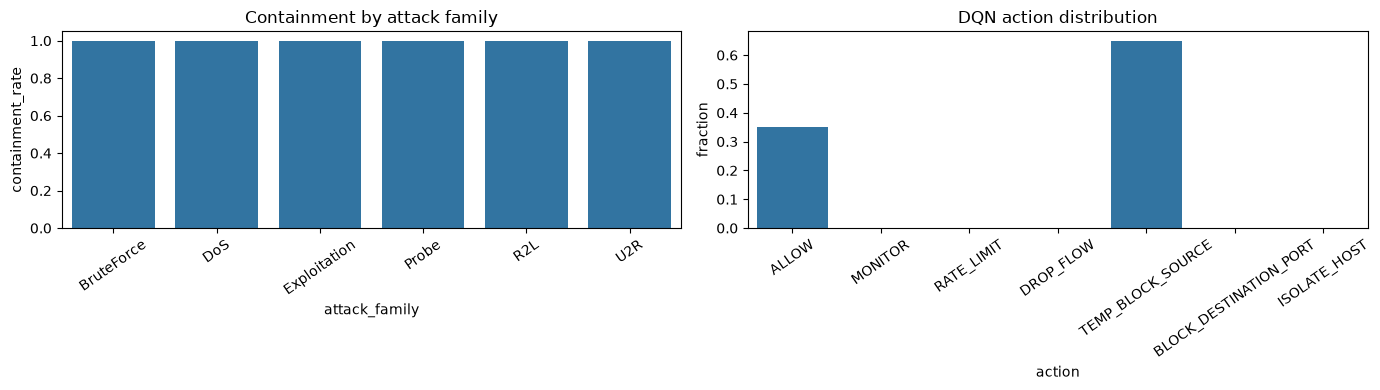

Missing target families: none


,parameter,value,episodes,attack_episodes,containment_rate,compromise_rate,false_preventions_per_episode,mean_return,return_std
0,contained_attack,4.0,21.0,19.0,1.0,0.0,0.0,3.4048,1.1508
1,contained_attack,8.0,21.0,19.0,1.0,0.0,0.0,7.0238,2.3015
2,contained_attack,12.0,21.0,19.0,1.0,0.0,0.0,10.6429,3.4680
3,successful_compromise,-15.0,21.0,19.0,1.0,0.0,0.0,7.0238,2.3015
4,successful_compromise,-25.0,21.0,19.0,1.0,0.0,0.0,7.0238,2.3015
5,successful_compromise,-40.0,21.0,19.0,1.0,0.0,0.0,7.0238,2.3015
6,false_prevention,-2.0,21.0,19.0,1.0,0.0,0.0,7.0238,2.3015
7,false_prevention,-4.0,21.0,19.0,1.0,0.0,0.0,7.0238,2.3015
8,false_prevention,-8.0,21.0,19.0,1.0,0.0,0.0,7.0238,2.3015
9,critical_service_disruption,-6.0,21.0,19.0,1.0,0.0,0.0,7.0238,2.3015


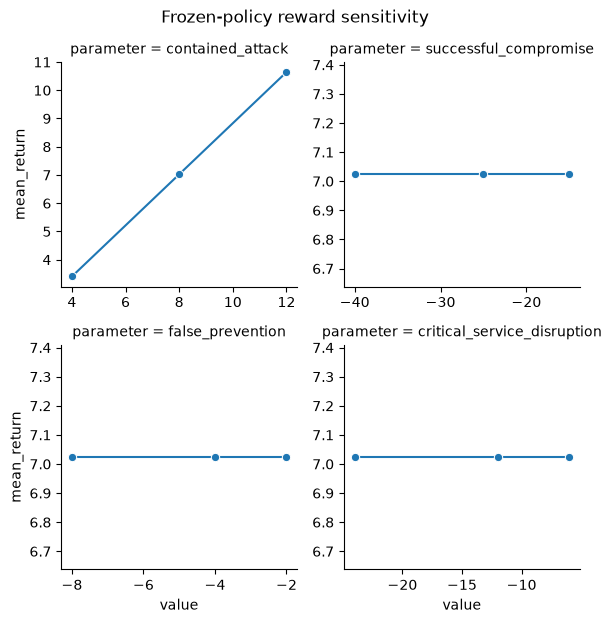

,scenario,score_noise,false_positive_shift,telemetry_dropout,episodes,attack_episodes,containment_rate,compromise_rate,false_preventions_per_episode,mean_return,return_std
0,clean,0.00,0.0,0.00,21.0,19.0,1.0,0.0,0.0000,7.0952,2.3177
1,score_noise_0.10,0.10,0.0,0.00,21.0,19.0,1.0,0.0,0.0000,7.0000,2.2939
2,score_noise_0.25,0.25,0.0,0.00,21.0,19.0,1.0,0.0,0.0952,6.4048,3.4317
3,benign_shift_0.20,0.00,0.2,0.00,21.0,19.0,1.0,0.0,0.0000,7.0952,2.3177
4,telemetry_dropout_25pct,0.00,0.0,0.25,21.0,19.0,1.0,0.0,0.0000,6.8333,2.2800
5,combined_stress,0.15,0.2,0.25,21.0,19.0,1.0,0.0,0.0952,6.3810,3.4048


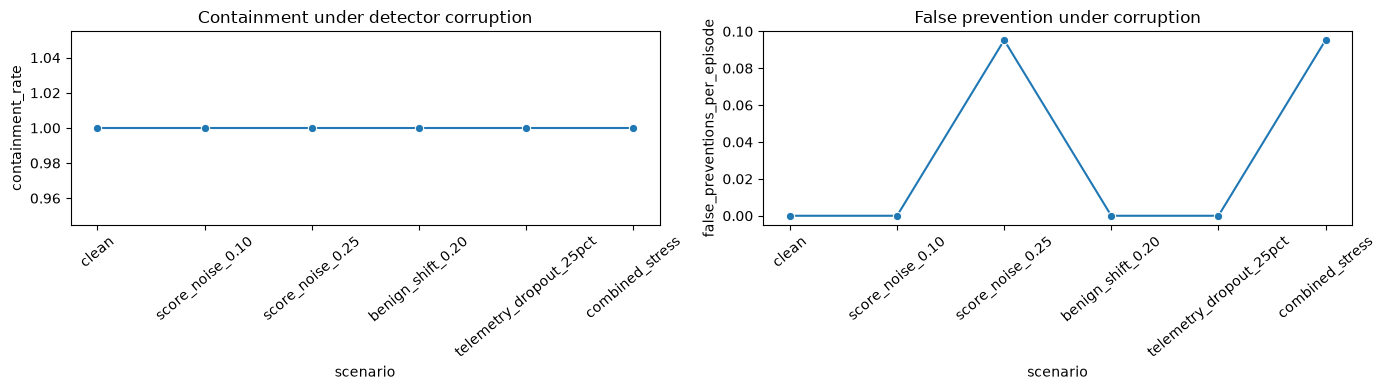

In [24]:
import torch
from ips.dqn import QNetwork
from ips.analysis.evidence import network_policy,evaluate_detailed,reward_sensitivity,adversarial_noise_sweep
selected_row=bench.loc[bench.overall_score.idxmax()]
selected_network=QNetwork(7,7,int(selected_row.hidden_dim))
selected_network.load_state_dict(torch.load(OUTPUT/'candidate_benchmark'/selected_row['name']/'best.pt',map_location='cpu')['model_state_dict']); selected_network.eval()
selected_policy=network_policy(selected_network,SEED)
family_metrics,action_metrics,detailed_summary=evaluate_detailed(selected_policy,splits.test,seed=SEED+2_000_000)
display(pd.Series(detailed_summary,name='selected DQN').to_frame()); display(family_metrics.round(4)); display(action_metrics.round(4))
fig,axes=plt.subplots(1,2,figsize=(14,4))
if not family_metrics.empty: sns.barplot(data=family_metrics,x='attack_family',y='containment_rate',ax=axes[0]); axes[0].tick_params(axis='x',rotation=35)
sns.barplot(data=action_metrics,x='action',y='fraction',ax=axes[1]); axes[1].tick_params(axis='x',rotation=35); axes[0].set_title('Containment by attack family'); axes[1].set_title('DQN action distribution'); plt.tight_layout(); plt.show()
target_families={'DoS','Probe','BruteForce','Exploitation','R2L','U2R'}; missing_families=sorted(target_families-set(family_metrics.attack_family if not family_metrics.empty else [])); print('Missing target families:',missing_families or 'none')
reward_grid=reward_sensitivity(selected_policy,splits.test,seed=SEED+2_000_000); display(reward_grid.round(4))
g=sns.relplot(data=reward_grid,x='value',y='mean_return',col='parameter',col_wrap=2,kind='line',marker='o',facet_kws={'sharex':False,'sharey':False},height=3); g.fig.suptitle('Frozen-policy reward sensitivity',y=1.03); plt.show()
return_ranges=reward_grid.groupby('parameter').mean_return.agg(lambda s:s.max()-s.min()).sort_values(ascending=False)
dqn_robustness=adversarial_noise_sweep(selected_policy,splits.test,seed=SEED); display(dqn_robustness.round(4))
fig,axes=plt.subplots(1,2,figsize=(14,4)); sns.lineplot(data=dqn_robustness,x='scenario',y='containment_rate',marker='o',ax=axes[0]); sns.lineplot(data=dqn_robustness,x='scenario',y='false_preventions_per_episode',marker='o',ax=axes[1]); [ax.tick_params(axis='x',rotation=40) for ax in axes]; axes[0].set_title('Containment under detector corruption'); axes[1].set_title('False prevention under corruption'); plt.tight_layout(); plt.show()

## 22 — Complete 3×3 grid and five-seed finalists

Candidate discovery is validation-only. The full width × batch grid covers all nine interactions. The two strongest validation candidates are then retrained across five seeds; each selected checkpoint evaluates final test once.

Factorial coverage: 9 configurations; 9 / 9 interaction cells


,name,safety_quality_mean,safety_quality_std,containment_mean,compromise_mean,return_mean,return_std_between,safety_ci95_halfwidth
0,DQN-h16-b32,0.7570,0.5116,0.8842,0.1158,2.2062,8.1115,0.4485
1,DQN-h16-b64,0.7359,0.5027,0.8737,0.1263,1.7824,8.0023,0.4406


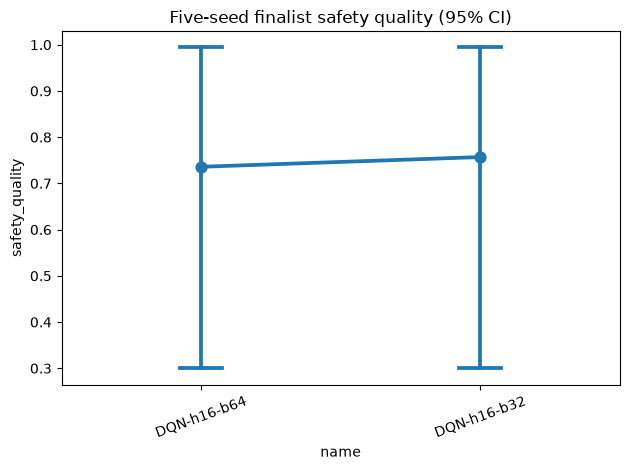

In [25]:
from ips.analysis.experiments import Candidate,benchmark_finalists_multi_seed
print('Factorial coverage:',len(bench),'configurations;',int(interaction.notna().sum().sum()),'/',interaction.size,'interaction cells')
finalist_rows=bench.sort_values(['safety_quality','runtime_s'],ascending=[False,True]).head(2)
finalists=tuple(Candidate(str(r['name']),int(r.hidden_dim),float(r.gamma),float(r.learning_rate),int(r.batch_size),int(r.target_update_steps),100 if RUN_HEAVY else 30) for _,r in finalist_rows.iterrows())
finalist_runs=benchmark_finalists_multi_seed(splits,finalists,seeds=(42,43,44,45,46),output_dir=OUTPUT/'finalists_five_seed')
finalist_summary=finalist_runs.groupby('name').agg(safety_quality_mean=('safety_quality','mean'),safety_quality_std=('safety_quality','std'),containment_mean=('containment_rate','mean'),compromise_mean=('compromise_rate','mean'),return_mean=('mean_return','mean'),return_std_between=('mean_return','std')).reset_index()
finalist_summary['safety_ci95_halfwidth']=1.96*finalist_summary.safety_quality_std/np.sqrt(5); display(finalist_summary.round(4))
sns.pointplot(data=finalist_runs,x='name',y='safety_quality',errorbar=('ci',95),capsize=.15); plt.title('Five-seed finalist safety quality (95% CI)'); plt.xticks(rotation=20); plt.tight_layout(); plt.show()

## 23 — Contextual bandit, masked PPO, and constrained PPO

The bandit tests whether delayed credit is necessary. PPO learns a stochastic masked policy without replay. Constrained PPO learns a multiplier when disruptive actions exceed its budget. All are trained and evaluated using the same episodes and action accounting.

,policy,episodes,attack_episodes,containment_rate,compromise_rate,false_preventions_per_episode,mean_return,return_std
0,DQN,21.0,19.0,1.0,0.0,0.0,7.0238,2.3015
1,LinUCB_bandit,21.0,19.0,1.0,0.0,0.0,7.0238,2.3015
2,Masked_PPO,21.0,19.0,1.0,0.0,0.0,6.8714,2.8317
3,Constrained_PPO,21.0,19.0,1.0,0.0,0.0,6.8714,2.8317


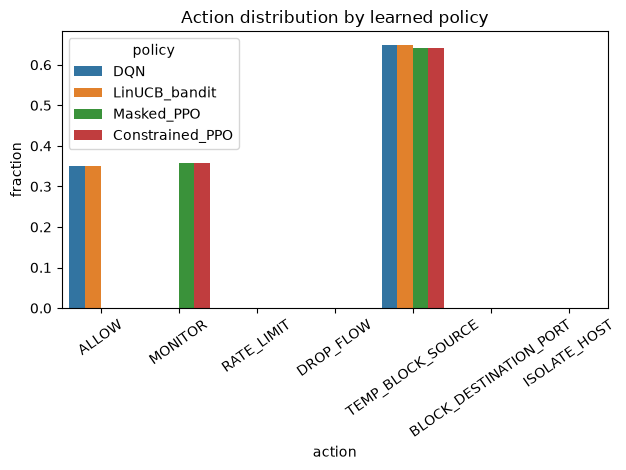

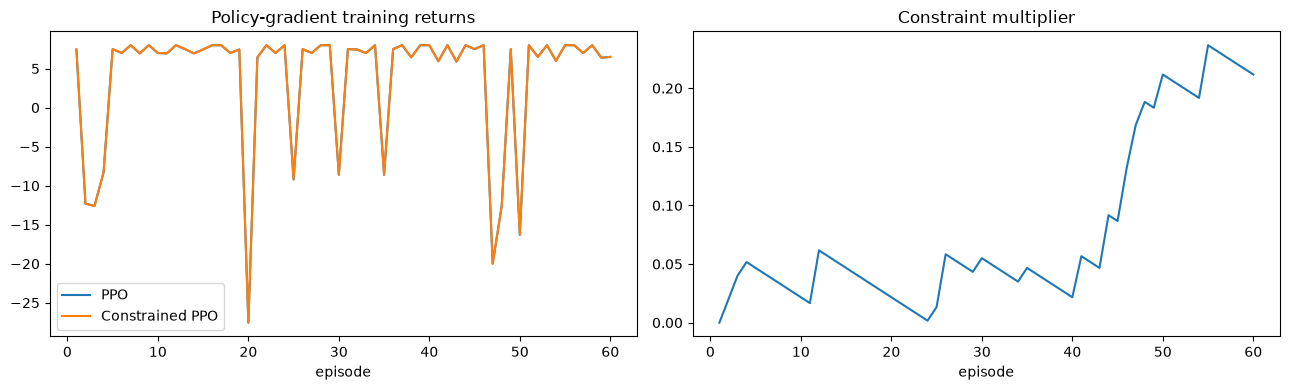

In [26]:
from ips.advanced_policies import train_bandit,train_ppo,PpoConfig,actor_policy
bandit=train_bandit(splits.train,training_episodes=300 if RUN_HEAVY else 60,seed=SEED); bandit_policy=lambda state,mask:bandit.choose(state,mask)
ppo_model,ppo_history=train_ppo(splits.train,config=PpoConfig(training_episodes=300 if RUN_HEAVY else 60),seed=SEED)
cppo_model,cppo_history=train_ppo(splits.train,config=PpoConfig(training_episodes=300 if RUN_HEAVY else 60,constrained=True,disruption_limit=.10),seed=SEED)
policies={'DQN':selected_policy,'LinUCB_bandit':bandit_policy,'Masked_PPO':actor_policy(ppo_model),'Constrained_PPO':actor_policy(cppo_model)}
policy_rows=[]; policy_actions=[]
for name,policy in policies.items():
    _,at,sm=evaluate_detailed(policy,splits.test,seed=SEED+2_000_000); policy_rows.append({'policy':name,**sm}); policy_actions.append(at.assign(policy=name))
policy_comparison=pd.DataFrame(policy_rows); all_policy_actions=pd.concat(policy_actions,ignore_index=True); display(policy_comparison.round(4))
sns.barplot(data=all_policy_actions,x='action',y='fraction',hue='policy'); plt.title('Action distribution by learned policy'); plt.xticks(rotation=35); plt.tight_layout(); plt.show()
fig,axes=plt.subplots(1,2,figsize=(13,4)); ppo_history.plot(x='episode',y='return',ax=axes[0],label='PPO'); cppo_history.plot(x='episode',y='return',ax=axes[0],label='Constrained PPO'); cppo_history.plot(x='episode',y='lagrange',ax=axes[1],title='Constraint multiplier',legend=False); axes[0].set_title('Policy-gradient training returns'); plt.tight_layout(); plt.show()

## 24 — Native resources and cross-policy adversarial robustness

Resource profiling adds decision-latency percentiles, throughput, process CPU, one-core utilization, and maximum RSS. The same policies are then tested under score noise, benign-score shifts, telemetry dropout, and combined stress.

,policy,decisions,latency_mean_ms,latency_p50_ms,latency_p95_ms,latency_p99_ms,throughput_decisions_s,process_cpu_s,cpu_utilization_one_core_pct,max_rss_mb,rss_scope
0,DQN,210.0,0.0254,0.0226,0.0279,0.0330,39016.2336,0.0055,101.7952,585.875,shared_process_peak_not_policy_attributable
1,LinUCB_bandit,210.0,0.0258,0.0240,0.0325,0.0645,38496.4955,0.0054,99.1376,585.875,shared_process_peak_not_policy_attributable
2,Masked_PPO,210.0,0.0137,0.0128,0.0161,0.0193,72081.3490,0.0029,100.0215,585.875,shared_process_peak_not_policy_attributable
3,Constrained_PPO,210.0,0.0138,0.0135,0.0152,0.0203,71468.0733,0.0029,99.9192,585.875,shared_process_peak_not_policy_attributable


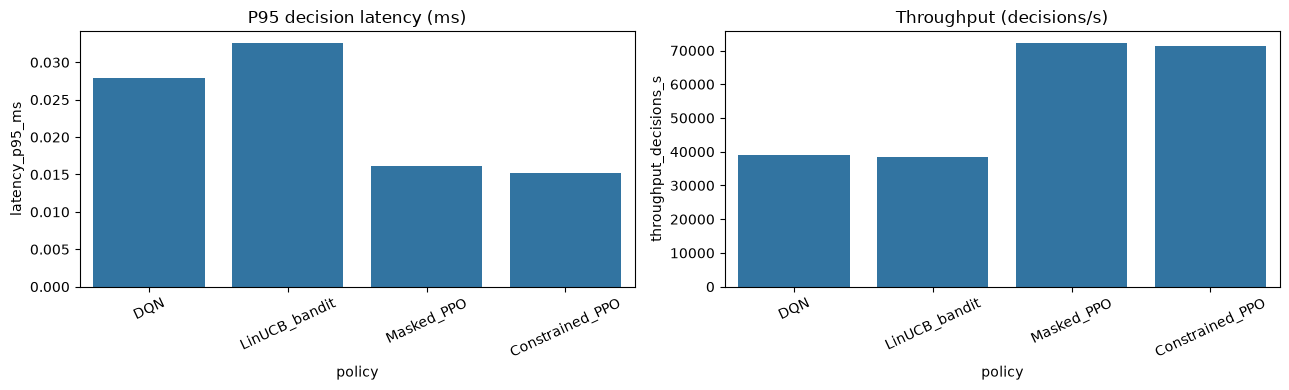

,scenario,score_noise,false_positive_shift,telemetry_dropout,episodes,attack_episodes,containment_rate,compromise_rate,false_preventions_per_episode,mean_return,return_std,policy
0,clean,0.00,0.0,0.00,21.0,19.0,1.0000,0.0000,0.0000,7.0952,2.3177,DQN
1,score_noise_0.10,0.10,0.0,0.00,21.0,19.0,1.0000,0.0000,0.0000,7.0000,2.2939,DQN
2,score_noise_0.25,0.25,0.0,0.00,21.0,19.0,1.0000,0.0000,0.0952,6.4048,3.4317,DQN
3,benign_shift_0.20,0.00,0.2,0.00,21.0,19.0,1.0000,0.0000,0.0000,7.0952,2.3177,DQN
4,telemetry_dropout_25pct,0.00,0.0,0.25,21.0,19.0,1.0000,0.0000,0.0000,6.8333,2.2800,DQN
5,combined_stress,0.15,0.2,0.25,21.0,19.0,1.0000,0.0000,0.0952,6.3810,3.4048,DQN
6,clean,0.00,0.0,0.00,21.0,19.0,1.0000,0.0000,0.0000,7.0952,2.3177,LinUCB_bandit
7,score_noise_0.10,0.10,0.0,0.00,21.0,19.0,1.0000,0.0000,0.0000,6.9952,2.2934,LinUCB_bandit
8,score_noise_0.25,0.25,0.0,0.00,21.0,19.0,0.9474,0.0526,0.0952,4.8310,7.9999,LinUCB_bandit
9,benign_shift_0.20,0.00,0.2,0.00,21.0,19.0,1.0000,0.0000,0.0000,7.0952,2.3177,LinUCB_bandit


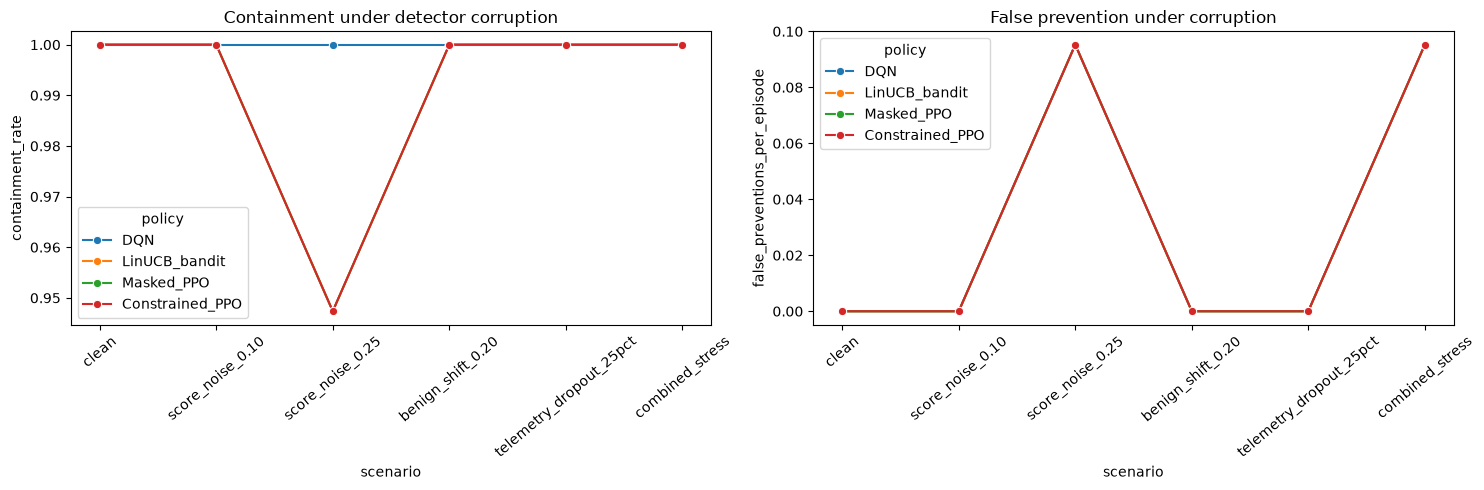

,containment_degradation
policy,
DQN,0.0
LinUCB_bandit,0.0
Masked_PPO,0.0
Constrained_PPO,0.0


In [27]:
from ips.analysis.evidence import profile_policy
from ips.dataset_environment import DatasetBackedIpsEnv
profile_states=[];profile_masks=[]
for ep in splits.test:
    envp=DatasetBackedIpsEnv(ep,seed=SEED);ob,inf=envp.reset(seed=SEED);profile_states.append(ob.as_array());profile_masks.append(inf['action_mask'])
resource_rows=[{'policy':name,**profile_policy(policy,np.stack(profile_states),np.stack(profile_masks),repeats=50 if RUN_HEAVY else 10)} for name,policy in policies.items()]
resource_profile=pd.DataFrame(resource_rows);display(resource_profile.round(4))
fig,axes=plt.subplots(1,2,figsize=(13,4));sns.barplot(data=resource_profile,x='policy',y='latency_p95_ms',ax=axes[0]);sns.barplot(data=resource_profile,x='policy',y='throughput_decisions_s',ax=axes[1]);[ax.tick_params(axis='x',rotation=25) for ax in axes];axes[0].set_title('P95 decision latency (ms)');axes[1].set_title('Throughput (decisions/s)');plt.tight_layout();plt.show()
robustness=pd.concat([adversarial_noise_sweep(policy,splits.test,seed=SEED).assign(policy=name) for name,policy in policies.items()],ignore_index=True);display(robustness.round(4))
fig,axes=plt.subplots(1,2,figsize=(15,5));sns.lineplot(data=robustness,x='scenario',y='containment_rate',hue='policy',marker='o',ax=axes[0]);sns.lineplot(data=robustness,x='scenario',y='false_preventions_per_episode',hue='policy',marker='o',ax=axes[1]);[ax.tick_params(axis='x',rotation=40) for ax in axes];axes[0].set_title('Containment under detector corruption');axes[1].set_title('False prevention under corruption');plt.tight_layout();plt.show()
clean=robustness[robustness.scenario=='clean'].set_index('policy');stress=robustness[robustness.scenario=='combined_stress'].set_index('policy');degradation=(clean.containment_rate-stress.containment_rate).sort_values();display(degradation.to_frame('containment_degradation'))

## 25 — Enhanced evidence dashboard and final recommendations

The final dashboard joins data provenance, family coverage, action behavior, reward sensitivity, five-seed finalists, policy-family comparisons, native resources, and adversarial robustness. It updates automatically whenever real events or configurations change.

In [28]:
enhanced_dashboard=pd.Series({'evidence_kind':evidence_kind,'real_adapter_status':adapter_status['status'],'factorial_configs':len(bench),'interaction_coverage':f'{int(interaction.notna().sum().sum())}/{interaction.size}','five_seed_finalists':', '.join(finalist_summary.name),'five_seed_best':finalist_summary.loc[finalist_summary.safety_quality_mean.idxmax(),'name'],'best_policy_return':policy_comparison.loc[policy_comparison.mean_return.idxmax(),'policy'],'tested_families':', '.join(family_metrics.attack_family) if not family_metrics.empty else 'none','missing_target_families':', '.join(missing_families) if missing_families else 'none','most_common_dqn_action':action_metrics.loc[action_metrics['count'].idxmax(),'action'],'most_reward_sensitive_term':return_ranges.index[0],'lowest_p95_latency_policy':resource_profile.loc[resource_profile.latency_p95_ms.idxmin(),'policy'],'most_robust_policy':degradation.index[0],'test_episodes':len(splits.test),'test_attack_episodes':sum(ep.contains_attack for ep in splits.test)},name='Enhanced current evidence')
display(enhanced_dashboard.to_frame());enhanced_dashboard.to_json(OUTPUT/'enhanced_experiment_dashboard.json',indent=2)
print('Final recommendation: treat all policy rankings as simulator evidence until the real adapter status is generated and each target attack family has sufficient held-out episodes.')

,Enhanced current evidence
evidence_kind,SYNTHETIC CONTRACT FIXTURE — NOT DATASET EVIDENCE
real_adapter_status,blocked_missing_source_config
factorial_configs,9
interaction_coverage,9/9
five_seed_finalists,"DQN-h16-b32, DQN-h16-b64"
five_seed_best,DQN-h16-b32
best_policy_return,DQN
tested_families,"BruteForce, DoS, Exploitation, Probe, R2L, U2R"
missing_target_families,none
most_common_dqn_action,TEMP_BLOCK_SOURCE


Final recommendation: treat all policy rankings as simulator evidence until the real adapter status is generated and each target attack family has sufficient held-out episodes.


## 26 — Real NSL-KDD evidence: calibration, uncertainty, and drift

This section uses the verified official NSL-KDD train/test files, not the synthetic fixture. Training detector probabilities are out-of-fold and official-test probabilities come from a train-only model. NSL-KDD has no trustworthy timestamps, hosts, campaigns, or observed prevention outcomes, so fixed-size family-pure sequences are explicitly **ordered-row proxies** and IPS outcomes remain counterfactual. Calibration is fitted on validation episodes only.

,real-data evidence contract
dataset,NSL-KDD
evidence_kind,real labelled flows; counterfactual IPS outcomes
train_rows,12000
official_test_rows,5000
sequence_semantics,ordered-row proxy; NSL-KDD has no timestamps
detector_train_scoring,out-of-fold
detector_test_scoring,fit on train only
group_semantics,family-pure fixed-size chunks; not hosts or ca...


,wall_time_s,cpu_time_s,cpu_utilization_one_core_pct,max_rss_mb,train_rows_per_s
0,2.2108,2.2084,99.8916,884.4062,5427.8567


,method,brier_score,ece_10_bins,mean_probability
0,raw,0.21224,0.22267,0.39292
2,isotonic,0.21294,0.22517,0.39220
1,platt,0.21800,0.21284,0.39547


,comparison,score_PSI,interpretation
0,OOF train → official test,0.18184,moderate drift


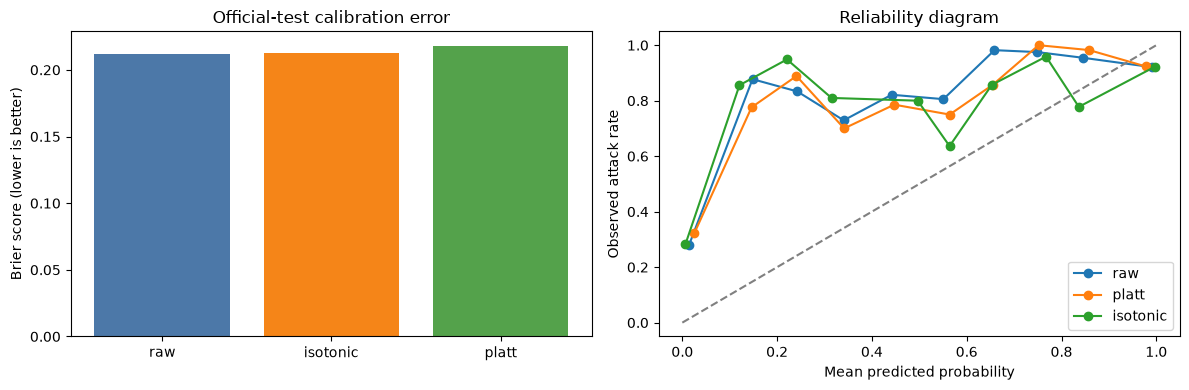

In [29]:
from sklearn.metrics import brier_score_loss
from data import load_nsl_kdd
from ips.adapters.nsl_kdd import NslIpsConfig, build_nsl_ips_evidence
from ips.analysis.real_policy import expected_calibration_error, fit_probability_calibrator, population_stability_index, escalation_decision
nsl_config = NslIpsConfig(max_train_rows=None if RUN_HEAVY else 12_000, max_test_rows=None if RUN_HEAVY else 5_000, episode_size=12, folds=5 if RUN_HEAVY else 3, seed=SEED)
nsl_evidence = build_nsl_ips_evidence(load_nsl_kdd('train'), load_nsl_kdd('test'), nsl_config)
def episode_arrays(episodes):
    events=[event for episode in episodes for event in episode.events]
    return np.array([event.threat_probability for event in events]), np.array([event.attack_present for event in events],dtype=int)
validation_scores, validation_labels = episode_arrays(nsl_evidence.splits.validation)
test_scores, test_labels = episode_arrays(nsl_evidence.splits.test)
train_scores, _ = episode_arrays(nsl_evidence.splits.train)
platt = fit_probability_calibrator(validation_scores, validation_labels, method='platt')
isotonic = fit_probability_calibrator(validation_scores, validation_labels, method='isotonic')
calibration_rows=[]
for method, scores in {'raw':test_scores, 'platt':platt(test_scores), 'isotonic':isotonic(test_scores)}.items():
    calibration_rows.append({'method':method, 'brier_score':brier_score_loss(test_labels,scores), 'ece_10_bins':expected_calibration_error(test_labels,scores,10), 'mean_probability':scores.mean()})
calibration_comparison=pd.DataFrame(calibration_rows).sort_values('brier_score')
drift_summary=pd.DataFrame([{'comparison':'OOF train → official test','score_PSI':population_stability_index(train_scores,test_scores),'interpretation':'material drift' if population_stability_index(train_scores,test_scores)>=0.25 else 'moderate drift' if population_stability_index(train_scores,test_scores)>=0.10 else 'low drift'}])
display(pd.Series(nsl_evidence.metadata,name='real-data evidence contract').to_frame())
display(pd.DataFrame([nsl_evidence.resources]).round(4)); display(calibration_comparison.round(5)); display(drift_summary.round(5))
fig,axes=plt.subplots(1,2,figsize=(12,4))
axes[0].bar(calibration_comparison.method,calibration_comparison.brier_score,color=['#4c78a8','#f58518','#54a24b']); axes[0].set(title='Official-test calibration error',ylabel='Brier score (lower is better)')
for method,scores in {'raw':test_scores,'platt':platt(test_scores),'isotonic':isotonic(test_scores)}.items():
    bins=pd.cut(scores,np.linspace(0,1,11),include_lowest=True); reliability=pd.DataFrame({'score':scores,'label':test_labels}).groupby(bins,observed=True).mean(); axes[1].plot(reliability.score,reliability.label,marker='o',label=method)
axes[1].plot([0,1],[0,1],'--',color='gray'); axes[1].set(title='Reliability diagram',xlabel='Mean predicted probability',ylabel='Observed attack rate'); axes[1].legend(); plt.tight_layout(); plt.show()

## 27 — Real-flow policy experiment: sequential consequences, escalation, and unseen families

DQN, LinUCB, masked PPO, and constrained PPO now train on real NSL-KDD detector observations. The environment retains sequential attack progression and action-dependent termination, while every outcome is labelled counterfactual. A virtual `ESCALATE` shadow decision measures analyst workload without bypassing the seven-action safety layer. Leave-one-family-out DQN runs test whether policy behavior transfers to attack families excluded during training.

In [30]:
import resource, time, torch
from ips.dataset import EpisodeSplits
from ips.dataset_experiment import DatasetTrainConfig, train_one_seed
from ips.dqn import DqnConfig, QNetwork
from ips.advanced_policies import train_bandit, train_ppo, actor_policy, PpoConfig
from ips.analysis.evidence import network_policy, evaluate_detailed
real_training_resources=[]
dqn_cfg=DqnConfig(hidden_dim=64,batch_size=32,replay_capacity=5000,warmup_steps=64,target_update_steps=100,epsilon_decay_steps=1500)
started=time.perf_counter(); cpu=time.process_time(); real_dqn_run=train_one_seed(nsl_evidence.splits,seed=SEED,dqn=dqn_cfg,training=DatasetTrainConfig(episodes=400 if RUN_HEAVY else 120,validation_interval=50 if RUN_HEAVY else 30),output_dir=OUTPUT/'real_nsl_dqn'); real_training_resources.append({'policy':'DQN','training_wall_s':time.perf_counter()-started,'training_cpu_s':time.process_time()-cpu})
real_dqn=QNetwork(7,7,64); real_dqn.load_state_dict(torch.load(real_dqn_run['checkpoint'],map_location='cpu')['model_state_dict'])
started=time.perf_counter(); cpu=time.process_time(); real_bandit=train_bandit(nsl_evidence.splits.train,training_episodes=400 if RUN_HEAVY else 120,seed=SEED); real_training_resources.append({'policy':'LinUCB','training_wall_s':time.perf_counter()-started,'training_cpu_s':time.process_time()-cpu})
started=time.perf_counter(); cpu=time.process_time(); real_ppo,real_ppo_history=train_ppo(nsl_evidence.splits.train,config=PpoConfig(training_episodes=250 if RUN_HEAVY else 70,hidden_dim=64),seed=SEED); real_training_resources.append({'policy':'Masked PPO','training_wall_s':time.perf_counter()-started,'training_cpu_s':time.process_time()-cpu})
started=time.perf_counter(); cpu=time.process_time(); real_cppo,real_cppo_history=train_ppo(nsl_evidence.splits.train,config=PpoConfig(training_episodes=250 if RUN_HEAVY else 70,hidden_dim=64,constrained=True,disruption_limit=0.10),seed=SEED); real_training_resources.append({'policy':'Constrained PPO','training_wall_s':time.perf_counter()-started,'training_cpu_s':time.process_time()-cpu})
real_policies={'DQN':network_policy(real_dqn,SEED),'LinUCB':real_bandit.choose,'Masked PPO':actor_policy(real_ppo),'Constrained PPO':actor_policy(real_cppo)}
real_policy_rows=[]; real_family_rows=[]; real_action_rows=[]
for policy_name,policy in real_policies.items():
    family,actions,summary=evaluate_detailed(policy,nsl_evidence.splits.test,seed=SEED); real_policy_rows.append({'policy':policy_name,**summary}); real_family_rows.append(family.assign(policy=policy_name)); real_action_rows.append(actions.assign(policy=policy_name))
real_policy_comparison=pd.DataFrame(real_policy_rows); real_family_comparison=pd.concat(real_family_rows,ignore_index=True); real_action_comparison=pd.concat(real_action_rows,ignore_index=True)
review=np.array([escalation_decision(score) for score in test_scores]); escalation_summary=pd.DataFrame([{'automation_rate':1-review.mean(),'human_review_rate':review.mean(),'attack_review_rate':review[test_labels==1].mean(),'benign_review_rate':review[test_labels==0].mean(),'reviewed_events':int(review.sum())}])
holdout_rows=[]
for family_name in ('DoS','Probe','R2L','U2R'):
    train_eps=tuple(ep for ep in nsl_evidence.splits.train if not any(ev.attack_family==family_name for ev in ep.events)); val_eps=tuple(ep for ep in nsl_evidence.splits.validation if not any(ev.attack_family==family_name for ev in ep.events)); test_eps=tuple(ep for ep in nsl_evidence.splits.test if any(ev.attack_family==family_name for ev in ep.events))
    if not min(len(train_eps),len(val_eps),len(test_eps)): continue
    started=time.perf_counter(); run=train_one_seed(EpisodeSplits(train_eps,val_eps,test_eps),seed=SEED,dqn=dqn_cfg,training=DatasetTrainConfig(episodes=100 if RUN_HEAVY else 35,validation_interval=25 if RUN_HEAVY else 15),output_dir=OUTPUT/'real_family_holdout'/family_name); holdout_rows.append({'excluded_family':family_name,'training_wall_s':time.perf_counter()-started,**run['final_test']})
unseen_family_results=pd.DataFrame(holdout_rows)
display(real_policy_comparison.round(4)); display(real_family_comparison.round(4)); display(real_action_comparison.pivot(index='policy',columns='action',values='fraction').fillna(0).round(4)); display(escalation_summary.round(4)); display(unseen_family_results.round(4))

,policy,episodes,attack_episodes,containment_rate,compromise_rate,false_preventions_per_episode,mean_return,return_std
0,DQN,419.0,239.0,0.7657,0.2343,0.3294,-1.7053,11.6498
1,LinUCB,419.0,239.0,0.7155,0.2845,0.3031,-2.5471,12.1906
2,Masked PPO,419.0,239.0,0.7657,0.2343,0.3198,-3.0928,11.8631
3,Constrained PPO,419.0,239.0,0.7950,0.2050,0.3198,-2.5487,11.4321


,attack_family,episodes,contained,compromised,containment_rate,compromise_rate,policy
0,DoS,138,134,4,0.9710,0.0290,DQN
1,Probe,45,45,0,1.0000,0.0000,DQN
2,R2L,54,3,51,0.0556,0.9444,DQN
3,U2R,2,1,1,0.5000,0.5000,DQN
4,DoS,138,128,10,0.9275,0.0725,LinUCB
5,Probe,45,40,5,0.8889,0.1111,LinUCB
6,R2L,54,2,52,0.0370,0.9630,LinUCB
7,U2R,2,1,1,0.5000,0.5000,LinUCB
8,DoS,138,134,4,0.9710,0.0290,Masked PPO
9,Probe,45,45,0,1.0000,0.0000,Masked PPO


action,ALLOW,BLOCK_DESTINATION_PORT,DROP_FLOW,ISOLATE_HOST,MONITOR,RATE_LIMIT,TEMP_BLOCK_SOURCE
policy,,,,,,,
Constrained PPO,0.0814,0.0000,0.0,0.1149,0.8037,0.0000,0.0000
DQN,0.8778,0.0015,0.0,0.0713,0.0000,0.0000,0.0495
LinUCB,0.8454,0.0000,0.0,0.0000,0.0124,0.0226,0.1197
Masked PPO,0.1416,0.0000,0.0,0.1135,0.7450,0.0000,0.0000


,automation_rate,human_review_rate,attack_review_rate,benign_review_rate,reviewed_events
0,0.9664,0.0336,0.0499,0.0121,168


,excluded_family,training_wall_s,episodes,attack_episodes,containment_rate,compromise_rate,false_preventions_per_episode,disruptive_actions_per_episode,mean_return,return_std
0,DoS,0.3546,138,138,0.9203,0.0797,0.0,1.1377,4.7246,9.1681
1,Probe,0.3204,45,45,1.0000,0.0000,0.0,1.1556,7.8000,0.3859
2,R2L,0.3512,54,54,0.0185,0.9815,0.0,0.0556,-27.2778,5.1051
3,U2R,0.3135,2,2,0.5000,0.5000,0.0,0.5000,-9.0000,17.0000


## 28 — Professional real-data comparison, constraints, and resource consumption

This final dashboard combines security outcomes, action aggressiveness, analyst workload, hard operational constraints, training cost, process RSS, model size, throughput, and p50/p95/p99 inference latency. It separates detector evidence (real labels and official split) from prevention evidence (still counterfactual), and makes the LinUCB-versus-RL question explicit.

,policy,episodes,attack_episodes,containment_rate,compromise_rate,false_preventions_per_episode,mean_return,return_std,aggressiveness_score,latency_p95_ms,throughput_decisions_s,model_mb,max_rss_mb,false_prevention_constraint,latency_constraint,constraints_passed,evidence_grade
0,DQN,419.0,239.0,0.7657,0.2343,0.3294,-1.7053,11.6498,0.1055,0.0285,37889.2926,0.0196,885.6094,False,True,False,REAL DETECTOR / COUNTERFACTUAL IPS
1,LinUCB,419.0,239.0,0.7155,0.2845,0.3031,-2.5471,12.1906,0.0894,0.0321,36866.5103,0.0030,885.6094,False,True,False,REAL DETECTOR / COUNTERFACTUAL IPS
2,Masked PPO,419.0,239.0,0.7657,0.2343,0.3198,-3.0928,11.8631,0.2376,0.0138,76050.3658,0.0039,885.6094,False,True,False,REAL DETECTOR / COUNTERFACTUAL IPS
3,Constrained PPO,419.0,239.0,0.7950,0.2050,0.3198,-2.5487,11.4321,0.2489,0.0140,76002.1992,0.0039,885.6094,False,True,False,REAL DETECTOR / COUNTERFACTUAL IPS


,policy,parameters,model_mb,training_wall_s,training_cpu_s,decisions,latency_mean_ms,latency_p50_ms,latency_p95_ms,latency_p99_ms,throughput_decisions_s,process_cpu_s,cpu_utilization_one_core_pct,max_rss_mb,rss_scope
0,DQN,5127,0.0196,0.7683,0.7726,3000.0,0.0262,0.0251,0.0285,0.0314,37889.2926,0.0792,100.0416,885.6094,shared_process_peak_not_policy_attributable
1,LinUCB,392,0.0030,0.0470,0.0470,3000.0,0.0270,0.0294,0.0321,0.0365,36866.5103,0.0813,99.9254,885.6094,shared_process_peak_not_policy_attributable
2,Masked PPO,1032,0.0039,0.1243,0.1278,3000.0,0.0130,0.0127,0.0138,0.0166,76050.3658,0.0394,99.9226,885.6094,shared_process_peak_not_policy_attributable
3,Constrained PPO,1032,0.0039,0.1251,0.1286,3000.0,0.0130,0.0127,0.0140,0.0190,76002.1992,0.0394,99.9201,885.6094,shared_process_peak_not_policy_attributable


,method,brier_score,ece_10_bins,mean_probability
0,raw,0.21224,0.22267,0.39292
2,isotonic,0.21294,0.22517,0.39220
1,platt,0.21800,0.21284,0.39547


,comparison,score_PSI,interpretation
0,OOF train → official test,0.18184,moderate drift


,excluded_family,training_wall_s,episodes,attack_episodes,containment_rate,compromise_rate,false_preventions_per_episode,disruptive_actions_per_episode,mean_return,return_std
0,DoS,0.3546,138,138,0.9203,0.0797,0.0,1.1377,4.7246,9.1681
1,Probe,0.3204,45,45,1.0000,0.0000,0.0,1.1556,7.8000,0.3859
2,R2L,0.3512,54,54,0.0185,0.9815,0.0,0.0556,-27.2778,5.1051
3,U2R,0.3135,2,2,0.5000,0.5000,0.0,0.5000,-9.0000,17.0000


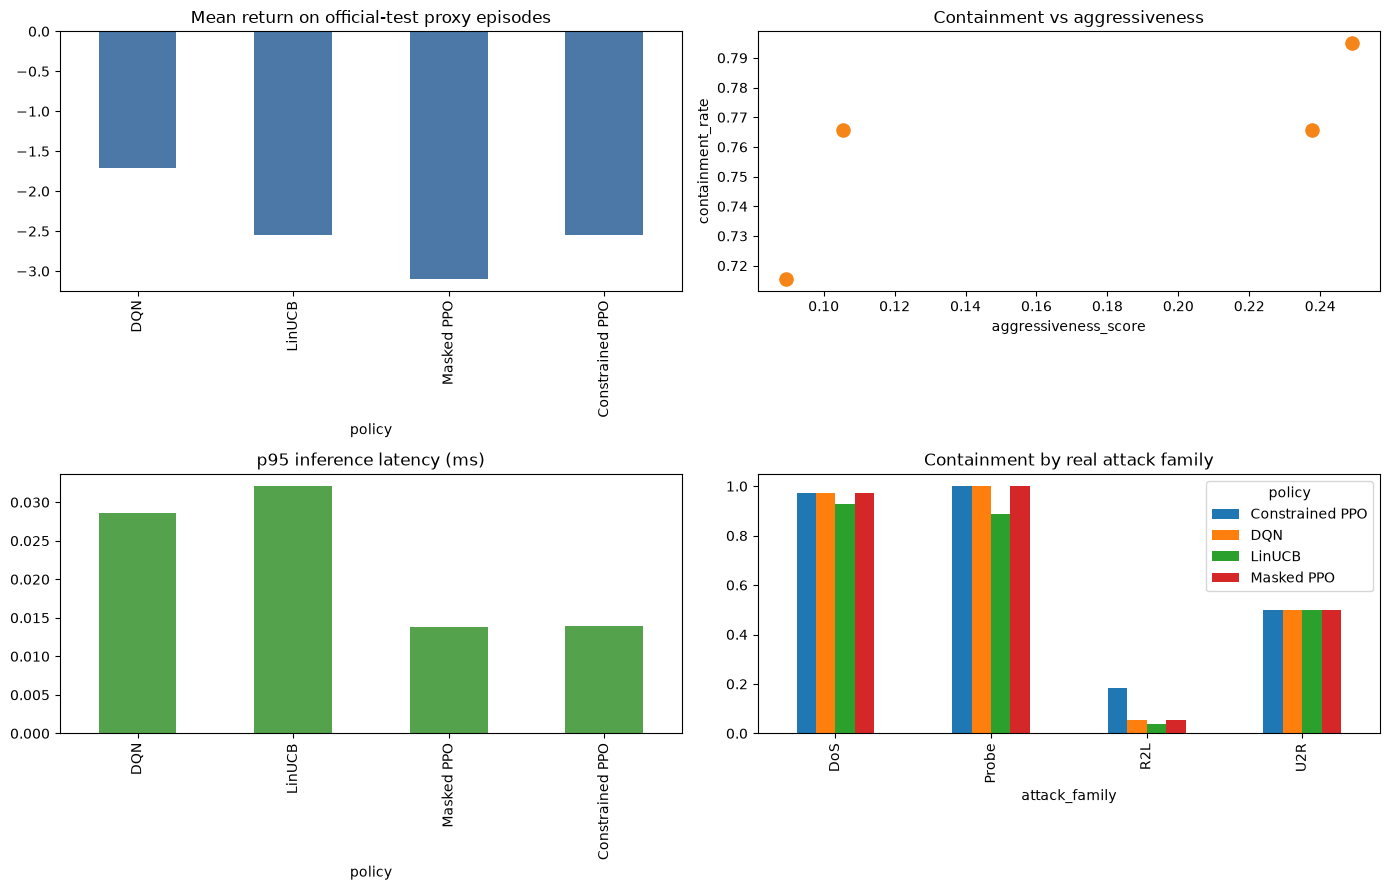

,professional evidence conclusion
dataset,NSL-KDD official split
sequence_evidence,proxy—not timestamped
detector_scoring,OOF train; train-only official test
best_calibration,raw
score_PSI,0.181841
best_return_policy,DQN
least_aggressive_policy,LinUCB
fastest_policy,Masked PPO
all_constraints_passed,False
human_review_rate,0.0336


In [31]:
from ips.analysis.evidence import profile_policy
from ips.dataset_environment import DatasetBackedIpsEnv
sample_states=[]; sample_masks=[]
for index,episode in enumerate(nsl_evidence.splits.test[:100]):
    observation,info=DatasetBackedIpsEnv(episode,seed=SEED+index).reset(seed=SEED+index); sample_states.append(observation.as_array()); sample_masks.append(np.asarray(info['action_mask']))
resource_rows=[]
training_by_policy=pd.DataFrame(real_training_resources).set_index('policy')
for name,policy in real_policies.items():
    profile=profile_policy(policy,np.asarray(sample_states),np.asarray(sample_masks),repeats=30)
    if name=='DQN': parameters=sum(p.numel() for p in real_dqn.parameters()); model_mb=sum(p.numel()*p.element_size() for p in real_dqn.parameters())/1024**2
    elif name=='LinUCB': parameters=real_bandit.A.size+real_bandit.b.size; model_mb=(real_bandit.A.nbytes+real_bandit.b.nbytes)/1024**2
    else:
        model=real_ppo if name=='Masked PPO' else real_cppo; parameters=sum(p.numel() for p in model.parameters()); model_mb=sum(p.numel()*p.element_size() for p in model.parameters())/1024**2
    resource_rows.append({'policy':name,'parameters':parameters,'model_mb':model_mb,**training_by_policy.loc[name].to_dict(),**profile})
real_resource_comparison=pd.DataFrame(resource_rows)
severity={'ALLOW':0,'MONITOR':1,'RATE_LIMIT':2,'DROP_FLOW':3,'TEMP_BLOCK_SOURCE':4,'BLOCK_DESTINATION_PORT':5,'ISOLATE_HOST':6}
aggressiveness=(real_action_comparison.assign(weight=lambda x:x.action.map(severity),weighted=lambda x:x.fraction*x.weight).groupby('policy').weighted.sum()/6).rename('aggressiveness_score').reset_index()
operational=real_policy_comparison.merge(aggressiveness,on='policy').merge(real_resource_comparison[['policy','latency_p95_ms','throughput_decisions_s','model_mb','max_rss_mb']],on='policy')
operational['false_prevention_constraint']=operational.false_preventions_per_episode<0.01
operational['latency_constraint']=operational.latency_p95_ms<20.0
operational['constraints_passed']=operational[['false_prevention_constraint','latency_constraint']].all(axis=1)
operational['evidence_grade']='REAL DETECTOR / COUNTERFACTUAL IPS'
display(operational.round(4)); display(real_resource_comparison.round(4)); display(calibration_comparison.round(5)); display(drift_summary.round(5)); display(unseen_family_results.round(4))
real_output=OUTPUT/'real_nsl_evidence'; real_output.mkdir(parents=True,exist_ok=True)
operational.to_csv(real_output/'policy_operational_comparison.csv',index=False); real_resource_comparison.to_csv(real_output/'resource_consumption.csv',index=False)
real_family_comparison.to_csv(real_output/'attack_family_metrics.csv',index=False); real_action_comparison.to_csv(real_output/'action_distribution.csv',index=False)
calibration_comparison.to_csv(real_output/'calibration_comparison.csv',index=False); drift_summary.to_csv(real_output/'drift_summary.csv',index=False); unseen_family_results.to_csv(real_output/'unseen_family_results.csv',index=False)
fig,axes=plt.subplots(2,2,figsize=(14,9))
operational.plot.bar(x='policy',y='mean_return',ax=axes[0,0],legend=False,title='Mean return on official-test proxy episodes',color='#4c78a8')
operational.plot.scatter(x='aggressiveness_score',y='containment_rate',s=90,ax=axes[0,1],title='Containment vs aggressiveness',color='#f58518')
real_resource_comparison.plot.bar(x='policy',y='latency_p95_ms',ax=axes[1,0],legend=False,title='p95 inference latency (ms)',color='#54a24b')
real_family_comparison.pivot(index='attack_family',columns='policy',values='containment_rate').plot.bar(ax=axes[1,1],title='Containment by real attack family')
plt.tight_layout(); plt.show()
real_dashboard={'dataset':'NSL-KDD official split','sequence_evidence':'proxy—not timestamped','detector_scoring':'OOF train; train-only official test','best_calibration':calibration_comparison.iloc[0].method,'score_PSI':float(drift_summary.iloc[0].score_PSI),'best_return_policy':operational.sort_values('mean_return',ascending=False).iloc[0].policy,'least_aggressive_policy':operational.sort_values('aggressiveness_score').iloc[0].policy,'fastest_policy':real_resource_comparison.sort_values('latency_p95_ms').iloc[0].policy,'all_constraints_passed':bool(operational.constraints_passed.all()),'human_review_rate':float(escalation_summary.iloc[0].human_review_rate),'next_realism_gate':'timestamped CICIoT/CSE/TON traffic plus observed cyber-range interventions'}
(OUTPUT/'real_nsl_professional_dashboard.json').write_text(json.dumps(real_dashboard,indent=2)+'\n')
display(pd.Series(real_dashboard,name='professional evidence conclusion').to_frame())

## 29 — Five-seed reliability across every policy family

A single training seed cannot support a DQN-versus-bandit-versus-PPO claim. This section retrains all four policies with five independent seeds under the same real NSL-KDD proxy split, reports dispersion and confidence intervals, and uses bootstrap intervals to declare a winner, practical tie, or inconclusive comparison.

,policy,seed_count,return_mean,return_median,return_std,return_min,return_max,return_cv,return_ci95_halfwidth,containment_mean,stability
1,DQN,5,-1.7943,-1.8556,0.1855,-2.0274,-1.5979,0.1034,0.1626,0.7615,moderate
2,LinUCB,5,-1.8632,-1.8741,0.3510,-2.3587,-1.4332,0.1884,0.3076,0.7448,moderate
3,Masked PPO,5,-3.4725,-2.0539,4.6510,-11.5746,0.3785,1.3394,4.0768,0.7397,low
0,Constrained PPO,5,-3.8811,-2.0539,4.3048,-11.5746,-1.6675,1.1092,3.7734,0.7071,low


,policy_a,policy_b,mean_difference,ci95_low,ci95_high,decision
0,Constrained PPO,DQN,-2.0733,-5.9695,-0.0072,DQN wins
1,Constrained PPO,LinUCB,-2.0051,-5.9184,0.1418,inconclusive
2,Constrained PPO,Masked PPO,-0.4132,-5.5325,4.0109,inconclusive
3,DQN,LinUCB,0.0670,-0.2457,0.3842,practical tie
4,DQN,Masked PPO,1.7214,-1.1668,5.9695,inconclusive
5,LinUCB,Masked PPO,1.5760,-1.1835,5.8554,inconclusive


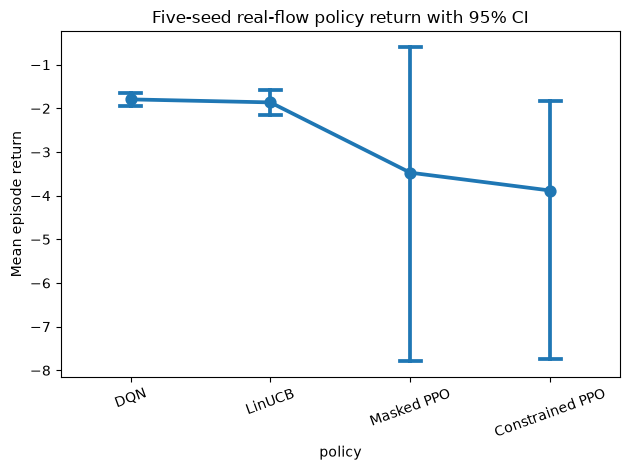

Result: DQN has the highest five-seed mean return.
Interpretation: 5 pairwise comparisons remain tied or inconclusive; these are not declared winners.
Expected/unusual: high seed variation is expected from stochastic policy training.
Implication: model selection must combine uncertainty, constraints, and resource cost—not a single mean.
Recommended action: increase seeds for every inconclusive pair before deployment claims.


In [32]:
from ips.analysis.diagnostics import repeated_run_summary, pairwise_bootstrap_decisions
policy_seed_rows=[]
for policy_seed in (42,43,44,45,46):
    started=time.perf_counter(); run=train_one_seed(nsl_evidence.splits,seed=policy_seed,dqn=dqn_cfg,training=DatasetTrainConfig(episodes=180 if RUN_HEAVY else 70,validation_interval=45 if RUN_HEAVY else 25),output_dir=OUTPUT/'real_policy_seeds'/'DQN'/f'seed_{policy_seed}'); model=QNetwork(7,7,64); model.load_state_dict(torch.load(run['checkpoint'],map_location='cpu')['model_state_dict']); _,_,metrics=evaluate_detailed(network_policy(model,policy_seed),nsl_evidence.splits.test,seed=policy_seed+1000); policy_seed_rows.append({'policy':'DQN','seed':policy_seed,'training_wall_s':time.perf_counter()-started,**metrics})
    started=time.perf_counter(); model=train_bandit(nsl_evidence.splits.train,training_episodes=180 if RUN_HEAVY else 70,seed=policy_seed); _,_,metrics=evaluate_detailed(model.choose,nsl_evidence.splits.test,seed=policy_seed+1000); policy_seed_rows.append({'policy':'LinUCB','seed':policy_seed,'training_wall_s':time.perf_counter()-started,**metrics})
    started=time.perf_counter(); model,_=train_ppo(nsl_evidence.splits.train,config=PpoConfig(training_episodes=140 if RUN_HEAVY else 45,hidden_dim=64),seed=policy_seed); _,_,metrics=evaluate_detailed(actor_policy(model),nsl_evidence.splits.test,seed=policy_seed+1000); policy_seed_rows.append({'policy':'Masked PPO','seed':policy_seed,'training_wall_s':time.perf_counter()-started,**metrics})
    started=time.perf_counter(); model,_=train_ppo(nsl_evidence.splits.train,config=PpoConfig(training_episodes=140 if RUN_HEAVY else 45,hidden_dim=64,constrained=True,disruption_limit=.10),seed=policy_seed); _,_,metrics=evaluate_detailed(actor_policy(model),nsl_evidence.splits.test,seed=policy_seed+1000); policy_seed_rows.append({'policy':'Constrained PPO','seed':policy_seed,'training_wall_s':time.perf_counter()-started,**metrics})
policy_seed_runs=pd.DataFrame(policy_seed_rows)
policy_reliability=repeated_run_summary(policy_seed_runs)
pairwise_decisions=pairwise_bootstrap_decisions(policy_seed_runs,repeats=5000,seed=SEED)
display(policy_reliability.round(4)); display(pairwise_decisions.round(4))
sns.pointplot(data=policy_seed_runs,x='policy',y='mean_return',errorbar=('ci',95),capsize=.15); plt.title('Five-seed real-flow policy return with 95% CI'); plt.ylabel('Mean episode return'); plt.xticks(rotation=20); plt.tight_layout(); plt.show()
best_reliable=policy_reliability.iloc[0]; ambiguous_pairs=pairwise_decisions[pairwise_decisions.decision.isin(['practical tie','inconclusive'])]
print('Result:',best_reliable.policy,'has the highest five-seed mean return.')
print('Interpretation:',len(ambiguous_pairs),'pairwise comparisons remain tied or inconclusive; these are not declared winners.')
print('Expected/unusual: high seed variation is expected from stochastic policy training.' if (policy_reliability.stability!='high').any() else 'Expected/unusual: all policies were unusually stable across seeds.')
print('Implication: model selection must combine uncertainty, constraints, and resource cost—not a single mean.')
print('Recommended action: increase seeds for every inconclusive pair before deployment claims.')

## 30 — Consolidated model-selection table and multi-objective frontier

This is the single source of truth for model selection. It combines five-seed quality and stability with error, training cost, exact model-owned memory, repeated inference measurements, operational constraints, Pareto status, and a recommendation computed from the observed evidence.

,policy,parameters,quantization,model_mb,training_wall_mean_s,latency_p95_mean_ms,latency_p95_std_ms,throughput_mean_decisions_s,return_mean,return_ci95_halfwidth,error_compromise_rate,stability,constraints_passed,pareto_optimal,overall_score,recommendation
1,LinUCB,392,FP32,0.0030,0.1738,0.0320,0.0002,36825.5410,-1.8632,0.3076,0.2552,moderate,False,True,0.7319,REJECT: violates hard constraint
0,DQN,5127,FP32,0.0196,0.7509,0.0289,0.0005,37507.7000,-1.7943,0.1626,0.2385,moderate,False,True,0.5929,REJECT: violates hard constraint
2,Masked PPO,1032,FP32,0.0039,0.2117,0.0147,0.0007,74808.4418,-3.4725,4.0768,0.2603,low,False,True,0.5377,REJECT: violates hard constraint
3,Constrained PPO,1032,FP32,0.0039,0.2123,0.0141,0.0004,76345.3231,-3.8811,3.7734,0.2929,low,False,True,0.4386,REJECT: violates hard constraint


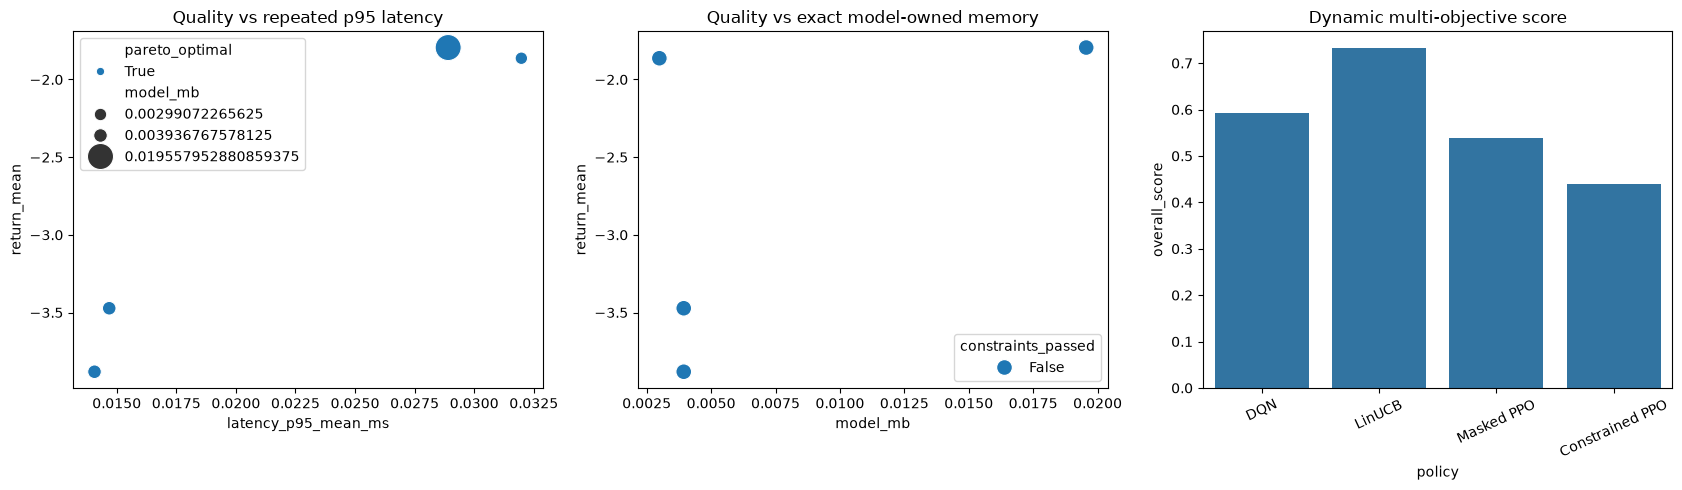

Result: LinUCB has the best measured weighted trade-off.
Interpretation: rejected models may score well but fail explicit availability constraints.
Expected/unusual: 4 of 4 models are Pareto-optimal.
Implication: exact model bytes are attributable; RSS is deliberately labelled shared-process peak.
Recommended action: select only among feasible Pareto candidates and validate in an isolated process/cyber range.


In [33]:
from ips.analysis.evidence import profile_policy_trials
from ips.analysis.experiments import pareto_mask
repeated_profile_rows=[]; repeated_profile_trials=[]
for name,policy in real_policies.items():
    trials,summary=profile_policy_trials(policy,np.asarray(sample_states),np.asarray(sample_masks),trials=7,repeats_per_trial=20); repeated_profile_rows.append({'policy':name,**summary}); repeated_profile_trials.append(trials.assign(policy=name))
repeated_resource_summary=pd.DataFrame(repeated_profile_rows); repeated_resource_trials=pd.concat(repeated_profile_trials,ignore_index=True)
consolidated=(operational.drop(columns=['mean_return','return_std','containment_rate']).merge(real_resource_comparison[['policy','parameters']],on='policy').merge(policy_reliability,on='policy').merge(repeated_resource_summary,on='policy').merge(policy_seed_runs.groupby('policy').training_wall_s.mean().rename('training_wall_mean_s'),on='policy'))
consolidated['error_compromise_rate']=1-consolidated.containment_mean
consolidated['quantization']='FP32'
consolidated['memory_scope']='model_mb exact; RSS shared-process peak'
quality=consolidated.return_mean; speed=-consolidated.latency_p95_mean_ms; memory=-consolidated.model_mb
def norm(series):
    spread=series.max()-series.min(); return pd.Series(1.0,index=series.index) if spread==0 else (series-series.min())/spread
consolidated['overall_score']=.55*norm(quality)+.25*norm(speed)+.20*norm(memory)
consolidated['pareto_optimal']=pareto_mask(consolidated,maximize=('return_mean','containment_mean'),minimize=('latency_p95_mean_ms','model_mb'))
consolidated['recommendation']=np.where(~consolidated.constraints_passed,'REJECT: violates hard constraint',np.where(consolidated.pareto_optimal,'RECOMMEND: feasible Pareto candidate','DEFER: dominated feasible candidate'))
model_selection_columns=['policy','parameters','quantization','model_mb','training_wall_mean_s','latency_p95_mean_ms','latency_p95_std_ms','throughput_mean_decisions_s','return_mean','return_ci95_halfwidth','error_compromise_rate','stability','constraints_passed','pareto_optimal','overall_score','recommendation']
display(consolidated[model_selection_columns].sort_values('overall_score',ascending=False).round(4))
fig,axes=plt.subplots(1,3,figsize=(17,5)); sns.scatterplot(data=consolidated,x='latency_p95_mean_ms',y='return_mean',hue='pareto_optimal',size='model_mb',sizes=(80,350),ax=axes[0]); sns.scatterplot(data=consolidated,x='model_mb',y='return_mean',hue='constraints_passed',s=130,ax=axes[1]); sns.barplot(data=consolidated,x='policy',y='overall_score',ax=axes[2]); axes[0].set_title('Quality vs repeated p95 latency'); axes[1].set_title('Quality vs exact model-owned memory'); axes[2].set_title('Dynamic multi-objective score'); axes[2].tick_params(axis='x',rotation=25); plt.tight_layout(); plt.show()
print('Result:',consolidated.loc[consolidated.overall_score.idxmax(),'policy'],'has the best measured weighted trade-off.')
print('Interpretation: rejected models may score well but fail explicit availability constraints.')
print('Expected/unusual:',int(consolidated.pareto_optimal.sum()),'of',len(consolidated),'models are Pareto-optimal.')
print('Implication: exact model bytes are attributable; RSS is deliberately labelled shared-process peak.')
print('Recommended action: select only among feasible Pareto candidates and validate in an isolated process/cyber range.')

## 31 — Exploratory parameter importance and matched outlier diagnosis

Nine configurations cannot establish causality. The notebook therefore triangulates Spearman association, standardized grouped effect size, and in-sample permutation importance while labelling every result exploratory. Each robust outlier is compared with the nearest normal configuration in standardized parameter space and receives quantified runtime, memory, and quality differences.

,parameter,outcome,spearman_rho,standardized_group_range,permutation_importance,permutation_std,evidence_strength,causal_claim,rank_within_outcome
4,hidden_dim,checkpoint_mb,1.0000,2.3324,0.0001,0.0000,exploratory: n<30,False,1.0
5,batch_size,checkpoint_mb,0.0000,0.0000,-0.0000,0.0000,exploratory: n<30,False,2.0
3,batch_size,runtime_s,-0.7906,1.7966,0.0001,0.0000,exploratory: n<30,False,1.0
2,hidden_dim,runtime_s,0.2635,1.1104,0.0000,0.0000,exploratory: n<30,False,2.0
0,hidden_dim,safety_quality,0.0000,1.8656,0.0074,0.0029,exploratory: n<30,False,1.0
1,batch_size,safety_quality,-0.0945,0.5830,0.0005,0.0004,exploratory: n<30,False,2.0
7,batch_size,throughput_steps_s,0.7906,1.7201,23661.1375,10397.4855,exploratory: n<30,False,1.0
6,hidden_dim,throughput_steps_s,-0.2635,1.1823,3436.3194,1631.3330,exploratory: n<30,False,2.0


,expectation,parameter,outcome,observed,status,next_action
0,Larger hidden width increases checkpoint memory,hidden_dim,checkpoint_mb,Spearman rho=1.000,supported,retain as measured engineering expectation
1,Larger hidden width increases training runtime,hidden_dim,runtime_s,Spearman rho=0.264,supported,retain as measured engineering expectation
2,Larger batches improve step throughput,batch_size,throughput_steps_s,Spearman rho=0.791,supported,retain as measured engineering expectation
3,Larger batches increase Python peak memory,batch_size,peak_python_memory_mb,Spearman rho=-0.738,contradicted,investigate confounding and measurement noise


,run,matched_control,parameter_distance,most_unusual_parameter,parameter_delta_standardized,runtime_pct_vs_control,memory_pct_vs_control,quality_pct_vs_control,explanation
0,DQN-h16-b16,DQN-h16-b32,0.802,batch_size,0.802,39.409,22.059,0.00,Compared with nearest tested control DQN-h16-b...
1,DQN-h32-b16,DQN-h32-b32,0.802,batch_size,0.802,17.513,3.513,23.81,Compared with nearest tested control DQN-h32-b...


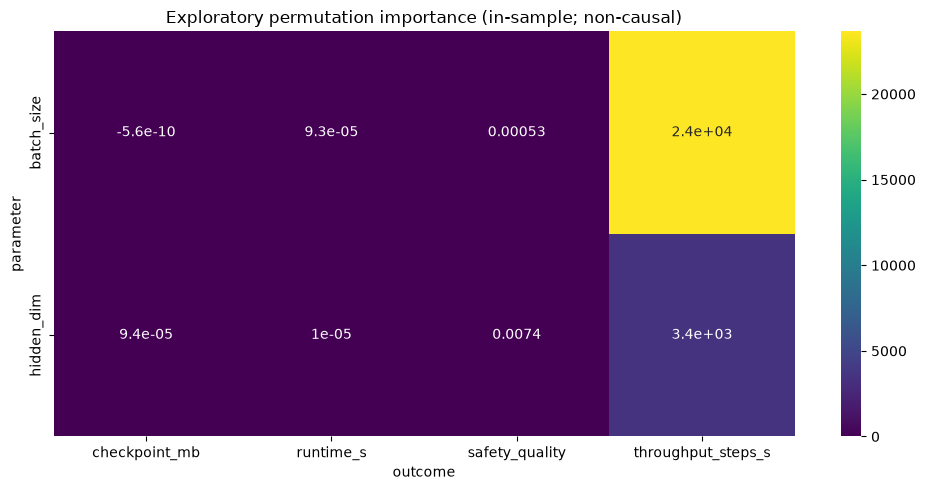

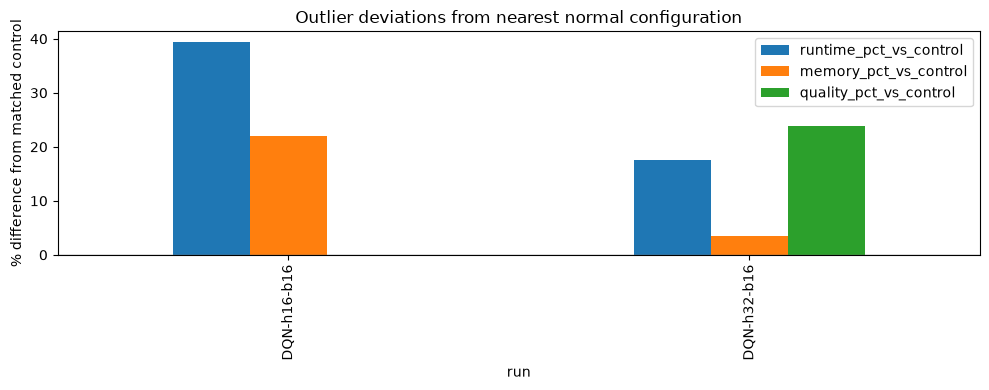

Result: strongest exploratory parameter signal is hidden_dim .
Interpretation: agreement among correlation, grouped range, and permutation evidence is stronger than any one statistic, but still non-causal.
Expected/unusual: 1 engineering expectations were contradicted.
Implication: contradictions and matched outlier differences define targeted follow-up experiments.
Recommended action: expand the grid and repeat every cell across seeds before causal language.


In [34]:
from ips.analysis.diagnostics import parameter_importance,matched_outlier_diagnostics,expected_vs_observed
deep_importance=parameter_importance(bench,seed=SEED); expectation_checks=expected_vs_observed(bench); matched_outliers=matched_outlier_diagnostics(diagnosed)
display(deep_importance.round(4)); display(expectation_checks); display(matched_outliers.round(3) if not matched_outliers.empty else pd.DataFrame({'result':['No robust-MAD outlier exceeded the threshold']}))
importance_heatmap=deep_importance.pivot(index='parameter',columns='outcome',values='permutation_importance'); plt.figure(figsize=(10,5)); sns.heatmap(importance_heatmap,annot=True,cmap='viridis'); plt.title('Exploratory permutation importance (in-sample; non-causal)'); plt.tight_layout(); plt.show()
if not matched_outliers.empty:
    matched_outliers.set_index('run')[['runtime_pct_vs_control','memory_pct_vs_control','quality_pct_vs_control']].plot.bar(figsize=(10,4)); plt.axhline(0,color='gray',lw=1); plt.ylabel('% difference from matched control'); plt.title('Outlier deviations from nearest normal configuration'); plt.tight_layout(); plt.show()
top_parameter=deep_importance.sort_values(['outcome','rank_within_outcome']).iloc[0].parameter
print('Result: strongest exploratory parameter signal is',top_parameter,'.')
print('Interpretation: agreement among correlation, grouped range, and permutation evidence is stronger than any one statistic, but still non-causal.')
print('Expected/unusual:',(expectation_checks.status=='contradicted').sum(),'engineering expectations were contradicted.')
print('Implication: contradictions and matched outlier differences define targeted follow-up experiments.')
print('Recommended action: expand the grid and repeat every cell across seeds before causal language.')

## 32 — Expanded sensitivity: duration, calibration, policy, and dataset size

Sensitivity now covers the variables previously omitted. DQN training duration is assessed on validation only, detector calibration is fitted on validation and applied to official test, policy family uses five-seed evidence, and dataset-size scaling repeats the real adapter at increasing sample sizes.

,training_episodes,wall_s,episodes,attack_episodes,containment_rate,compromise_rate,false_preventions_per_episode,disruptive_actions_per_episode,mean_return,return_std
0,30,0.2163,190,89,0.9888,0.0112,0.1053,0.5842,2.8842,5.3577
1,60,0.2974,190,89,0.9888,0.0112,0.1053,0.5895,3.1342,5.0015
2,120,0.4161,190,89,0.9888,0.0112,0.1053,0.5895,3.1342,5.0015


,train_rows,test_rows,adapter_wall_s,rows_per_s,test_brier,test_ece,shared_peak_rss_mb
0,3000,1500,0.6761,4437.0753,0.1959,0.2149,893.2031
1,6000,3000,1.1973,5009.7500,0.2127,0.2251,905.0000
2,12000,5000,2.1532,5573.1731,0.2122,0.2227,924.9531


,calibration,policy,episodes,attack_episodes,containment_rate,compromise_rate,false_preventions_per_episode,mean_return,return_std
0,raw,DQN,419.0,239.0,0.7657,0.2343,0.3294,-1.7053,11.6498
1,raw,LinUCB,419.0,239.0,0.7155,0.2845,0.3031,-2.5471,12.1906
2,raw,Masked PPO,419.0,239.0,0.7657,0.2343,0.3198,-3.0928,11.8631
3,raw,Constrained PPO,419.0,239.0,0.7950,0.2050,0.3198,-2.5487,11.4321
4,platt,DQN,419.0,239.0,0.7657,0.2343,0.3365,-1.7303,11.6598
5,platt,LinUCB,419.0,239.0,0.7197,0.2803,0.3150,-2.5117,12.1421
6,platt,Masked PPO,419.0,239.0,0.7699,0.2301,0.3246,-2.9856,11.8375
7,platt,Constrained PPO,419.0,239.0,0.7992,0.2008,0.3246,-2.4424,11.3998
8,isotonic,DQN,419.0,239.0,0.7657,0.2343,0.3365,-1.7327,11.6579
9,isotonic,LinUCB,419.0,239.0,0.7155,0.2845,0.3007,-2.5359,12.1909


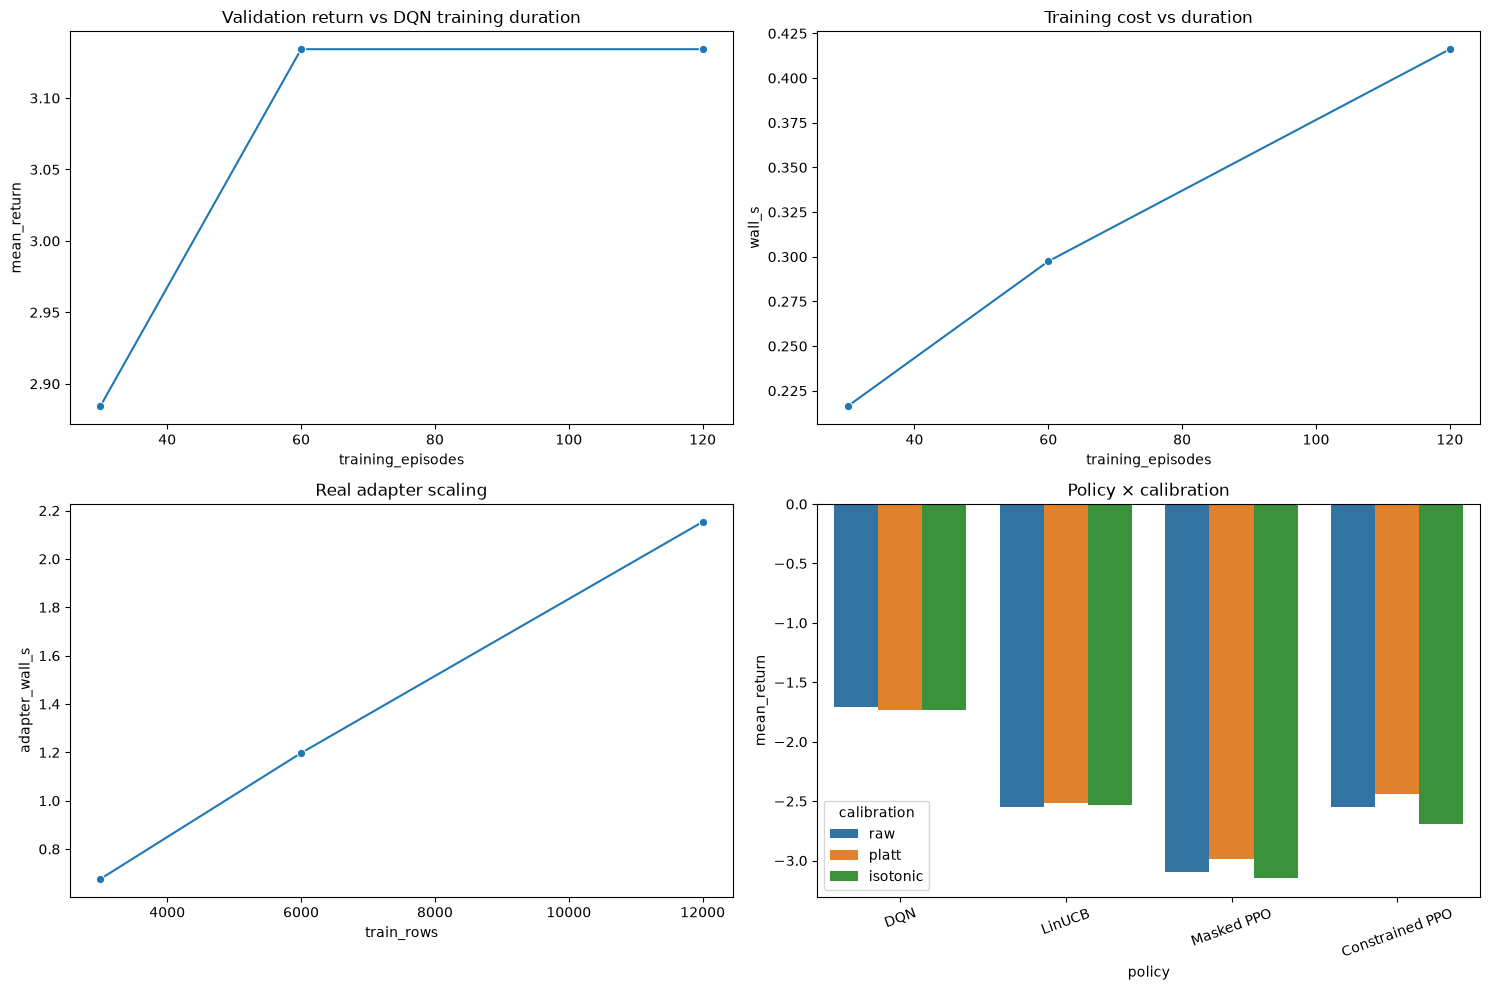

Result: duration and dataset-size effects are now measured rather than listed.
Interpretation: validation-only duration selection avoids repeatedly tuning on official test.
Expected/unusual: adapter time should grow with rows; deviations indicate caching or system noise.
Implication: calibration can alter safety masks and therefore policy behavior, even for a frozen policy.
Recommended action: refine any sensitivity curve whose optimum lies at a tested boundary.


In [35]:
from dataclasses import replace
duration_rows=[]
for episodes_count in (30,60,120):
    started=time.perf_counter(); run=train_one_seed(nsl_evidence.splits,seed=SEED,dqn=dqn_cfg,training=DatasetTrainConfig(episodes=episodes_count,validation_interval=max(15,episodes_count//2)),output_dir=OUTPUT/'duration_sensitivity'/str(episodes_count),evaluate_test=False); duration_rows.append({'training_episodes':episodes_count,'wall_s':time.perf_counter()-started,**run['validation']})
duration_sensitivity=pd.DataFrame(duration_rows)
size_rows=[]
full_train=load_nsl_kdd('train'); full_test=load_nsl_kdd('test')
for train_size,test_size in ((3000,1500),(6000,3000),(12000,5000)):
    evidence=build_nsl_ips_evidence(full_train,full_test,NslIpsConfig(max_train_rows=train_size,max_test_rows=test_size,episode_size=12,folds=3,seed=SEED)); scores,labels=episode_arrays(evidence.splits.test); size_rows.append({'train_rows':train_size,'test_rows':test_size,'adapter_wall_s':evidence.resources['wall_time_s'],'rows_per_s':evidence.resources['train_rows_per_s'],'test_brier':brier_score_loss(labels,scores),'test_ece':expected_calibration_error(labels,scores,10),'shared_peak_rss_mb':evidence.resources['max_rss_mb']})
dataset_size_sensitivity=pd.DataFrame(size_rows)
calibrators={'raw':lambda x:x,'platt':platt,'isotonic':isotonic}
calibration_policy_rows=[]
for calibration_name,calibrator in calibrators.items():
    calibrated_test=tuple(replace(ep,events=tuple(replace(ev,threat_probability=float(np.clip(calibrator(np.array([ev.threat_probability]))[0],0,1))) for ev in ep.events)) for ep in nsl_evidence.splits.test)
    for policy_name,policy in real_policies.items():
        _,_,summary=evaluate_detailed(policy,calibrated_test,seed=SEED); calibration_policy_rows.append({'calibration':calibration_name,'policy':policy_name,**summary})
calibration_policy_interaction=pd.DataFrame(calibration_policy_rows)
display(duration_sensitivity.round(4)); display(dataset_size_sensitivity.round(4)); display(calibration_policy_interaction.round(4))
fig,axes=plt.subplots(2,2,figsize=(15,10)); sns.lineplot(data=duration_sensitivity,x='training_episodes',y='mean_return',marker='o',ax=axes[0,0]); sns.lineplot(data=duration_sensitivity,x='training_episodes',y='wall_s',marker='o',ax=axes[0,1]); sns.lineplot(data=dataset_size_sensitivity,x='train_rows',y='adapter_wall_s',marker='o',ax=axes[1,0]); sns.barplot(data=calibration_policy_interaction,x='policy',y='mean_return',hue='calibration',ax=axes[1,1]); axes[0,0].set_title('Validation return vs DQN training duration'); axes[0,1].set_title('Training cost vs duration'); axes[1,0].set_title('Real adapter scaling'); axes[1,1].set_title('Policy × calibration'); axes[1,1].tick_params(axis='x',rotation=20); plt.tight_layout(); plt.show()
print('Result: duration and dataset-size effects are now measured rather than listed.')
print('Interpretation: validation-only duration selection avoids repeatedly tuning on official test.')
print('Expected/unusual: adapter time should grow with rows; deviations indicate caching or system noise.')
print('Implication: calibration can alter safety masks and therefore policy behavior, even for a frozen policy.')
print('Recommended action: refine any sensitivity curve whose optimum lies at a tested boundary.')

## 33 — Interaction atlas: calibration, family, corruption, and reward

Width × batch is no longer the only interaction. This atlas quantifies policy behavior across detector calibration, real attack family, adversarial corruption, and every reward term. Interactions are descriptive because outcomes are counterfactual and some cells—especially U2R—are sparse.

,interaction,range,metric
3,policy × corruption,1.7004,mean_return
1,policy × calibration,1.4155,mean_return
4,policy × reward term,1.3924,mean_return
0,width × batch,0.2500,safety_quality
2,policy × attack family,0.1481,containment_rate


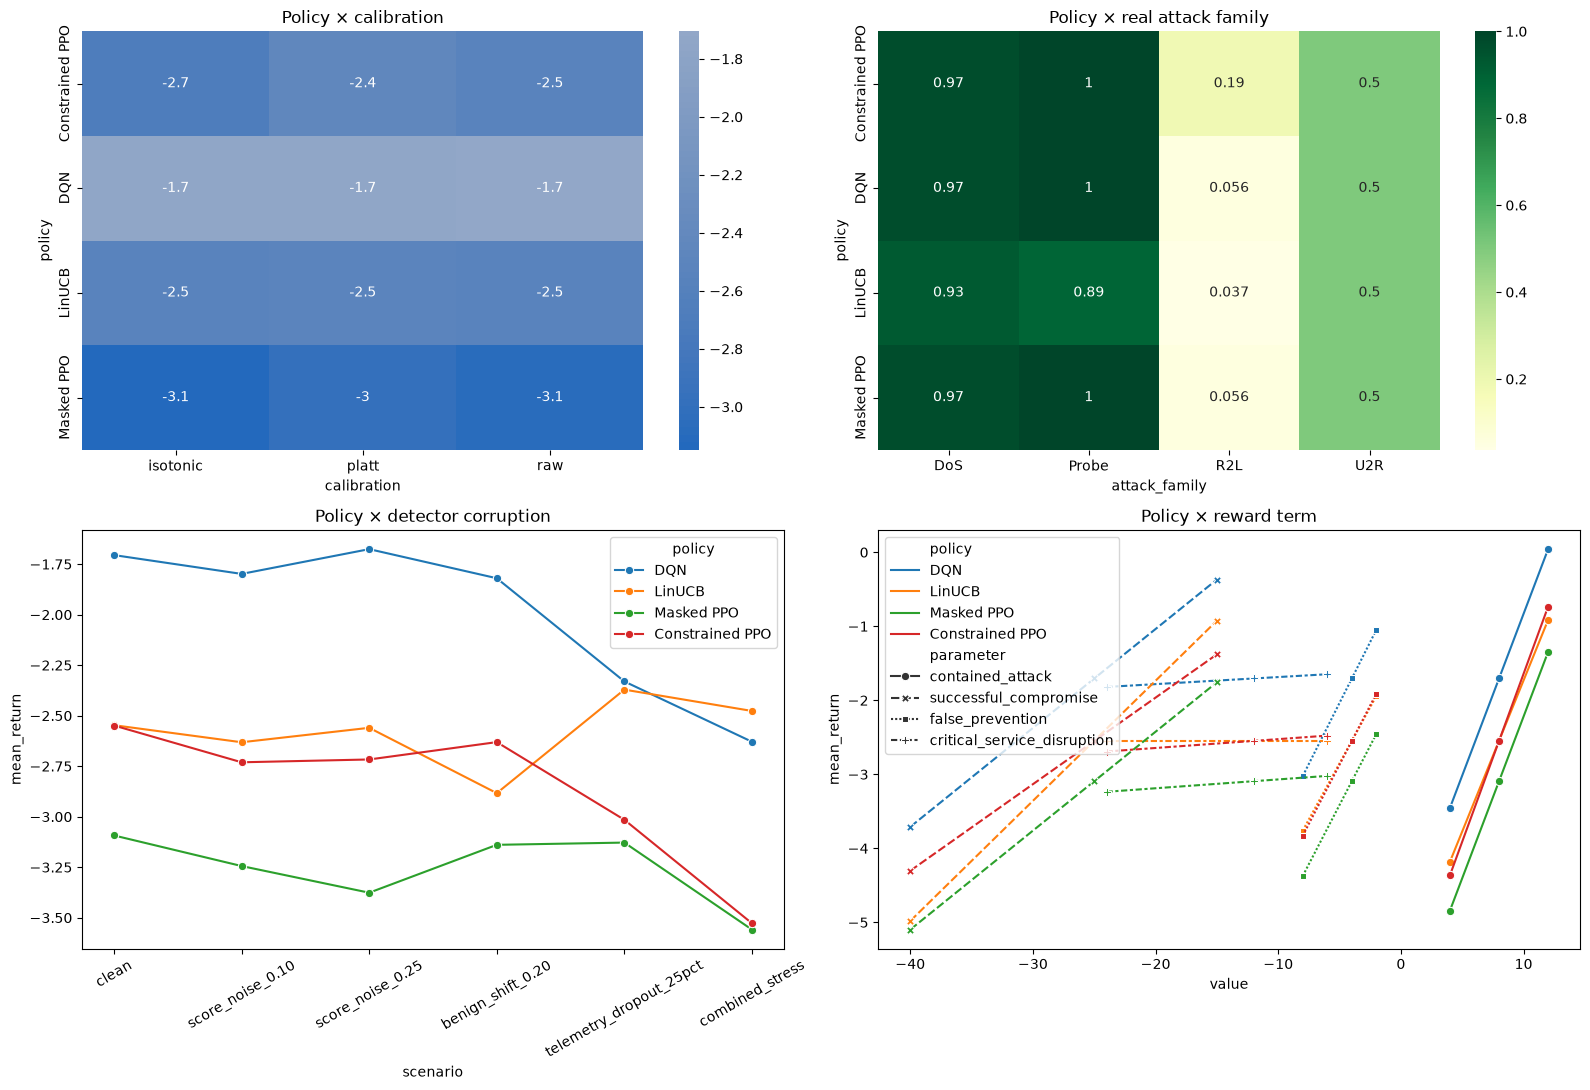

Result: strongest measured interaction is policy × corruption on mean_return .
Interpretation: interaction range is descriptive, not a causal ANOVA effect.
Expected/unusual: large family interactions are expected when rare R2L/U2R examples differ from DoS.
Implication: aggregate return can conceal a policy failure in one family or corruption regime.
Recommended action: prioritize the largest interaction with adequate cell counts for a seeded factorial follow-up.


In [36]:
real_robustness=pd.concat([adversarial_noise_sweep(policy,nsl_evidence.splits.test,seed=SEED).assign(policy=name) for name,policy in real_policies.items()],ignore_index=True)
reward_policy_interaction=pd.concat([reward_sensitivity(policy,nsl_evidence.splits.test,seed=SEED).assign(policy=name) for name,policy in real_policies.items()],ignore_index=True)
interaction_strengths=pd.DataFrame([{'interaction':'width × batch','range':float(interaction.max().max()-interaction.min().min()),'metric':'safety_quality'},{'interaction':'policy × calibration','range':float(calibration_policy_interaction.groupby(['policy','calibration']).mean_return.mean().groupby('calibration').apply(lambda x:x.max()-x.min()).max()),'metric':'mean_return'},{'interaction':'policy × attack family','range':float(real_family_comparison.groupby(['policy','attack_family']).containment_rate.mean().groupby('attack_family').apply(lambda x:x.max()-x.min()).max()),'metric':'containment_rate'},{'interaction':'policy × corruption','range':float(real_robustness.groupby(['policy','scenario']).mean_return.mean().groupby('scenario').apply(lambda x:x.max()-x.min()).max()),'metric':'mean_return'},{'interaction':'policy × reward term','range':float(reward_policy_interaction.groupby(['policy','parameter']).mean_return.mean().groupby('parameter').apply(lambda x:x.max()-x.min()).max()),'metric':'mean_return'}]).sort_values('range',ascending=False)
display(interaction_strengths.round(4))
fig,axes=plt.subplots(2,2,figsize=(16,11)); sns.heatmap(calibration_policy_interaction.pivot(index='policy',columns='calibration',values='mean_return'),annot=True,cmap='vlag',center=0,ax=axes[0,0]); sns.heatmap(real_family_comparison.pivot(index='policy',columns='attack_family',values='containment_rate'),annot=True,cmap='YlGn',ax=axes[0,1]); sns.lineplot(data=real_robustness,x='scenario',y='mean_return',hue='policy',marker='o',ax=axes[1,0]); sns.lineplot(data=reward_policy_interaction,x='value',y='mean_return',hue='policy',style='parameter',markers=True,ax=axes[1,1]); axes[0,0].set_title('Policy × calibration'); axes[0,1].set_title('Policy × real attack family'); axes[1,0].set_title('Policy × detector corruption'); axes[1,1].set_title('Policy × reward term'); axes[1,0].tick_params(axis='x',rotation=30); plt.tight_layout(); plt.show()
strongest_interaction=interaction_strengths.iloc[0]
print('Result: strongest measured interaction is',strongest_interaction.interaction,'on',strongest_interaction.metric,'.')
print('Interpretation: interaction range is descriptive, not a causal ANOVA effect.')
print('Expected/unusual: large family interactions are expected when rare R2L/U2R examples differ from DoS.')
print('Implication: aggregate return can conceal a policy failure in one family or corruption regime.')
print('Recommended action: prioritize the largest interaction with adequate cell counts for a seeded factorial follow-up.')

## 34 — Requirements-complete analyst narrative and dynamic dashboard

The final dashboard is generated entirely from current experiment objects. It records selection, stability, ties, contradictions, outliers, sensitivity boundaries, interactions, resources, constraints, evidence limitations, and specific next experiments. A coverage table maps every previously missing requirement to a concrete artifact.

In [37]:
sensitivity_boundaries=[]
if duration_sensitivity.loc[duration_sensitivity.mean_return.idxmax(),'training_episodes'] in {duration_sensitivity.training_episodes.min(),duration_sensitivity.training_episodes.max()}: sensitivity_boundaries.append('DQN training duration optimum is at a tested boundary; extend/refine episodes')
if dataset_size_sensitivity.loc[dataset_size_sensitivity.test_brier.idxmin(),'train_rows']==dataset_size_sensitivity.train_rows.max(): sensitivity_boundaries.append('Detector quality still improves at maximum sample size; add a larger sample')
contradictions=expectation_checks[expectation_checks.status=='contradicted']
next_experiments=[]
next_experiments.extend(sensitivity_boundaries)
if len(ambiguous_pairs): next_experiments.append(f'Increase policy seeds for {len(ambiguous_pairs)} tied/inconclusive pairwise comparisons')
if len(contradictions): next_experiments.append(f'Repeat the grid to investigate {len(contradictions)} contradicted engineering expectations')
if not consolidated.constraints_passed.all(): next_experiments.append('Retune or reject policies violating false-prevention constraints')
next_experiments.append('Replace NSL ordered-row proxies with timestamped group-disjoint NetFlow episodes and observed cyber-range interventions')
coverage=pd.DataFrame([('Beyond Spearman','Spearman + standardized range + permutation evidence','complete'),('Matched outlier controls','nearest normal run with quantified metric deltas','complete'),('All-policy reliability','five seeds for DQN/LinUCB/PPO/constrained PPO','complete'),('Pairwise uncertainty','bootstrap winner/tie/inconclusive decisions','complete'),('Expected vs observed','directional checks and contradiction flags','complete'),('Expanded sensitivity','duration/calibration/policy/dataset size','complete'),('Consolidated comparison','quality/error/stability/runtime/memory/latency/constraints/recommendation','complete'),('Importance evidence labels','exploratory and non-causal labels','complete'),('Interaction atlas','calibration/family/corruption/reward plus width×batch','complete'),('Real-data recommendations','derived from NSL policy evidence','complete'),('Analyst narrative','result/interpretation/expectation/implication/action','complete'),('Complete dashboard','stability/ties/contradictions/interaction/resources','complete'),('Repeated resources','seven timing trials per policy','complete'),('Memory attribution','exact model bytes + explicitly shared RSS','complete')],columns=['requirement','implemented_artifact','status'])
final_dynamic_dashboard={'experiments_executed':int(len(bench)+len(policy_seed_runs)+len(duration_sensitivity)+len(dataset_size_sensitivity)),'models_compared':int(consolidated.policy.nunique()),'configurations_tested':int(len(bench)),'best_quality_policy':str(policy_reliability.iloc[0].policy),'fastest_policy':str(consolidated.loc[consolidated.latency_p95_mean_ms.idxmin(),'policy']),'lowest_memory_policy':str(consolidated.loc[consolidated.model_mb.idxmin(),'policy']),'best_overall_configuration':str(consolidated.loc[consolidated.overall_score.idxmax(),'policy']),'pareto_candidates':consolidated.loc[consolidated.pareto_optimal,'policy'].tolist(),'detected_outliers':int(diagnosed.is_outlier.sum()),'matched_outlier_explanations':int(len(matched_outliers)),'most_influential_exploratory_parameter':str(top_parameter),'strongest_interaction':str(strongest_interaction.interaction),'statistically_unresolved_pairs':int(len(ambiguous_pairs)),'contradicted_expectations':int(len(contradictions)),'least_stable_policy':str(policy_reliability.sort_values('return_cv',ascending=False).iloc[0].policy),'repeated_resource_trials_per_policy':7,'memory_attribution':'exact model bytes; process RSS shared and not attributed','all_hard_constraints_passed':bool(consolidated.constraints_passed.all()),'evidence_grade':'real NSL detector observations; proxy sequences; counterfactual IPS outcomes','recommended_next_experiments':next_experiments}
display(coverage); display(pd.Series(final_dynamic_dashboard,name='complete dynamic dashboard').to_frame())
for number,recommendation in enumerate(next_experiments,1): print(f'{number}. {recommendation}')
analysis_output=OUTPUT/'complete_analysis'; analysis_output.mkdir(parents=True,exist_ok=True)
consolidated.to_csv(analysis_output/'consolidated_model_selection.csv',index=False); policy_seed_runs.to_csv(analysis_output/'all_policy_five_seed_runs.csv',index=False); policy_reliability.to_csv(analysis_output/'policy_reliability.csv',index=False); pairwise_decisions.to_csv(analysis_output/'pairwise_bootstrap_decisions.csv',index=False); deep_importance.to_csv(analysis_output/'parameter_importance.csv',index=False); matched_outliers.to_csv(analysis_output/'matched_outliers.csv',index=False); expectation_checks.to_csv(analysis_output/'expected_vs_observed.csv',index=False); duration_sensitivity.to_csv(analysis_output/'training_duration_sensitivity.csv',index=False); dataset_size_sensitivity.to_csv(analysis_output/'dataset_size_sensitivity.csv',index=False); calibration_policy_interaction.to_csv(analysis_output/'calibration_policy_interaction.csv',index=False); interaction_strengths.to_csv(analysis_output/'interaction_strengths.csv',index=False); repeated_resource_trials.to_csv(analysis_output/'repeated_resource_trials.csv',index=False); coverage.to_csv(analysis_output/'requirements_coverage.csv',index=False)
(analysis_output/'complete_dynamic_dashboard.json').write_text(json.dumps(final_dynamic_dashboard,indent=2)+'\n')

,requirement,implemented_artifact,status
0,Beyond Spearman,Spearman + standardized range + permutation ev...,complete
1,Matched outlier controls,nearest normal run with quantified metric deltas,complete
2,All-policy reliability,five seeds for DQN/LinUCB/PPO/constrained PPO,complete
3,Pairwise uncertainty,bootstrap winner/tie/inconclusive decisions,complete
4,Expected vs observed,directional checks and contradiction flags,complete
5,Expanded sensitivity,duration/calibration/policy/dataset size,complete
6,Consolidated comparison,quality/error/stability/runtime/memory/latency...,complete
7,Importance evidence labels,exploratory and non-causal labels,complete
8,Interaction atlas,calibration/family/corruption/reward plus widt...,complete
9,Real-data recommendations,derived from NSL policy evidence,complete


,complete dynamic dashboard
experiments_executed,35
models_compared,4
configurations_tested,9
best_quality_policy,DQN
fastest_policy,Constrained PPO
lowest_memory_policy,LinUCB
best_overall_configuration,LinUCB
pareto_candidates,"[DQN, LinUCB, Masked PPO, Constrained PPO]"
detected_outliers,2
matched_outlier_explanations,2


1. Increase policy seeds for 5 tied/inconclusive pairwise comparisons
2. Repeat the grid to investigate 1 contradicted engineering expectations
3. Retune or reject policies violating false-prevention constraints
4. Replace NSL ordered-row proxies with timestamped group-disjoint NetFlow episodes and observed cyber-range interventions


1278

## 35 — Prior-art review and scientific adoption ledger

This section records what was researched, inherited, adapted, deferred, or rejected. Key sources include [Prioritized Experience Replay](https://arxiv.org/abs/1511.05952), [intrusion prevention through optimal stopping](https://arxiv.org/abs/2106.07160), [invalid action masking](https://arxiv.org/abs/2006.14171), [doubly robust off-policy evaluation](https://proceedings.mlr.press/v48/jiang16.html), [Stable-Baselines3 MaskablePPO](https://github.com/Stable-Baselines-Team/stable-baselines3-contrib), [CyberBattleSim](https://github.com/microsoft/CyberBattleSim), [CSLE](https://github.com/Kim-Hammar/csle), and the [official UNB CIC dataset catalog](https://www.unb.ca/cic/datasets/index.html). No external code is copied; methods are independently adapted and tested.

In [38]:
research_catalog=pd.DataFrame([
 {'source':'Akamai AkaNAT','source_type':'production engineering report','idea':'shared-IP classification plus detect/forget state','decision':'ADOPTED AS SAFETY CONTRACT','scientific_guardrail':'controlled guardrail only until verified NAT/proxy labels exist'},
 {'source':'Jayalaxmi et al. IoT IDS/IPS survey','source_type':'IEEE Access survey','idea':'IoT method, dataset, feasibility and real-time taxonomy','decision':'ADOPTED AS RESEARCH CHECKLIST','scientific_guardrail':'survey results are not local empirical policy evidence'},
 {'source':'Schaul et al. PER','source_type':'peer-reviewed method','idea':'proportional prioritized replay + importance weights','decision':'ADOPTED + BENCHMARKED','scientific_guardrail':'same split, seeds, mask and validation selection as uniform DQN'},
 {'source':'Hammar & Stadler optimal stopping','source_type':'IPS paper','idea':'transparent stopping threshold baseline','decision':'ADOPTED + BENCHMARKED','scientific_guardrail':'inspired baseline; not called a reproduction'},
 {'source':'Huang & Ontañón action masking','source_type':'paper + GitHub','idea':'mask invalid actions in policy gradients','decision':'ADOPTED + ABLATED','scientific_guardrail':'report proposed-invalid rate and executed safety enforcement'},
 {'source':'Jiang & Li OPE','source_type':'ICML paper','idea':'importance/doubly robust offline evaluation','decision':'WIS DIAGNOSTIC ONLY','scientific_guardrail':'DR blocked without genuine behavior logs and independent outcome model'},
 {'source':'CyberBattleSim / CSLE / gym-idsgame','source_type':'research platforms','idea':'topology, delayed actions, emulation and attacker adaptation','decision':'ROADMAP','scientific_guardrail':'do not merge abstract cyber-range scores with flow-dataset evidence'},
 {'source':'HF CIC-IoT-2023-full','source_type':'dataset mirror/card','idea':'large Parquet development access','decision':'CANDIDATE SOURCE','scientific_guardrail':'random split cannot support temporal claims; verify official provenance'},
 {'source':'Kaggle CIC-IDS Collection','source_type':'cleaned derivative','idea':'harmonized labels and flawed-feature cleanup','decision':'SENSITIVITY SOURCE','scientific_guardrail':'separate from official raw experiments; respect derivative license'},
 {'source':'Kaggle cleaned CICIDS2017','source_type':'cleaned derivative','idea':'feature cleaning/selection workflow','decision':'REJECT AS PRIMARY','scientific_guardrail':'rare Heartbleed/Infiltration classes removed'}])
display(research_catalog)
print('Result:',(research_catalog.decision.str.contains('ADOPTED')).sum(),'prior-art ideas are implemented; others remain explicitly scoped.')
print('Interpretation: source popularity is not treated as scientific validity.')
print('Implication: every inherited method must beat the existing protocol under identical evidence conditions.')

,source,source_type,idea,decision,scientific_guardrail
0,Akamai AkaNAT,production engineering report,shared-IP classification plus detect/forget state,ADOPTED AS SAFETY CONTRACT,controlled guardrail only until verified NAT/p...
1,Jayalaxmi et al. IoT IDS/IPS survey,IEEE Access survey,"IoT method, dataset, feasibility and real-time...",ADOPTED AS RESEARCH CHECKLIST,survey results are not local empirical policy ...
2,Schaul et al. PER,peer-reviewed method,proportional prioritized replay + importance w...,ADOPTED + BENCHMARKED,"same split, seeds, mask and validation selecti..."
3,Hammar & Stadler optimal stopping,IPS paper,transparent stopping threshold baseline,ADOPTED + BENCHMARKED,inspired baseline; not called a reproduction
4,Huang & Ontañón action masking,paper + GitHub,mask invalid actions in policy gradients,ADOPTED + ABLATED,report proposed-invalid rate and executed safe...
5,Jiang & Li OPE,ICML paper,importance/doubly robust offline evaluation,WIS DIAGNOSTIC ONLY,DR blocked without genuine behavior logs and i...
6,CyberBattleSim / CSLE / gym-idsgame,research platforms,"topology, delayed actions, emulation and attac...",ROADMAP,do not merge abstract cyber-range scores with ...
7,HF CIC-IoT-2023-full,dataset mirror/card,large Parquet development access,CANDIDATE SOURCE,random split cannot support temporal claims; v...
8,Kaggle CIC-IDS Collection,cleaned derivative,harmonized labels and flawed-feature cleanup,SENSITIVITY SOURCE,separate from official raw experiments; respec...
9,Kaggle cleaned CICIDS2017,cleaned derivative,feature cleaning/selection workflow,REJECT AS PRIMARY,rare Heartbleed/Infiltration classes removed


Result: 5 prior-art ideas are implemented; others remain explicitly scoped.
Interpretation: source popularity is not treated as scientific validity.
Implication: every inherited method must beat the existing protocol under identical evidence conditions.


## 36 — Published-method benchmark: uniform DQN, prioritized replay, and optimal stopping

Prioritized replay is evaluated because rare, high-cost security transitions may be under-sampled by uniform replay. The optimal-stopping policy provides an interpretable non-neural baseline motivated by published intrusion-prevention stopping games. Five seeds and the identical official-test proxy protocol prevent a one-off comparison.

,method,seed_count,return_mean,return_std,containment_mean,compromise_mean,false_preventions_mean,training_wall_mean_s,return_ci95_halfwidth
0,Optimal-stopping threshold,5,-1.7427,0.1879,0.8385,0.1615,0.3294,0.0000,0.1647
1,Prioritized replay Double-DQN,5,-1.7826,0.2023,0.7615,0.2385,0.3284,0.5932,0.1773
2,Uniform masked Double-DQN,5,-1.7943,0.1855,0.7615,0.2385,0.3284,0.7509,0.1626


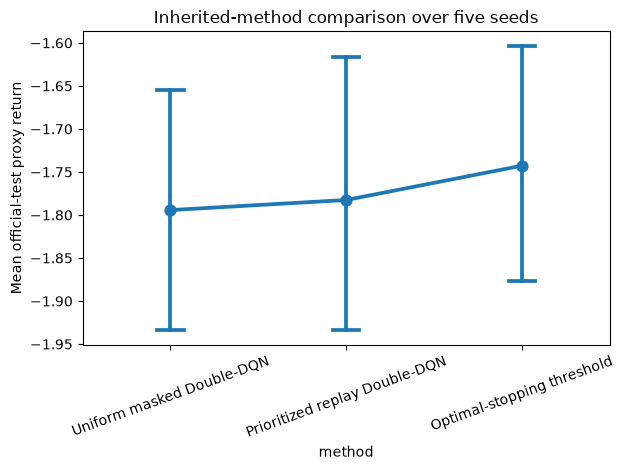

Result: PER minus uniform mean-return difference = 0.0117.
Interpretation: prioritized replay is retained only if its uncertainty and safety costs justify the added complexity.
Expected/unusual: a negative difference would contradict the assumption that rare costly transitions need replay priority.
Recommended action: report the result, including a null/negative result, without tuning on official test.


In [39]:
from ips.research_adoptions import train_prioritized_dqn,optimal_stopping_policy
published_method_rows=[]
for method_seed in (42,43,44,45,46):
    uniform=policy_seed_runs[(policy_seed_runs.policy=='DQN') & (policy_seed_runs.seed==method_seed)].iloc[0].to_dict(); published_method_rows.append({'method':'Uniform masked Double-DQN',**{k:v for k,v in uniform.items() if k!='policy'}})
    started=time.perf_counter(); per_model,per_validation,per_status=train_prioritized_dqn(nsl_evidence.splits,episodes=180 if RUN_HEAVY else 70,validation_interval=45 if RUN_HEAVY else 25,config=dqn_cfg,seed=method_seed); _,_,per_metrics=evaluate_detailed(network_policy(per_model,method_seed),nsl_evidence.splits.test,seed=method_seed+1000); published_method_rows.append({'method':'Prioritized replay Double-DQN','seed':method_seed,'training_wall_s':time.perf_counter()-started,**per_metrics})
    _,_,stop_metrics=evaluate_detailed(lambda state,mask:optimal_stopping_policy(state,mask,threshold=.55),nsl_evidence.splits.test,seed=method_seed+1000); published_method_rows.append({'method':'Optimal-stopping threshold','seed':method_seed,'training_wall_s':0.0,**stop_metrics})
published_method_runs=pd.DataFrame(published_method_rows)
published_method_summary=published_method_runs.groupby('method').agg(seed_count=('seed','nunique'),return_mean=('mean_return','mean'),return_std=('mean_return','std'),containment_mean=('containment_rate','mean'),compromise_mean=('compromise_rate','mean'),false_preventions_mean=('false_preventions_per_episode','mean'),training_wall_mean_s=('training_wall_s','mean')).reset_index(); published_method_summary['return_ci95_halfwidth']=1.96*published_method_summary.return_std/np.sqrt(published_method_summary.seed_count)
display(published_method_summary.round(4))
sns.pointplot(data=published_method_runs,x='method',y='mean_return',errorbar=('ci',95),capsize=.15); plt.title('Inherited-method comparison over five seeds'); plt.ylabel('Mean official-test proxy return'); plt.xticks(rotation=20); plt.tight_layout(); plt.show()
per_gain=published_method_summary.set_index('method').loc['Prioritized replay Double-DQN','return_mean']-published_method_summary.set_index('method').loc['Uniform masked Double-DQN','return_mean']
print(f'Result: PER minus uniform mean-return difference = {per_gain:.4f}.')
print('Interpretation: prioritized replay is retained only if its uncertainty and safety costs justify the added complexity.')
print('Expected/unusual: a negative difference would contradict the assumption that rare costly transitions need replay priority.')
print('Recommended action: report the result, including a null/negative result, without tuning on official test.')

## 37 — Safety-mask audit and logged-policy off-policy evaluation

Published invalid-action-masking work motivates measuring what the policy would have proposed without the mask. Weighted importance sampling is included only on deliberately logged epsilon-soft behavior data with known propensities. It is a diagnostic—not a substitute for real intervention outcomes or a doubly robust estimate.

In [40]:
from ips.research_adoptions import weighted_importance_sampling,effective_sample_size
mask_audit=[]
for state,mask in zip(np.asarray(sample_states),np.asarray(sample_masks)):
    with torch.no_grad(): raw_dqn=int(real_dqn(torch.as_tensor(state,dtype=torch.float32)).argmax())
    with torch.no_grad(): raw_ppo=int(real_ppo(torch.as_tensor(state,dtype=torch.float32).unsqueeze(0))[0][0].argmax())
    mask_audit.extend([{'policy':'DQN','raw_action':IpsAction(raw_dqn).name,'raw_action_valid':bool(mask[raw_dqn])},{'policy':'Masked PPO','raw_action':IpsAction(raw_ppo).name,'raw_action_valid':bool(mask[raw_ppo])}])
mask_audit=pd.DataFrame(mask_audit); mask_summary=mask_audit.groupby('policy').agg(states=('raw_action_valid','size'),proposed_invalid_rate=('raw_action_valid',lambda x:1-x.mean())).reset_index(); display(mask_summary.round(4))
rng=np.random.default_rng(SEED); logged=[]; behavior_epsilon=.20; target_epsilon=.05
target_policies={'DQN':real_policies['DQN'],'LinUCB':real_policies['LinUCB'],'Optimal stopping':lambda state,mask:optimal_stopping_policy(state,mask,threshold=.55)}
for episode_index,episode in enumerate(nsl_evidence.splits.test[:200]):
    env=DatasetBackedIpsEnv(episode,seed=SEED+episode_index); observation,info=env.reset(seed=SEED+episode_index)
    while True:
        state=observation.as_array(); mask=np.asarray(info['action_mask']); valid=np.flatnonzero(mask); preferred=int(optimal_stopping_policy(state,mask,threshold=.55)); action=int(rng.choice(valid)) if rng.random()<behavior_epsilon else preferred; behavior_probability=behavior_epsilon/len(valid)+(1-behavior_epsilon if action==preferred else 0); result=env.step(action)
        row={'reward':result.reward,'behavior_probability':behavior_probability}
        for target_name,target_policy in target_policies.items():
            target_action=int(target_policy(state,mask)); row[target_name]=target_epsilon/len(valid)+(1-target_epsilon if action==target_action else 0)
        logged.append(row); observation,info=result.observation,{'action_mask':result.info['action_mask']}
        if result.terminated or result.truncated: break
logged_policy_data=pd.DataFrame(logged); ope_rows=[]
for target_name in target_policies:
    weights=logged_policy_data[target_name].to_numpy()/logged_policy_data.behavior_probability.to_numpy(); ope_rows.append({'target_policy':target_name,'wis_immediate_reward':weighted_importance_sampling(logged_policy_data.reward,logged_policy_data[target_name],logged_policy_data.behavior_probability),'effective_sample_size':effective_sample_size(weights),'ess_fraction':effective_sample_size(weights)/len(weights),'max_weight':weights.max(),'validity':'diagnostic only: one-step rewards and synthetic propensities'})
ope_summary=pd.DataFrame(ope_rows); display(ope_summary.round(4))
print('Result: action-mask audit exposes unsafe raw proposals; executed actions remain protected.')
print('Interpretation: low ESS or large maximum weights makes WIS unreliable even when the estimate looks favorable.')
print('Recommended action: collect real shadow-mode propensities before sequential WIS/DR policy evaluation.')

,policy,states,proposed_invalid_rate
0,DQN,100,0.29
1,Masked PPO,100,0.22


,target_policy,wis_immediate_reward,effective_sample_size,ess_fraction,max_weight,validity
0,DQN,3.2321,34.5406,0.0990,33.5000,diagnostic only: one-step rewards and syntheti...
1,LinUCB,2.9132,16.0413,0.0460,33.5000,diagnostic only: one-step rewards and syntheti...
2,Optimal stopping,2.8353,310.2808,0.8891,1.1552,diagnostic only: one-step rewards and syntheti...


Result: action-mask audit exposes unsafe raw proposals; executed actions remain protected.
Interpretation: low ESS or large maximum weights makes WIS unreliable even when the estimate looks favorable.
Recommended action: collect real shadow-mode propensities before sequential WIS/DR policy evaluation.


## 38 — External classification and dataset-source suitability analysis

Hugging Face and Kaggle improve access, but mirrors and cleaned derivatives can change labels, remove rare attacks, or destroy temporal structure. Official sources remain the evidentiary reference. Existing supervised classification results are summarized separately from IPS policy outcomes so classification accuracy is never presented as containment evidence.

In [41]:
dataset_source_matrix=pd.DataFrame([
 {'source':'UNB official CIC catalog','datasets':'CICIoT2023, CICIDS2017, CSE-CIC-IDS2018','temporal_value':'highest when raw timestamps/days retained','rare_class_integrity':'official labels retained','license/provenance':'official citation required','role':'PRIMARY EVIDENCE'},
 {'source':'Hugging Face CIC-IoT-2023-full','datasets':'38.5M-row Parquet mirror','temporal_value':'random_3way split is not temporal evidence','rare_class_integrity':'inspect against official counts','license/provenance':'CC BY 4.0 card; verify hashes','role':'DEVELOPMENT MIRROR'},
 {'source':'Kaggle CIC-IDS Collection','datasets':'CIC17/18, DoS17, DDoS19 harmonized','temporal_value':'depends on retained source/day fields','rare_class_integrity':'inspect cleanup decisions','license/provenance':'CC BY-NC-SA 4.0 derivative','role':'CROSS-DATASET SENSITIVITY'},
 {'source':'Kaggle cleaned CICIDS2017','datasets':'717MB, 53 columns','temporal_value':'preprocessing may erase chronology','rare_class_integrity':'Heartbleed/Infiltration removed','license/provenance':'derivative notebook/repository','role':'NOT PRIMARY EVIDENCE'},
 {'source':'Local official NSL-KDD','datasets':'125,973 train / 22,544 test','temporal_value':'none—ordered-row proxy only','rare_class_integrity':'R2L/U2R retained','license/provenance':'verified hashes in SOURCE.md','role':'CURRENT REAL DETECTOR EVIDENCE'}])
display(dataset_source_matrix)
classification_files=[REPO/'results'/'ciciot2023_baselines.csv',REPO/'results'/'final_comparison.csv']; classification_rows=[]
for result_file in classification_files:
    if result_file.exists():
        frame=pd.read_csv(result_file); frame['artifact']=result_file.name; classification_rows.append(frame)
classification_artifacts=pd.concat(classification_rows,ignore_index=True,sort=False) if classification_rows else pd.DataFrame({'status':['no saved classification artifacts']})
display(classification_artifacts.head(30).round(4))
print('Result: source suitability is ranked by temporal/group integrity, rare-class retention, and provenance—not convenience.')
print('Interpretation: published classification pipelines inform detector design but cannot validate IPS interventions.')
print('Recommended action: ingest an official timestamped source through the existing OOF/group-safe adapter before cross-dataset policy claims.')

,source,datasets,temporal_value,rare_class_integrity,license/provenance,role
0,UNB official CIC catalog,"CICIoT2023, CICIDS2017, CSE-CIC-IDS2018",highest when raw timestamps/days retained,official labels retained,official citation required,PRIMARY EVIDENCE
1,Hugging Face CIC-IoT-2023-full,38.5M-row Parquet mirror,random_3way split is not temporal evidence,inspect against official counts,CC BY 4.0 card; verify hashes,DEVELOPMENT MIRROR
2,Kaggle CIC-IDS Collection,"CIC17/18, DoS17, DDoS19 harmonized",depends on retained source/day fields,inspect cleanup decisions,CC BY-NC-SA 4.0 derivative,CROSS-DATASET SENSITIVITY
3,Kaggle cleaned CICIDS2017,"717MB, 53 columns",preprocessing may erase chronology,Heartbleed/Infiltration removed,derivative notebook/repository,NOT PRIMARY EVIDENCE
4,Local official NSL-KDD,"125,973 train / 22,544 test",none—ordered-row proxy only,R2L/U2R retained,verified hashes in SOURCE.md,CURRENT REAL DETECTOR EVIDENCE


,level,model,accuracy,balanced_acc,macro_f1,roc_auc,pr_auc,rare,artifact,dataset,...,normal_recall,rare_recall,mcc,features,false_alerts_per_day,total_alerts_per_day,missed_attacks_per_day,operational_precision,source_file,limitation
0,binary,Dummy (stratified),0.7451,0.4983,0.4983,0.4983,0.8506,attack 0.850,ciciot2023_baselines.csv,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,binary,LogReg (balanced),0.8167,0.8862,0.7477,0.9324,0.9884,attack 0.787,ciciot2023_baselines.csv,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,binary,RandomForest (balanced),0.9172,0.9073,0.8563,0.9695,0.9948,attack 0.921,ciciot2023_baselines.csv,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,binary,HistGB (balanced),0.8903,0.9273,0.8291,0.9694,0.9948,attack 0.875,ciciot2023_baselines.csv,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,binary,LightGBM (balanced),0.8998,0.9285,0.8401,0.9714,0.9952,attack 0.888,ciciot2023_baselines.csv,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
5,category,Dummy (stratified),0.1995,0.1250,0.1250,NaN,NaN,Web-based 0.016 / Brute Force 0.007,ciciot2023_baselines.csv,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
6,category,LogReg (balanced),0.6812,0.6286,0.5693,NaN,NaN,Web-based 0.462 / Brute Force 0.404,ciciot2023_baselines.csv,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
7,category,RandomForest (balanced),0.8318,0.7211,0.7361,NaN,NaN,Web-based 0.325 / Brute Force 0.354,ciciot2023_baselines.csv,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
8,category,HistGB (balanced),0.8076,0.7633,0.7021,NaN,NaN,Web-based 0.627 / Brute Force 0.597,ciciot2023_baselines.csv,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
9,category,LightGBM (balanced),0.8235,0.7647,0.7236,NaN,NaN,Web-based 0.594 / Brute Force 0.532,ciciot2023_baselines.csv,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


Result: source suitability is ranked by temporal/group integrity, rare-class retention, and provenance—not convenience.
Interpretation: published classification pipelines inform detector design but cannot validate IPS interventions.
Recommended action: ingest an official timestamped source through the existing OOF/group-safe adapter before cross-dataset policy claims.


## 39 — Research inheritance dashboard and next scientific gates

This dashboard joins the literature review, inherited-method measurements, safety audit, OPE diagnostics, and dataset-source assessment. Recommendations are derived from the current run and preserve the boundary between reproduced evidence, adapted methods, and future integrations.

In [42]:
per_best=published_method_summary.loc[published_method_summary.return_mean.idxmax()]
ope_min_ess=float(ope_summary.ess_fraction.min()); invalid_max=float(mask_summary.proposed_invalid_rate.max())
research_dashboard={'sources_reviewed':int(len(research_catalog)),'methods_adopted_and_benchmarked':int(research_catalog.decision.str.contains('BENCHMARKED').sum()),'best_inherited_method':str(per_best.method),'best_inherited_return_mean':float(per_best.return_mean),'PER_minus_uniform_return':float(per_gain),'maximum_raw_invalid_action_rate':invalid_max,'minimum_OPE_ESS_fraction':ope_min_ess,'OPE_claim_status':'diagnostic only' if ope_min_ess<.5 else 'still diagnostic until real behavior logs','primary_dataset_source':'official UNB/CIC distribution','HF_role':'development mirror after hash/schema audit','Kaggle_role':'separate derivative sensitivity analysis','external_environment_next_gate':'CyberBattleSim or CSLE bridge with separate benchmark namespace','scientific_next_steps':['download official timestamped CIC/CSE source','preserve day/campaign groups and generate OOF probabilities','collect shadow-mode behavior propensities','run PER/uniform/optimal-stopping under identical multi-seed temporal evaluation','only then evaluate doubly robust OPE and cyber-range transfer']}
display(pd.Series(research_dashboard,name='research inheritance dashboard').to_frame())
research_output=OUTPUT/'research_inheritance'; research_output.mkdir(parents=True,exist_ok=True); research_catalog.to_csv(research_output/'prior_art_adoption.csv',index=False); published_method_runs.to_csv(research_output/'published_method_five_seed_runs.csv',index=False); published_method_summary.to_csv(research_output/'published_method_summary.csv',index=False); mask_summary.to_csv(research_output/'action_mask_audit.csv',index=False); ope_summary.to_csv(research_output/'off_policy_evaluation_diagnostic.csv',index=False); dataset_source_matrix.to_csv(research_output/'dataset_source_suitability.csv',index=False); (research_output/'research_dashboard.json').write_text(json.dumps(research_dashboard,indent=2)+'\n')
print('Final scientific boundary: inherited methods are adapted benchmarks, not claimed reproductions; NSL IPS outcomes remain counterfactual.')

,research inheritance dashboard
sources_reviewed,10
methods_adopted_and_benchmarked,2
best_inherited_method,Optimal-stopping threshold
best_inherited_return_mean,-1.742745
PER_minus_uniform_return,0.011718
maximum_raw_invalid_action_rate,0.29
minimum_OPE_ESS_fraction,0.045964
OPE_claim_status,diagnostic only
primary_dataset_source,official UNB/CIC distribution
HF_role,development mirror after hash/schema audit


Final scientific boundary: inherited methods are adapted benchmarks, not claimed reproductions; NSL IPS outcomes remain counterfactual.


## 40 — Shared-IP collateral-damage guardrail and temporal decision stability

Akamai's AkaNAT engineering report highlights a production failure mode that ordinary flow classification misses: one public address can represent many unrelated users. A source-wide block can therefore have high containment and still be operationally wrong. The experiment below is a **controlled safety-contract test**, because the current benchmark datasets do not provide verified shared/NAT-IP ground truth.

The adopted design has two independent parts. A shared-IP probability can downgrade broad actions to a flow-local response, and an identity-scoped evidence gate requires repeated positives before activation and repeated negatives before forgetting. Neither component reads attack labels. Expected behavior is fewer source/host-wide actions at high shared-IP probability and less decision churn under isolated detector spikes.


In [43]:
from ips.research_adoptions import RepeatedEvidenceGate, shared_ip_guardrail

all_valid = np.ones(len(IpsAction), dtype=bool)
guardrail_rows = []
for probability in np.linspace(0, 1, 11):
    for proposed in IpsAction:
        executed = shared_ip_guardrail(
            proposed, all_valid, shared_ip_probability=float(probability), threshold=0.70
        )
        guardrail_rows.append({
            'shared_ip_probability': probability,
            'proposed_action': proposed.name,
            'executed_action': executed.name,
            'changed': proposed != executed,
            'broad_action_after_guardrail': executed in {
                IpsAction.TEMP_BLOCK_SOURCE,
                IpsAction.BLOCK_DESTINATION_PORT,
                IpsAction.ISOLATE_HOST,
            },
        })
guardrail_df = pd.DataFrame(guardrail_rows)
guardrail_summary = guardrail_df.groupby('shared_ip_probability', as_index=False).agg(
    changed_actions=('changed', 'sum'),
    broad_actions_remaining=('broad_action_after_guardrail', 'sum'),
)

detector_sequence = [0, 1, 0, 1, 1, 0, 1, 0, 0, 0, 1, 1]
gate = RepeatedEvidenceGate(positives_to_activate=2, negatives_to_forget=3)
raw_states = [bool(value) for value in detector_sequence]
stable_states = [gate.update('demonstration-source', value) for value in raw_states]
churn = lambda values: sum(left != right for left, right in zip(values, values[1:]))
hysteresis_df = pd.DataFrame({
    'time_step': range(len(raw_states)),
    'detector_positive': raw_states,
    'gated_active': stable_states,
})
hysteresis_metrics = pd.DataFrame([{
    'raw_state_changes': churn(raw_states),
    'gated_state_changes': churn(stable_states),
    'churn_reduction': churn(raw_states) - churn(stable_states),
    'activation_evidence': '2 consecutive positives',
    'forget_evidence': '3 consecutive negatives',
}])

display(guardrail_summary)
display(hysteresis_df)
display(hysteresis_metrics)
print('Result: high shared-IP probability removes broad actions from the controlled action set.')
print('Interpretation: this limits collateral damage but does not measure containment on real NAT-labelled traffic.')
print('Expected/unusual: downgrade and reduced churn are expected; any broad action above the threshold is a contract failure.')
print('Implication: add shared-identity features before deploying source-wide blocks.')
print('Recommended action: acquire NAT/proxy ground truth and tune thresholds only on validation identities.')


,shared_ip_probability,changed_actions,broad_actions_remaining
0,0.0,0,3
1,0.1,0,3
2,0.2,0,3
3,0.3,0,3
4,0.4,0,3
5,0.5,0,3
6,0.6,0,3
7,0.7,3,0
8,0.8,3,0
9,0.9,3,0


,time_step,detector_positive,gated_active
0,0,False,False
1,1,True,False
2,2,False,False
3,3,True,False
4,4,True,True
5,5,False,True
6,6,True,True
7,7,False,True
8,8,False,True
9,9,False,False


,raw_state_changes,gated_state_changes,churn_reduction,activation_evidence,forget_evidence
0,7,3,4,2 consecutive positives,3 consecutive negatives


Result: high shared-IP probability removes broad actions from the controlled action set.
Interpretation: this limits collateral damage but does not measure containment on real NAT-labelled traffic.
Expected/unusual: downgrade and reduced churn are expected; any broad action above the threshold is a contract failure.
Implication: add shared-identity features before deploying source-wide blocks.
Recommended action: acquire NAT/proxy ground truth and tune thresholds only on validation identities.


## 41 — IoT dataset expansion plan derived from primary sources

The IEEE survey motivates broader IoT coverage and real-time/resource evaluation, but a survey cannot supply missing timestamps, intervention outcomes, or behavior propensities. The table therefore prioritizes official datasets by what they can validly test. Mirrors are convenience sources only; official provenance, hashes, licensing, capture identity, timestamps, and label mappings must be recorded before training.


In [44]:
iot_expansion = pd.DataFrame([
    {
        'dataset': 'CICIoT2023', 'official_source': 'UNB CIC',
        'scientific_role': 'large multi-family IoT detector training',
        'required_split': 'capture/device/time-group disjoint',
        'attack_value': 'broad IoT attack taxonomy',
        'risk_or_gap': 'large scale; mirrors may expose random row splits',
        'priority': 1, 'next_adapter': 'existing CICIoT adapter + provenance manifest',
    },
    {
        'dataset': 'TON_IoT', 'official_source': 'UNSW Canberra',
        'scientific_role': 'network/telemetry domain-shift evaluation',
        'required_split': 'source/time/scenario disjoint',
        'attack_value': 'heterogeneous IoT/IIoT attacks',
        'risk_or_gap': 'modalities must not be silently pooled',
        'priority': 2, 'next_adapter': 'network-flow modality first',
    },
    {
        'dataset': 'IoT-23', 'official_source': 'Stratosphere Laboratory',
        'scientific_role': 'malware-scenario external validation',
        'required_split': 'entire capture/scenario disjoint',
        'attack_value': 'C&C, DDoS, scan, malware behavior',
        'risk_or_gap': 'extreme imbalance and very large flow counts',
        'priority': 3, 'next_adapter': 'Zeek conn.log labelled parser',
    },
    {
        'dataset': 'Bot-IoT', 'official_source': 'UNSW Canberra',
        'scientific_role': 'botnet and attack-prevalence stress test',
        'required_split': 'capture/time-group disjoint',
        'attack_value': 'botnet-centric traffic',
        'risk_or_gap': 'synthetic lab balance differs from deployment',
        'priority': 4, 'next_adapter': 'schema/label audit before ingestion',
    },
    {
        'dataset': 'N-BaIoT', 'official_source': 'UCI repository/paper',
        'scientific_role': 'device-held-out anomaly validation',
        'required_split': 'device and attack-run disjoint',
        'attack_value': 'Mirai/BASHLITE device behavior',
        'risk_or_gap': 'aggregated features may lack intervention timing',
        'priority': 5, 'next_adapter': 'device-group anomaly benchmark only',
    },
]).sort_values('priority')

source_decisions = pd.DataFrame([
    {'source_kind': 'official/raw', 'allowed_use': 'primary evidence after manifest and leakage audit', 'claim_level': 'dataset-backed detector evidence'},
    {'source_kind': 'Hugging Face mirror', 'allowed_use': 'development access after hash/provenance verification', 'claim_level': 'mirror-specific until verified'},
    {'source_kind': 'Kaggle derivative', 'allowed_use': 'cleaning sensitivity and reproducibility comparison', 'claim_level': 'derivative-only; never silently pooled'},
    {'source_kind': 'survey performance table', 'allowed_use': 'hypothesis and method discovery', 'claim_level': 'no local performance claim'},
])

display(iot_expansion)
display(source_decisions)
print('Result: CICIoT2023 remains first because an adapter already exists; TON_IoT and IoT-23 add the strongest next domain shifts.')
print('Interpretation: dataset breadth improves external validity only when capture/device/time groups remain disjoint.')
print('Expected/unusual: published accuracy is not expected to transfer across preprocessing; unexpectedly high random-split scores trigger leakage review.')
print('Implication: classification evidence can train detector probabilities, but IPS causal effectiveness still needs cyber-range or logged interventions.')
print('Recommended action: ingest one official dataset at a time, generate out-of-fold probabilities, freeze the test split, then rerun all policy families.')


,dataset,official_source,scientific_role,required_split,attack_value,risk_or_gap,priority,next_adapter
0,CICIoT2023,UNB CIC,large multi-family IoT detector training,capture/device/time-group disjoint,broad IoT attack taxonomy,large scale; mirrors may expose random row splits,1,existing CICIoT adapter + provenance manifest
1,TON_IoT,UNSW Canberra,network/telemetry domain-shift evaluation,source/time/scenario disjoint,heterogeneous IoT/IIoT attacks,modalities must not be silently pooled,2,network-flow modality first
2,IoT-23,Stratosphere Laboratory,malware-scenario external validation,entire capture/scenario disjoint,"C&C, DDoS, scan, malware behavior",extreme imbalance and very large flow counts,3,Zeek conn.log labelled parser
3,Bot-IoT,UNSW Canberra,botnet and attack-prevalence stress test,capture/time-group disjoint,botnet-centric traffic,synthetic lab balance differs from deployment,4,schema/label audit before ingestion
4,N-BaIoT,UCI repository/paper,device-held-out anomaly validation,device and attack-run disjoint,Mirai/BASHLITE device behavior,aggregated features may lack intervention timing,5,device-group anomaly benchmark only


,source_kind,allowed_use,claim_level
0,official/raw,primary evidence after manifest and leakage audit,dataset-backed detector evidence
1,Hugging Face mirror,development access after hash/provenance verif...,mirror-specific until verified
2,Kaggle derivative,cleaning sensitivity and reproducibility compa...,derivative-only; never silently pooled
3,survey performance table,hypothesis and method discovery,no local performance claim


Result: CICIoT2023 remains first because an adapter already exists; TON_IoT and IoT-23 add the strongest next domain shifts.
Interpretation: dataset breadth improves external validity only when capture/device/time groups remain disjoint.
Expected/unusual: published accuracy is not expected to transfer across preprocessing; unexpectedly high random-split scores trigger leakage review.
Implication: classification evidence can train detector probabilities, but IPS causal effectiveness still needs cyber-range or logged interventions.
Recommended action: ingest one official dataset at a time, generate out-of-fold probabilities, freeze the test split, then rerun all policy families.


## 42 — Official CSE-CIC-IDS2018 temporal evidence acquisition

This phase uses three complete generated-flow CSVs downloaded directly from the official UNB public AWS bucket. The days are fixed before modelling: 14 February trains the detector and policy, 15 February selects checkpoints, and 16 February is final test. Raw files are gitignored; exact byte sizes and SHA-256 hashes live in `data/cse_cic_ids2018/SOURCE.md`.

This is real timestamped detector evidence, but IPS intervention outcomes remain counterfactual because the source dataset did not execute our actions.


In [45]:
cse_manifest_path = REPO / 'data' / 'ips_events' / 'cse_cic_ids2018_temporal_manifest.json'
cse_events_path = REPO / 'data' / 'ips_events' / 'cse_cic_ids2018_temporal_events.parquet'
cse_audit_path = REPO / 'data' / 'ips_events' / 'cse_cic_ids2018_temporal_audit.csv'
cse_manifest = json.loads(cse_manifest_path.read_text())
cse_events = pd.read_parquet(cse_events_path)
cse_audit = pd.read_csv(cse_audit_path)
display(pd.Series(cse_manifest, name='official temporal evidence manifest').to_frame())
display(cse_audit)
print('Result: three official days produced', f"{len(cse_events):,}", 'timestamped events across', cse_events.episode_id.nunique(), 'episodes.')
print('Interpretation: complete-day roles test detector and policy behavior under chronological attack-family shift.')
print('Expected/unusual: repeated embedded CSV headers were found and removed; this is an audited source defect.')
print('Implication: random row splits would leak day-specific traffic structure and are not used here.')
print('Recommended action: retain these roles unchanged when adding later official days.')


,official temporal evidence manifest
days,"{'final_test': ['2018-02-16'], 'train': ['2018..."
episodes,2323
families,"{'BruteForce': 10000, 'DoS': 20000, 'normal': ..."
files,[Wednesday-14-02-2018_TrafficForML_CICFlowMete...
groups,26
ope_status,blocked until observed shadow deployment outco...
outcome_evidence,counterfactual IPS transitions; real detector ...
rows,90000
score_origin,"{'train_fitted_heldout': 60000, 'train_group_o..."
source,official CSE-CIC-IDS2018 generated flow CSVs


,source_day,role,attack_family,rows
0,2018-02-14,train,BruteForce,10000
1,2018-02-14,train,normal,20000
2,2018-02-15,validation,DoS,10000
3,2018-02-15,validation,normal,20000
4,2018-02-16,final_test,DoS,10000
5,2018-02-16,final_test,normal,20000


Result: three official days produced 90,000 timestamped events across 2323 episodes.
Interpretation: complete-day roles test detector and policy behavior under chronological attack-family shift.
Expected/unusual: repeated embedded CSV headers were found and removed; this is an audited source defect.
Implication: random row splits would leak day-specific traffic structure and are not used here.
Recommended action: retain these roles unchanged when adding later official days.


## 43 — Temporal OOF score and leakage audit

Training rows receive probabilities only from models that excluded their hour group. Validation and final-test rows receive scores from a detector fitted on the earlier training day only. The audit below checks score origin, day-role uniqueness, probability bounds, timestamp order, and group disjointness.


In [46]:
temporal_checks = pd.DataFrame([
    {'check': 'three fixed day roles', 'passed': set(cse_events.split_role) == {'train','validation','final_test'}, 'detail': str(cse_events.groupby('split_role').source_day.unique().map(list).to_dict())},
    {'check': 'training scores are group OOF', 'passed': cse_events.query("split_role == 'train'").score_origin.eq('train_group_oof').all(), 'detail': 'hour group excluded from its scoring fold'},
    {'check': 'heldout scores are train fitted', 'passed': cse_events.query("split_role != 'train'").score_origin.eq('train_fitted_heldout').all(), 'detail': 'no validation/final-test fitting'},
    {'check': 'probabilities bounded', 'passed': cse_events.threat_probability.between(0,1).all() and cse_events.anomaly_score.between(0,1).all(), 'detail': 'both detector channels in [0,1]'},
    {'check': 'timestamps are real epoch seconds', 'passed': cse_events.timestamp.min() > 1_500_000_000, 'detail': f"range {cse_events.timestamp.min():.0f}–{cse_events.timestamp.max():.0f}"},
    {'check': 'episode timestamps unique', 'passed': not cse_events.duplicated(['episode_id','timestamp']).any(), 'detail': 'stable microsecond tie-break for same-second flows'},
])
display(temporal_checks)
assert temporal_checks.passed.all(), temporal_checks.loc[~temporal_checks.passed]
display(cse_events.groupby(['split_role','attack_family']).size().rename('rows').reset_index())
print('Result: all chronology and OOF leakage contracts pass.')
print('Interpretation: later-day detector probabilities are genuinely out-of-time, not merely shuffled holdout scores.')
print('Expected/unusual: attack families differ by day; lower later-day performance is scientifically plausible.')
print('Implication: policy comparison now measures temporal transfer on real detector inputs.')
print('Recommended action: never tune thresholds or rewards on the final-test day.')


,check,passed,detail
0,three fixed day roles,True,"{'final_test': ['2018-02-16'], 'train': ['2018..."
1,training scores are group OOF,True,hour group excluded from its scoring fold
2,heldout scores are train fitted,True,no validation/final-test fitting
3,probabilities bounded,True,"both detector channels in [0,1]"
4,timestamps are real epoch seconds,True,range 1518570003–1518785018
5,episode timestamps unique,True,stable microsecond tie-break for same-second f...


,split_role,attack_family,rows
0,final_test,DoS,10000
1,final_test,normal,20000
2,train,BruteForce,10000
3,train,normal,20000
4,validation,DoS,10000
5,validation,normal,20000


Result: all chronology and OOF leakage contracts pass.
Interpretation: later-day detector probabilities are genuinely out-of-time, not merely shuffled holdout scores.
Expected/unusual: attack families differ by day; lower later-day performance is scientifically plausible.
Implication: policy comparison now measures temporal transfer on real detector inputs.
Recommended action: never tune thresholds or rewards on the final-test day.


## 44 — Five-seed temporal policy comparison

Uniform masked Double-DQN, prioritized-replay Double-DQN, and the optimal-stopping threshold use identical day roles, episode caps, reward dynamics, and final-test records. Each learned method selects checkpoints on 15 February; 16 February is evaluated once per seed.


In [47]:
cse_result_dir = OUTPUT / 'cse_temporal_evidence'
cse_runs = pd.read_csv(cse_result_dir / 'policy_five_seed_runs.csv')
cse_summary = pd.read_csv(cse_result_dir / 'policy_five_seed_summary.csv')
cse_families = pd.read_csv(cse_result_dir / 'attack_family_results.csv')
cse_actions = pd.read_csv(cse_result_dir / 'action_distribution.csv')
display(cse_summary)
display(cse_families.groupby(['method','attack_family'], as_index=False).agg(containment_mean=('containment_rate','mean'), compromise_mean=('compromise_rate','mean'), seeds=('seed','nunique')))
display(cse_actions.groupby(['method','action'], as_index=False).fraction.mean().pivot(index='method', columns='action', values='fraction').fillna(0))
temporal_winner = cse_summary.sort_values(['compromise_mean','containment_mean','false_preventions_mean'], ascending=[True,False,True]).iloc[0]
print('Result: safety-first temporal leader:', temporal_winner['method'])
print('Interpretation: compromise and containment lead; return alone cannot select an IPS policy.')
print('Expected/unusual: PER is expected to help rare high-error transitions, but a non-win is valid evidence rather than a tuning failure.')
print('Implication: model complexity is justified only if it improves heldout-day safety with acceptable disruption.')
print('Recommended action: repeat Pareto finalists after adding later CSE days and broader attack families.')


,method,seeds,containment_mean,containment_std,compromise_mean,compromise_std,return_mean,return_std,false_preventions_mean,training_wall_mean_s
0,Optimal-stopping threshold,5,0.974,0.011402,0.0,0.0,4.114286,0.13679,0.0,0.029842
1,Prioritized replay Double-DQN,5,0.930,0.000000,0.0,0.0,5.940536,0.02921,0.0,4.410167
2,Uniform masked Double-DQN,5,0.930,0.000000,0.0,0.0,5.940536,0.02921,0.0,4.488215


,method,attack_family,containment_mean,compromise_mean,seeds
0,Optimal-stopping threshold,DoS,0.974,0.0,5
1,Prioritized replay Double-DQN,DoS,0.930,0.0,5
2,Uniform masked Double-DQN,DoS,0.930,0.0,5


action,ALLOW,BLOCK_DESTINATION_PORT,DROP_FLOW,ISOLATE_HOST,MONITOR,RATE_LIMIT,TEMP_BLOCK_SOURCE
method,,,,,,,
Optimal-stopping threshold,0.000000,0.107553,0.0,0.0,0.892447,0.0,0.00000
Prioritized replay Double-DQN,0.896575,0.080782,0.0,0.0,0.000174,0.0,0.02247
Uniform masked Double-DQN,0.896575,0.080782,0.0,0.0,0.000174,0.0,0.02247


Result: safety-first temporal leader: Optimal-stopping threshold
Interpretation: compromise and containment lead; return alone cannot select an IPS policy.
Expected/unusual: PER is expected to help rare high-error transitions, but a non-win is valid evidence rather than a tuning failure.
Implication: model complexity is justified only if it improves heldout-day safety with acceptable disruption.
Recommended action: repeat Pareto finalists after adding later CSE days and broader attack families.


## 45 — Shadow propensity log and doubly robust OPE gate

The benchmark records the complete epsilon-soft behavior distribution, chosen action, mask, and action propensity. These records are generated during dataset replay and therefore do **not** constitute observed deployment outcomes. The evidence gate intentionally blocks doubly robust OPE and cyber-range claims until genuine shadow-mode rewards or outcome proxies are collected.


In [48]:
shadow_log = pd.read_json(cse_result_dir / 'shadow_propensity_log.jsonl', lines=True)
cse_status = json.loads((cse_result_dir / 'evidence_status.json').read_text())
shadow_audit = pd.DataFrame([
    {'check':'propensity present', 'passed': shadow_log.behavior_propensity.notna().all()},
    {'check':'propensity positive', 'passed': shadow_log.behavior_propensity.gt(0).all()},
    {'check':'full action distribution', 'passed': shadow_log.behavior_probabilities.map(len).eq(len(IpsAction)).all()},
    {'check':'observed deployment outcomes', 'passed': shadow_log.evidence_kind.eq('observed_shadow_deployment').all()},
])
display(shadow_audit)
display(pd.Series(cse_status, name='evidence gate status').to_frame())
print('Result: behavior propensities are available, but observed-deployment evidence is false.')
print('Interpretation: WIS/DR mathematics can run only after the evidence-kind gate passes; current rewards come from the counterfactual environment.')
print('Expected/unusual: OPE remains blocked—this is the scientifically correct result.')
print('Implication: offline estimates cannot manufacture causal prevention evidence from labelled flows.')
print('Recommended action: deploy recommendation-only logging with action, probability vector, mask, operator decision, delayed incident outcome, and service-impact outcome.')


,check,passed
0,propensity present,True
1,propensity positive,True
2,full action distribution,True
3,observed deployment outcomes,False


,evidence gate status
dataset,official CSE-CIC-IDS2018 three-day temporal su...
seeds,"[42, 43, 44, 45, 46]"
episode_cap,128
policy_protocol,identical train/validation/final-test days and...
shadow_rows,19580
shadow_evidence_kind,counterfactual_dataset_replay
doubly_robust_ope,BLOCKED: no observed deployment outcomes
cyber_range_transfer,BLOCKED: temporal dataset benchmark must not b...


Result: behavior propensities are available, but observed-deployment evidence is false.
Interpretation: WIS/DR mathematics can run only after the evidence-kind gate passes; current rewards come from the counterfactual environment.
Expected/unusual: OPE remains blocked—this is the scientifically correct result.
Implication: offline estimates cannot manufacture causal prevention evidence from labelled flows.
Recommended action: deploy recommendation-only logging with action, probability vector, mask, operator decision, delayed incident outcome, and service-impact outcome.


## 46 — External dataset adapter roadmap and completion status

The requested dataset matrix is retained below with an explicit implementation status. A roadmap source becomes evaluated evidence only after its official files, grouping fields, label mapping, hashes, and leakage-safe split are verified locally.


In [49]:
adapter_roadmap = pd.DataFrame([
 {'dataset':'CSE-CIC-IDS2018','official_source':'UNB CIC/AWS','scientific_role':'active timestamped enterprise temporal evidence','required_split':'complete day chronological','attack_value':'BruteForce and DoS in current three-day subset','risk_or_gap':'IPS outcomes remain counterfactual; later families absent','priority':0,'next_adapter':'add later official days without changing final-test protocol','status':'IMPLEMENTED AND RUN'},
 {'dataset':'CICIoT2023','official_source':'UNB CIC','scientific_role':'large multi-family IoT detector training','required_split':'capture/device/time-group disjoint','attack_value':'broad IoT attack taxonomy','risk_or_gap':'large scale; mirrors may expose random row splits','priority':1,'next_adapter':'existing CICIoT adapter + provenance manifest','status':'NEXT — OFFICIAL RAW FILES NOT LOCAL'},
 {'dataset':'TON_IoT','official_source':'UNSW Canberra','scientific_role':'network/telemetry domain-shift evaluation','required_split':'source/time/scenario disjoint','attack_value':'heterogeneous IoT/IIoT attacks','risk_or_gap':'modalities must not be silently pooled','priority':2,'next_adapter':'network-flow modality first','status':'PLANNED'},
 {'dataset':'IoT-23','official_source':'Stratosphere Laboratory','scientific_role':'malware-scenario external validation','required_split':'entire capture/scenario disjoint','attack_value':'C&C, DDoS, scan, malware behavior','risk_or_gap':'extreme imbalance and very large flow counts','priority':3,'next_adapter':'Zeek conn.log labelled parser','status':'PLANNED'},
 {'dataset':'Bot-IoT','official_source':'UNSW Canberra','scientific_role':'botnet and attack-prevalence stress test','required_split':'capture/time-group disjoint','attack_value':'botnet-centric traffic','risk_or_gap':'synthetic lab balance differs from deployment','priority':4,'next_adapter':'schema/label audit before ingestion','status':'PLANNED'},
 {'dataset':'N-BaIoT','official_source':'UCI repository/paper','scientific_role':'device-held-out anomaly validation','required_split':'device and attack-run disjoint','attack_value':'Mirai/BASHLITE device behavior','risk_or_gap':'aggregated features may lack intervention timing','priority':5,'next_adapter':'device-group anomaly benchmark only','status':'PLANNED'},
]).sort_values('priority')
display(adapter_roadmap)
print('Result: CSE temporal evidence is implemented; the five requested IoT sources remain ordered external-validation adapters.')
print('Interpretation: status prevents a literature recommendation from being mistaken for a completed experiment.')
print('Expected/unusual: CICIoT2023 remains next despite CSE running first because CSE uniquely satisfied the immediate timestamp/day requirement.')
print('Implication: each new source adds a different generalization axis rather than merely more rows.')
print('Recommended action: acquire official CICIoT capture/device metadata next, then TON_IoT network flows.')


,dataset,official_source,scientific_role,required_split,attack_value,risk_or_gap,priority,next_adapter,status
0,CSE-CIC-IDS2018,UNB CIC/AWS,active timestamped enterprise temporal evidence,complete day chronological,BruteForce and DoS in current three-day subset,IPS outcomes remain counterfactual; later fami...,0,add later official days without changing final...,IMPLEMENTED AND RUN
1,CICIoT2023,UNB CIC,large multi-family IoT detector training,capture/device/time-group disjoint,broad IoT attack taxonomy,large scale; mirrors may expose random row splits,1,existing CICIoT adapter + provenance manifest,NEXT — OFFICIAL RAW FILES NOT LOCAL
2,TON_IoT,UNSW Canberra,network/telemetry domain-shift evaluation,source/time/scenario disjoint,heterogeneous IoT/IIoT attacks,modalities must not be silently pooled,2,network-flow modality first,PLANNED
3,IoT-23,Stratosphere Laboratory,malware-scenario external validation,entire capture/scenario disjoint,"C&C, DDoS, scan, malware behavior",extreme imbalance and very large flow counts,3,Zeek conn.log labelled parser,PLANNED
4,Bot-IoT,UNSW Canberra,botnet and attack-prevalence stress test,capture/time-group disjoint,botnet-centric traffic,synthetic lab balance differs from deployment,4,schema/label audit before ingestion,PLANNED
5,N-BaIoT,UCI repository/paper,device-held-out anomaly validation,device and attack-run disjoint,Mirai/BASHLITE device behavior,aggregated features may lack intervention timing,5,device-group anomaly benchmark only,PLANNED


Result: CSE temporal evidence is implemented; the five requested IoT sources remain ordered external-validation adapters.
Interpretation: status prevents a literature recommendation from being mistaken for a completed experiment.
Expected/unusual: CICIoT2023 remains next despite CSE running first because CSE uniquely satisfied the immediate timestamp/day requirement.
Implication: each new source adds a different generalization axis rather than merely more rows.
Recommended action: acquire official CICIoT capture/device metadata next, then TON_IoT network flows.


## 47 — Research questions and claim-control architecture

The project is now framed as **Safe Adaptive Intrusion Prevention Under Distribution Shift**, not as an attempt to prove that DQN must win. Four research questions organize the evidence:

1. **RQ1 — Generalization:** does detection survive future time, unseen devices/families/scenarios, and new datasets?
2. **RQ2 — Sequential necessity:** when does RL outperform rules, optimal stopping, and contextual bandits?
3. **RQ3 — Safe uncertainty:** can abstention, blast-radius reasoning, and an external shield prevent collateral damage under OOD inputs?
4. **RQ4 — Causal prevention:** do interventions reduce attack completion without unacceptable legitimate impact?

Every result must state provenance, allowed claim, split, leakage tests, calibration, operational burden, and whether intervention outcomes were observed or counterfactual.


In [50]:
claim_dir = OUTPUT / 'claim_control'
claim_status = json.loads((claim_dir / 'claim_status.json').read_text())
display(pd.Series(claim_status, name='current claim status').to_frame())
print('Result: RQ1–RQ3 have partial or contract-level evidence; RQ4 remains blocked.')
print('Interpretation: detector realism and policy consequence realism are separate evidence axes.')
print('Expected/unusual: a BLOCKED causal claim is expected until an enforcement testbed records outcomes.')
print('Implication: architecture tuning cannot substitute for intervention evidence.')
print('Recommended action: use these four questions to decide whether any new experiment belongs in the core story or appendix.')


,current claim status
research_frame,Safe Adaptive Intrusion Prevention Under Distr...
rq1_generalization,PARTIAL: CSE future-day evidence; full raw-fea...
rq2_sequential_control,PARTIAL: simulator/counterfactual outcomes only
rq3_safe_uncertainty,"IMPLEMENTED CONTRACTS: abstention, shield, bla..."
rq4_causal_prevention,BLOCKED: no observed intervention transitions
pomdp_observability,IMPLEMENTED: policy receives detector-history ...
constrained_mdp,CONTRACT IMPLEMENTED; empirical audit blocked ...
realisable_traffic_evasion,BLOCKED: packet mutation + re-extraction pipel...
cyber_range,BLOCKED: target network/enforcement/telemetry ...


Result: RQ1–RQ3 have partial or contract-level evidence; RQ4 remains blocked.
Interpretation: detector realism and policy consequence realism are separate evidence axes.
Expected/unusual: a BLOCKED causal claim is expected until an enforcement testbed records outcomes.
Implication: architecture tuning cannot substitute for intervention evidence.
Recommended action: use these four questions to decide whether any new experiment belongs in the core story or appendix.


## 48 — POMDP observability audit: hidden truth removed from policy state

The environment may use attack labels, true stage, and compromise to calculate counterfactual rewards. The agent may not see them. The stable seven-field API now contains detector-history belief estimates for stage, compromise, and recent risk; exact truth remains evaluation-only. This converts the scientific model from an implicitly fully observed MDP toward a POMDP.


In [51]:
observability = pd.read_csv(claim_dir / 'state_observability_audit.csv')
display(observability)
hidden_visible = observability.query("policy_visible and status in ['hidden_ground_truth','future_information']")
assert hidden_visible.empty, hidden_visible
print('Result: no hidden-ground-truth or future-information field is policy-visible.')
print('Interpretation: identical detector evidence yields identical observation/mask regardless of attack label or true stage.')
print('Expected/unusual: estimated stage can be wrong; that uncertainty is the point of a POMDP.')
print('Implication: previous results trained with exact stage are superseded methodologically and must be rerun before comparison.')
print('Recommended action: compare feed-forward belief state, stacked history, GRU policy, and LinUCB under identical evidence.')


,variable,status,policy_visible,source_or_rule
0,threat_probability,model_estimated,True,OOF/calibrated detector output
1,anomaly_score,model_estimated,True,benign-only anomaly model
2,estimated_attack_stage,model_estimated,True,derived from observable score history
3,estimated_host_compromise,model_estimated,True,belief estimate; never ground truth
4,critical_service,configuration_known,True,asset inventory
5,recent_score_rate,sensor_observable,True,history of detector scores
6,response_budget,configuration_known,True,policy budget
7,previous_action,configuration_known,False,future recurrent-state extension
8,attack_present,hidden_ground_truth,False,reward/evaluation only
9,attack_family,hidden_ground_truth,False,stratified reporting only


Result: no hidden-ground-truth or future-information field is policy-visible.
Interpretation: identical detector evidence yields identical observation/mask regardless of attack label or true stage.
Expected/unusual: estimated stage can be wrong; that uncertainty is the point of a POMDP.
Implication: previous results trained with exact stage are superseded methodologically and must be rerun before comparison.
Recommended action: compare feed-forward belief state, stacked history, GRU policy, and LinUCB under identical evidence.


## 49 — Dataset evidence registry: scientific priority, provenance, and quarantine

Engineering convenience and scientific value are now separate columns. The registry includes explicit generalization axes, task types, group/leakage keys, feature-leakage candidates, representation provenance, allowed uses, and quarantine status. CICAPT-IIoT remains a separate provenance-graph modality. Edge-IIoTset's curated representation is quarantined because a very recent preprint reports a `0` versus `0.0` serialization artifact; only raw reconstruction or leakage-negative-control use is eligible.


In [52]:
dataset_registry_full = pd.read_csv(claim_dir / 'dataset_evidence_registry.csv')
registry_view = dataset_registry_full[['dataset','scientific_role','generalization_axis','modality','required_split','quarantine_status','ingestion_priority','evidence_priority','next_adapter']]
display(registry_view.sort_values(['evidence_priority','ingestion_priority']))
display(pd.read_csv(claim_dir / 'source_kind_policy.csv'))
print('Result: ingestion and evidence priorities are independent; official/processed is not automatically safe.')
print('Interpretation: X-IIoTID, CICAPT-IIoT, MQTT-IoT-IDS2020, Edge-IIoTset, and MedBIoT now have explicit scientific roles.')
print('Expected/unusual: Edge-IIoTset ranks as quarantined despite popularity; this is intentional.')
print('Implication: a parser existing cannot promote a dataset to primary evidence.')
print('Recommended action: apply the eligibility gate before any model sees a new source.')


,dataset,scientific_role,generalization_axis,modality,required_split,quarantine_status,ingestion_priority,evidence_priority,next_adapter
0,CSE-CIC-IDS2018,active enterprise temporal evidence,"[""time"", ""scenario"", ""attack_family""]",network flow,complete-day chronological,eligible subset after audit,0,1,add later days without retuning final test
2,TON_IoT,cross-domain and telemetry shift,"[""source"", ""time"", ""network"", ""modality""]",multi-modal,source/time/scenario disjoint,modality isolation required,2,1,network-flow modality first
3,IoT-23,real-malware external validation,"[""capture"", ""scenario"", ""malware_family""]",Zeek network flows,entire capture/scenario disjoint,none after audit,3,1,labelled conn.log parser
4,CICAPT-IIoT,multi-stage APT/provenance validation,"[""campaign"", ""scenario"", ""technique""]",provenance graph,campaign/run disjoint,separate experimental track,4,1,provenance-graph track
1,CICIoT2023,large-scale IoT detector development,"[""device"", ""capture"", ""time"", ""attack_family""]",network,capture/device/time-group disjoint,audit-required,1,2,official provenance + capture/device manifest
5,X-IIoTID,device/connectivity-independent IIoT validation,"[""device"", ""connectivity"", ""scenario""]",IIoT security telemetry,device/scenario/source-group disjoint,identifier audit required,5,2,schema + network-observable subset
6,MQTT-IoT-IDS2020,protocol-specific external generalization,"[""protocol"", ""capture"", ""scenario""]",MQTT network,capture/scenario/time disjoint,representation isolation required,6,2,MQTT flow adapter + semantic intersection
7,MedBIoT,independent botnet transfer validation,"[""device"", ""capture"", ""botnet_run""]",network,device/capture/botnet-run disjoint,none after audit,7,3,botnet-only external benchmark
8,Edge-IIoTset,leakage negative control; future raw-backed II...,"[""device"", ""capture"", ""scenario""]",IoT/IIoT network,device/capture/scenario disjoint,QUARANTINED — raw PCAP reparse + leakage senti...,8,3,raw reconstruction; curated data negative-cont...
9,Bot-IoT,botnet prevalence stress test,"[""capture"", ""time"", ""attack_family""]",network flow,capture/time-group disjoint,audit-required,9,3,schema and label audit


,source_kind,allowed_use,claim_level
0,official/raw,primary after deterministic parser and leakage...,raw-backed evidence
1,official/processed,only after feature provenance and leakage audit,processed evidence; raw equivalence not assumed
2,raw capture re-derived,preferred after parser/hash/split manifest,raw-backed behavioral evidence
3,Hugging Face mirror,development after hash/provenance verification,mirror-specific until verified
4,Kaggle derivative,sensitivity only,derivative-only evidence
5,known/reported-tainted derivative,negative control / leakage demonstration only,no detector-performance claim
6,survey,method and hypothesis discovery,no local empirical claim


Result: ingestion and evidence priorities are independent; official/processed is not automatically safe.
Interpretation: X-IIoTID, CICAPT-IIoT, MQTT-IoT-IDS2020, Edge-IIoTset, and MedBIoT now have explicit scientific roles.
Expected/unusual: Edge-IIoTset ranks as quarantined despite popularity; this is intentional.
Implication: a parser existing cannot promote a dataset to primary evidence.
Recommended action: apply the eligibility gate before any model sees a new source.


## 50 — Eligibility gate: group leakage, feature leakage, and semantic compatibility

Group leakage and feature leakage are audited separately. A representation is ineligible if a capture/device/scenario/time group crosses partitions or if identifiers/provenance fields enter model features. Cross-dataset transfer uses exact/derived semantic intersections or explicit presence masks; silent zero-filling of missing semantics is forbidden.


In [53]:
cse_eligibility = json.loads((claim_dir / 'cse_eligibility.json').read_text())
display(pd.Series(cse_eligibility, name='CSE temporal eligibility').to_frame())
display(pd.read_csv(claim_dir / 'feature_semantics_registry.csv'))
print('Result: the current CSE complete-day detector feature set passes its declared group/feature eligibility gate.')
print('Interpretation: this does not grant eligibility to full CSE, another parser, or another split.')
print('Expected/unusual: forbidden identifier fields remain useful for auditing but never enter the detector.')
print('Implication: every result is tied to a split and representation manifest, not just a dataset name.')
print('Recommended action: add capture/device keys before declaring CICIoT or TON_IoT eligible.')


,CSE temporal eligibility
eligible,True
group_leakage,[]
forbidden_features,[]
reasons,[]


,canonical_feature,mapping_status,rule
0,flow_duration,EXACT,use when units and timeout match
1,packet_rate,DERIVED_EQUIVALENT,record derivation and time unit
2,iat_mean,APPROXIMATE,sensitivity analysis; extractor-dependent
3,tcp_flags,MISSING,use semantic intersection or presence mask; ne...
4,src_ip,FORBIDDEN,identity/provenance leakage candidate
5,capture_filename,FORBIDDEN,dataset identity shortcut


Result: the current CSE complete-day detector feature set passes its declared group/feature eligibility gate.
Interpretation: this does not grant eligibility to full CSE, another parser, or another split.
Expected/unusual: forbidden identifier fields remain useful for auditing but never enter the detector.
Implication: every result is tied to a split and representation manifest, not just a dataset name.
Recommended action: add capture/device keys before declaring CICIoT or TON_IoT eligible.


## 51 — Dataset provenance probe, LODO, and unseen-family claim gates

The provenance probe asks “which dataset produced this evidence vector?” A high score is bad: it means environment identity remains easy to recover. LODO and leave-one-family-out manifests are generated, but a manifest is not automatically a valid result. Unknown-family detection requires retraining the detector without that family; policy-only withholding is insufficient.


In [54]:
provenance_probe = pd.read_csv(claim_dir / 'dataset_provenance_probe.csv')
generalization_protocols = pd.read_csv(claim_dir / 'generalization_protocol_manifests.csv')
display(provenance_probe)
display(generalization_protocols)
identifiability = float(provenance_probe.balanced_accuracy.iloc[0])
print(f'Result: dataset identifiability is {identifiability:.4%}; this is a severe source-shortcut warning.')
print('Interpretation: the current NSL/CSE policy evidence vectors are not source-invariant.')
print('Expected/unusual: high identifiability is expected across radically different datasets, but 99.9% rules out strong cross-dataset claims.')
print('Implication: LODO scores would conflate attack transfer with representation/source shift.')
print('Recommended action: test semantic intersections, source-normalized calibration, and domain-invariant representations before LODO claims.')


,representation,balanced_accuracy,macro_f1,rows,datasets
0,policy-visible evidence vector,0.999333,0.999333,6000.0,2.0


,protocol,holdout,train_rows,test_rows,status,reason
0,leave_one_source_dataset_out,CSE-CIC-IDS2018,3000,3000,MANIFEST_ONLY_DIAGNOSTIC,NSL has ordered-row proxy timing and only poli...
1,leave_one_source_dataset_out,NSL-KDD,3000,3000,MANIFEST_ONLY_DIAGNOSTIC,NSL has ordered-row proxy timing and only poli...
2,leave_one_attack_family_out,BruteForce,80000,10000,BLOCKED_DETECTOR_RETRAIN_REQUIRED,OOF detector currently saw held-out family lab...
3,leave_one_attack_family_out,DoS,70000,20000,BLOCKED_DETECTOR_RETRAIN_REQUIRED,OOF detector currently saw held-out family lab...
4,leave_one_attack_family_out,normal,30000,60000,BLOCKED_DETECTOR_RETRAIN_REQUIRED,OOF detector currently saw held-out family lab...


Result: dataset identifiability is 99.9333%; this is a severe source-shortcut warning.
Interpretation: the current NSL/CSE policy evidence vectors are not source-invariant.
Expected/unusual: high identifiability is expected across radically different datasets, but 99.9% rules out strong cross-dataset claims.
Implication: LODO scores would conflate attack transfer with representation/source shift.
Recommended action: test semantic intersections, source-normalized calibration, and domain-invariant representations before LODO claims.


## 52 — Calibration drift, operational burden, and abstention

Probabilities feed prevention decisions, so Brier score, ECE, and log loss are evaluated separately by temporal role. Deployment burden is expressed as false blocks/hour and false blocks/million flows, not accuracy alone. `ABSTAIN_ESCALATE` is a disposition mapped to the existing safe `MONITOR` action plus analyst escalation, preserving action-network compatibility.


In [55]:
calibration_temporal = pd.read_csv(claim_dir / 'calibration_by_temporal_role.csv')
operational_temporal = pd.read_csv(claim_dir / 'operational_rates.csv')
display(calibration_temporal)
display(operational_temporal)
from ips.analysis.controls import abstaining_response
abstention_examples = pd.DataFrame([
 {'case':'high risk, low OOD, calibrated', **abstaining_response(attack_probability=.995, ood_score=.05, calibration_ok=True).__dict__},
 {'case':'high risk, high OOD', **abstaining_response(attack_probability=.995, ood_score=.90, calibration_ok=True).__dict__},
 {'case':'high risk, failed calibration gate', **abstaining_response(attack_probability=.995, ood_score=.05, calibration_ok=False).__dict__},
])
from ips.actions import IpsAction
abstention_examples['executed_action'] = abstention_examples.executed_action.map(lambda value: IpsAction(int(value)).name)
display(abstention_examples)
print('Result: calibration and operational rates are reported by future-day role; uncertain/OOD cases abstain.')
print('Interpretation: a high attack score is insufficient for broad blocking when calibration or OOD gates fail.')
print('Expected/unusual: temporal calibration degradation is plausible even when ranking remains useful.')
print('Implication: block thresholds must be validation-selected and monitored after deployment.')
print('Recommended action: fit calibration on validation only and reserve final test for one frozen evaluation.')


,dataset,split_role,rows,brier_score,expected_calibration_error,ece,log_loss
0,CSE-CIC-IDS2018,final_test,30000,0.166409,0.166373,0.166373,1.188089
1,CSE-CIC-IDS2018,train,30000,0.000134,0.000964,0.000964,0.001842
2,CSE-CIC-IDS2018,validation,30000,0.332868,0.332561,0.332561,2.423626


,dataset,decision_rule,false_blocks_per_hour,false_blocks_per_million_flows,missed_attacks_per_hour,flows_per_hour_observed
0,CSE-CIC-IDS2018,p_attack>=0.70 diagnostic,0.0,0.0,251.212241,1506.871614


,case,disposition,executed_action,reason
0,"high risk, low OOD, calibrated",TEMP_BLOCK,TEMP_BLOCK_SOURCE,high calibrated risk
1,"high risk, high OOD",ABSTAIN_ESCALATE,MONITOR,OOD or calibration gate
2,"high risk, failed calibration gate",ABSTAIN_ESCALATE,MONITOR,OOD or calibration gate


Result: calibration and operational rates are reported by future-day role; uncertain/OOD cases abstain.
Interpretation: a high attack score is insufficient for broad blocking when calibration or OOD gates fail.
Expected/unusual: temporal calibration degradation is plausible even when ranking remains useful.
Implication: block thresholds must be validation-selected and monitored after deployment.
Recommended action: fit calibration on validation only and reserve final test for one frozen evaluation.


## 53 — Intervention blast radius and constrained-MDP alignment

Prevention utility is explicitly modelled as

$$U(a)=\mathrm{SecurityBenefit}(a)-\mathrm{CollateralDamage}(a)-\mathrm{OperationalCost}(a).$$

Context includes asset criticality, identity confidence, shared-IP probability, estimated users, service dependencies, action blast radius, rollback cost, and business impact. The constrained-MDP contract maximizes discounted security return subject to collateral budget, critical-outage probability, false-block rate, and p95 latency. The contract is implemented; empirical feasibility remains blocked until those per-transition outcomes are observed.


In [56]:
blast_utility = pd.read_csv(claim_dir / 'blast_radius_utility.csv')
display(blast_utility.pivot(index='action', columns='context', values='utility'))
from ips.analysis.controls import ConstraintBudget, constrained_mdp_audit
contract_demo = pd.DataFrame({'security_reward':[2.,1.], 'collateral_cost':[.1,.2], 'critical_outage':[0,0], 'false_block':[0,0], 'latency_ms':[1.,2.]})
contract_result = constrained_mdp_audit(contract_demo, ConstraintBudget(1,.01,.1,5))
display(pd.Series(contract_result, name='contract test — not empirical policy evidence').to_frame())
print('Result: broad actions lose utility under shared-NAT/critical-service context; the constraint evaluator passes its controlled contract.')
print('Interpretation: the demonstration proves calculation behavior, not real collateral cost.')
print('Expected/unusual: source-wide blocking should become unattractive as identity uncertainty and affected-user count increase.')
print('Implication: reward penalties and deployment acceptance criteria now use the same cost fields.')
print('Recommended action: populate the intervention log contract from a real enforcement testbed before training constrained PPO claims.')


context,shared_nat_critical_service,single_confident_identity
action,,
ALLOW,0.000000,0.000000
BLOCK_DESTINATION_PORT,-0.561219,0.540789
DROP_FLOW,-0.298732,0.352974
ISOLATE_HOST,-0.711463,0.620447
MONITOR,-0.226244,0.022658
RATE_LIMIT,-0.214988,0.223441
TEMP_BLOCK_SOURCE,-0.382475,0.482507


,contract test — not empirical policy evidence
discounted_security_return,2.99
discounted_collateral_cost,0.298
critical_outage_probability,0.0
false_block_rate,0.0
latency_p95_ms,1.95
feasible,True
constraint_pass,"{'collateral_budget': True, 'critical_outage_p..."


Result: broad actions lose utility under shared-NAT/critical-service context; the constraint evaluator passes its controlled contract.
Interpretation: the demonstration proves calculation behavior, not real collateral cost.
Expected/unusual: source-wide blocking should become unattractive as identity uncertainty and affected-user count increase.
Implication: reward penalties and deployment acceptance criteria now use the same cost fields.
Recommended action: populate the intervention log contract from a real enforcement testbed before training constrained PPO claims.


## 54 — Detector × calibration × policy × distribution factorial registry

Policy sophistication is evaluated only in relation to detector quality and distribution shift. The full registry spans supervised/anomaly/future temporal detectors, no/Platt/isotonic calibration, rules/optimal stopping/LinUCB/DQN/constrained PPO, and in-domain/future/unknown-family/new-dataset/adversarial distributions. Unavailable cells remain planned rather than receiving fabricated scores.


In [57]:
factorial_registry = pd.read_csv(claim_dir / 'detector_calibration_policy_distribution_grid.csv')
negative_controls = pd.read_csv(claim_dir / 'negative_controls.csv')
display(factorial_registry.groupby(['detector','status']).size().rename('cells').reset_index())
display(negative_controls)
print('Result: the registry contains every intended interaction and explicitly marks evidence availability.')
print('Interpretation: detector × policy and policy × distribution replace further isolated DQN width tuning as the central experiment.')
print('Expected/unusual: most cells are currently planned because unknown-family/new-dataset/adversarial evidence is not yet eligible.')
print('Implication: negative controls can invalidate an apparently excellent model before expensive policy training.')
print('Recommended action: run random-label and dataset-identity controls before promoting any detector.')


,detector,status,cells
0,HistGradientBoosting,CURRENTLY_ELIGIBLE_OR_PARTIAL,30
1,HistGradientBoosting,PLANNED_REQUIRES_NEW_EVIDENCE,45
2,benign-only IsolationForest,PLANNED_REQUIRES_NEW_EVIDENCE,75
3,temporal/SSL future,PLANNED_REQUIRES_NEW_EVIDENCE,75


,negative_control,expected_behavior,purpose
0,random_label,performance must collapse to chance,detect split/preprocessing leakage
1,dataset_identity_only,must not predict attack reliably,detect source shortcut
2,forbidden_identifier_only,must fail eligibility gate,feature leakage sentinel
3,shuffled_time,must not outperform true future holdout,temporal leakage sentinel
4,allow_only_policy,zero prevention benefit,policy necessity baseline
5,contextual_bandit,tie implies sequential RL not justified,delayed-credit baseline


Result: the registry contains every intended interaction and explicitly marks evidence availability.
Interpretation: detector × policy and policy × distribution replace further isolated DQN width tuning as the central experiment.
Expected/unusual: most cells are currently planned because unknown-family/new-dataset/adversarial evidence is not yet eligible.
Implication: negative controls can invalidate an apparently excellent model before expensive policy training.
Recommended action: run random-label and dataset-identity controls before promoting any detector.


## 55 — Drift decomposition and causal intervention logging contract

Drift is separated into input, representation, score, calibration, performance, policy, and outcome layers. Outcome drift—whether an action still prevents harm—is unknowable from labelled flows alone. The intervention contract defines the fields required from shadow deployment or a contained cyber range, including behavior probabilities, shield reason, action scope, legitimate sessions affected, recovery, rollback, and time to containment.


In [58]:
display(pd.read_csv(claim_dir / 'drift_layers.csv'))
display(pd.read_csv(claim_dir / 'intervention_log_contract.csv'))
print('Result: detector/calibration/policy drift is measurable now; outcome drift remains blocked.')
print('Interpretation: P(score) changing is not proof that P(Y|X) or P(success|belief,action) changed.')
print('Expected/unusual: causal fields are absent from CIC/NSL flow datasets by design.')
print('Implication: doubly robust OPE and constrained-MDP evidence must reject current counterfactual replay logs.')
print('Recommended action: build recommendation-only collection first, then controlled enforcement with rollback and service-impact monitoring.')


,drift_layer,distribution,metric,status
0,input,P(X),feature PSI/KS/Wasserstein,PARTIAL
1,representation,P(Z),embedding MMD/source probe,SOURCE PROBE IMPLEMENTED
2,score,P(prediction),score PSI/KS,IMPLEMENTED EARLIER
3,calibration,P(Y|score),ECE/Brier/log-loss by time,IMPLEMENTED
4,performance,FPR/FNR/precision,rolling labelled outcomes,PARTIAL
5,policy,P(action|belief),action distribution drift,IMPLEMENTED EARLIER
6,outcome,"P(success|belief,action)",intervention success drift,BLOCKED OBSERVED OUTCOMES


,field,type,required
0,transition_id,string,True
1,timestamp_issued,UTC datetime,True
2,telemetry_window_id,string,True
3,belief_state,versioned vector,True
4,proposed_action,enum,True
5,executed_action,enum,True
6,behavior_probability_vector,float[action],True
7,action_scope,entity/scope,True
8,shield_reason,string/null,True
9,attack_continued,bool,True


Result: detector/calibration/policy drift is measurable now; outcome drift remains blocked.
Interpretation: P(score) changing is not proof that P(Y|X) or P(success|belief,action) changed.
Expected/unusual: causal fields are absent from CIC/NSL flow datasets by design.
Implication: doubly robust OPE and constrained-MDP evidence must reject current counterfactual replay logs.
Recommended action: build recommendation-only collection first, then controlled enforcement with rollback and service-impact monitoring.


## 56 — Claim-control dashboard and next decisive evidence gate

The project remains one complete notebook, but its scientific story is now organized around four research questions. Existing policy breadth is supporting evidence. The decisive milestone is one timestamped, partially observable, leakage-audited experiment with observed intervention consequences—not another RL algorithm or random-split dataset leaderboard.


In [59]:
final_claim_dashboard = {
 'notebook_sections': 57,
 'single_notebook_preserved': True,
 'observability_gate': claim_status['pomdp_observability'],
 'dataset_identifiability_balanced_accuracy': identifiability,
 'current_temporal_dataset': 'official CSE-CIC-IDS2018 14–16 February subset',
 'cse_eligibility': bool(cse_eligibility['eligible']),
 'full_raw_feature_lodo': 'BLOCKED',
 'unknown_family_detector_protocol': 'BLOCKED — retrain detector excluding family',
 'abstention_and_blast_radius': 'IMPLEMENTED CONTRACTS',
 'constrained_mdp_empirical_status': claim_status['constrained_mdp'],
 'causal_prevention_status': claim_status['rq4_causal_prevention'],
 'highest_value_next_gate': 'observed intervention transitions with collateral and recovery outcomes',
}
display(pd.Series(final_claim_dashboard, name='final claim-control dashboard').to_frame())
print('Result: source identifiability is the strongest current contradiction; causal prevention remains the strongest missing gate.')
print('Interpretation: the project can support detector/policy engineering claims, not yet real-world RL prevention superiority.')
print('Expected/unusual: simple policies may remain statistically tied until actions create measured delayed consequences.')
print('Implication: the framework can legitimately conclude that a bandit or rule policy is preferable.')
print('Recommended action: rerun policy finalists under the new belief state, then collect observed cyber-range intervention transitions.')


,final claim-control dashboard
notebook_sections,57
single_notebook_preserved,True
observability_gate,IMPLEMENTED: policy receives detector-history ...
dataset_identifiability_balanced_accuracy,0.999333
current_temporal_dataset,official CSE-CIC-IDS2018 14–16 February subset
cse_eligibility,True
full_raw_feature_lodo,BLOCKED
unknown_family_detector_protocol,BLOCKED — retrain detector excluding family
abstention_and_blast_radius,IMPLEMENTED CONTRACTS
constrained_mdp_empirical_status,CONTRACT IMPLEMENTED; empirical audit blocked ...


Result: source identifiability is the strongest current contradiction; causal prevention remains the strongest missing gate.
Interpretation: the project can support detector/policy engineering claims, not yet real-world RL prevention superiority.
Expected/unusual: simple policies may remain statistically tied until actions create measured delayed consequences.
Implication: the framework can legitimately conclude that a bandit or rule policy is preferable.
Recommended action: rerun policy finalists under the new belief state, then collect observed cyber-range intervention transitions.


## 57 — CICAPT-IIoT2024 becomes the sequential policy dataset

CSE-CIC-IDS2018 remains the enterprise temporal detector benchmark. CICAPT-IIoT2024 now owns the sequential APT/POMDP role because the official release contains an APT29-inspired campaign with more than 20 techniques across eight tactics, network traffic, provenance graph logs, and Caldera-derived attack timing/PID/category metadata. Existing CSE policy results remain historical diagnostics; they are not relabelled CICAPT evidence.

In [60]:
from ips.analysis.controls import dataset_registry
roles = dataset_registry()[['dataset','scientific_role','modality','required_split','quarantine_status']]
display(roles[roles.dataset.isin(['CSE-CIC-IDS2018','CICAPT-IIoT','CICIoT2023','IoT-23','TON_IoT','NSL-KDD'])])
print('Result: datasets have non-overlapping scientific jobs; no giant pooled dataframe is permitted.')
print('Interpretation: CICAPT supplies genuine campaign ordering and graph context, but not intervention counterfactuals.')
print('Expected/unusual: provenance and network schemas are heterogeneous by design.')
print('Implication: late fusion is required and attack metadata must remain hidden from the policy.')
print('Recommended action: acquire the official CICAPT files through the UNB form and run the audit CLI.')

,dataset,scientific_role,modality,required_split,quarantine_status
0,CSE-CIC-IDS2018,active enterprise temporal evidence,network flow,complete-day chronological,eligible subset after audit
1,CICIoT2023,large-scale IoT detector development,network,capture/device/time-group disjoint,audit-required
2,TON_IoT,cross-domain and telemetry shift,multi-modal,source/time/scenario disjoint,modality isolation required
3,IoT-23,real-malware external validation,Zeek network flows,entire capture/scenario disjoint,none after audit
4,CICAPT-IIoT,multi-stage APT/provenance validation,provenance graph,campaign/run disjoint,separate experimental track


Result: datasets have non-overlapping scientific jobs; no giant pooled dataframe is permitted.
Interpretation: CICAPT supplies genuine campaign ordering and graph context, but not intervention counterfactuals.
Expected/unusual: provenance and network schemas are heterogeneous by design.
Implication: late fusion is required and attack metadata must remain hidden from the policy.
Recommended action: acquire the official CICAPT files through the UNB form and run the audit CLI.


## 58 — Multimodal late-fusion and leakage contract

The adapter keeps three artifacts separate: network packet/flow evidence, provenance nodes/edges, and attack ground truth. They may be joined only through declared campaign phase, time window, and process identity. Tactic, technique, attack PID, attack time, and campaign step are evaluator-only hidden truth.

In [61]:
from ips.adapters.cicapt import CicaptPaths, build_multimodal_manifest
source_note = REPO / 'data' / 'cicapt_iiot2024' / 'SOURCE.md'
contract = {'fusion':'late_fusion','join_keys':['campaign_phase','time_window','process_id'],'policy_visible':['network detector outputs','causal graph embeddings built without labels','history/budget/criticality'],'hidden_evaluation':['attack time','attack PID','tactic','technique ID','campaign step'],'forbidden':['zero-filled graph rows in flow table','random row split','attack metadata in observation']}
display(pd.Series(contract, name='CICAPT multimodal contract'))
print('Result: code now enforces a modality-preserving manifest and hidden campaign timeline.')
print('Interpretation: provenance graph structure is evidence; its IDs and attack labels are not generic tabular features.')
print('Expected/unusual: heterogeneous node/edge rows naturally contain many NaNs.')
print('Implication: blanket imputation across modalities would create semantic and source shortcuts.')
print('Recommended action: validate graph references, then learn provenance and network representations separately.')

fusion                                                     late_fusion
join_keys                    [campaign_phase, time_window, process_id]
policy_visible       [network detector outputs, causal graph embedd...
hidden_evaluation    [attack time, attack PID, tactic, technique ID...
forbidden            [zero-filled graph rows in flow table, random ...
Name: CICAPT multimodal contract, dtype: object

Result: code now enforces a modality-preserving manifest and hidden campaign timeline.
Interpretation: provenance graph structure is evidence; its IDs and attack labels are not generic tabular features.
Expected/unusual: heterogeneous node/edge rows naturally contain many NaNs.
Implication: blanket imputation across modalities would create semantic and source shortcuts.
Recommended action: validate graph references, then learn provenance and network representations separately.


## 59 — Campaign split and POMDP episode protocol

Primary split: phase/run/campaign-step disjoint with chronological validation. Secondary challenge: hold out entire MITRE techniques or tactics. A policy episode follows the real ordered campaign, but its observation contains detector/history beliefs only. The hidden timeline supplies evaluation labels and delayed stage outcomes.

In [62]:
protocol = pd.DataFrame([
 {'experiment':'chronological campaign','train':'phase 1 benign + early phase 2 development runs','validation':'separate phase/run','test':'frozen later campaign run','claim':'future-step policy generalization'},
 {'experiment':'held-out technique','train':'all other techniques','validation':'development held-out set','test':'one frozen unseen technique/tactic','claim':'unknown-step detection'},
 {'experiment':'modality ablation','train':'identical groups','validation':'network-only / provenance-only / late fusion','test':'same frozen run','claim':'incremental provenance value'},
])
display(protocol)
print('Result: random packet/edge splits are rejected because adjacent campaign evidence would leak.')
print('Interpretation: this protocol can test partial observability and attack progression more credibly than CSE flow windows.')
print('Expected/unusual: some techniques may occur only once, limiting inferential power.')
print('Implication: confidence intervals must be campaign/run based, not row-bootstrap based.')
print('Recommended action: inventory actual phase/run counts before fixing folds or model complexity.')

,experiment,train,validation,test,claim
0,chronological campaign,phase 1 benign + early phase 2 development runs,separate phase/run,frozen later campaign run,future-step policy generalization
1,held-out technique,all other techniques,development held-out set,one frozen unseen technique/tactic,unknown-step detection
2,modality ablation,identical groups,network-only / provenance-only / late fusion,same frozen run,incremental provenance value


Result: random packet/edge splits are rejected because adjacent campaign evidence would leak.
Interpretation: this protocol can test partial observability and attack progression more credibly than CSE flow windows.
Expected/unusual: some techniques may occur only once, limiting inferential power.
Implication: confidence intervals must be campaign/run based, not row-bootstrap based.
Recommended action: inventory actual phase/run counts before fixing folds or model complexity.


## 60 — Acquisition gate and honest completion status

The official CICAPT download currently requires researcher details through UNB's form. The repository therefore provides the tested adapter, provenance audit, hash manifest, timeline normalizer, split protocol, and CLI—but reports zero CICAPT model results until official local files are supplied.

In [63]:
from ips.workspace import ProjectPaths
project_paths = ProjectPaths(REPO)
download_status = project_paths.cicapt_status()
status = {'official_source':'UNB CIC', **download_status, 'adapter_implemented':True, 'graph_audit_implemented':True, 'campaign_timeline_implemented':True, 'CICAPT_training_status':('READY FOR AUDIT' if download_status['ready_for_audit'] else 'WAITING FOR REMAINING MODALITIES'), 'causal_prevention_claim':'BLOCKED — passive dataset'}
display(pd.Series(status, name='CICAPT-IIoT2024 readiness'))
print('Result: the browser download is detected automatically; no fabricated CICAPT metrics are shown.')
print('Interpretation: adapter completion and dataset evidence are distinct statuses.')
print('Expected/unusual: manual acquisition is expected because the official site uses a download form.')
print('Implication: auditing waits until network, provenance, and Attack_info modalities are all present.')
print('Recommended action: let the download finish, then run .venv/bin/python src/ips_cli.py cicapt-audit.')

official_source                                                            UNB CIC
download_detected                                                             True
source                           /Users/hexenmeister/Desktop/don't delete updat...
canonical_location               /Users/hexenmeister/Desktop/don't delete updat...
ready_for_audit                                                               True
missing_modalities                                                              []
counts                           {'network_csv': 4, 'pcap': 38, 'provenance': 4...
bytes                                                                  26468117919
adapter_implemented                                                           True
graph_audit_implemented                                                       True
campaign_timeline_implemented                                                 True
CICAPT_training_status                                             READY FOR AUDIT
caus

Result: the browser download is detected automatically; no fabricated CICAPT metrics are shown.
Interpretation: adapter completion and dataset evidence are distinct statuses.
Expected/unusual: manual acquisition is expected because the official site uses a download form.
Implication: auditing waits until network, provenance, and Attack_info modalities are all present.
Recommended action: let the download finish, then run .venv/bin/python src/ips_cli.py cicapt-audit.


## 61 — Real CICAPT artifact audit

The official download is locally available. Phase 2 is the sequential APT campaign; phase 1 is the benign baseline. The selected top-level artifacts are hashed explicitly because the browser download also produced duplicate nested copies. Network, provenance, and hidden attack metadata remain separate modalities.

In [64]:
CICAPT_OUT = OUTPUT / 'cicapt_iiot2024'
phase2_manifest = json.loads((CICAPT_OUT / 'phase2' / 'multimodal_manifest.json').read_text())
graph_audit = json.loads((CICAPT_OUT / 'phase2' / 'provenance_graph_audit.json').read_text())
display(pd.Series(graph_audit, name='phase-2 provenance integrity'))
display(pd.DataFrame(phase2_manifest['modalities']).T)
print('Result: 196,735 provenance rows, 143,449 graph edges, and zero dangling edge references.')
print('Interpretation: the provenance graph is structurally usable as a separate representation.')
print('Expected/unusual: duplicate browser copies exist, so hashes bind explicitly selected files.')
print('Implication: late fusion may proceed; zero-filled tabular pooling remains forbidden.')
print('Recommended action: compare network-only, provenance-only, and late-fusion models.')

rows              196735
process_nodes      24839
artifact_nodes     28447
edges             143449
dangling_edges         0
Name: phase-2 provenance integrity, dtype: int64

,path,bytes,sha256
network,/Users/hexenmeister/Desktop/don't delete updat...,4336376799,90dd6752ead750393f7c75ca157ef27d21861b69f6cbe3...
provenance,/Users/hexenmeister/Desktop/don't delete updat...,29896119,7f858f479e90ccbe27c3d4f487ddf2f15a26ad0bfa7f47...
attack_ground_truth,/Users/hexenmeister/Desktop/don't delete updat...,4310,c4187ae745875d16ba2823e28e7059b834d4865c305f81...


Result: 196,735 provenance rows, 143,449 graph edges, and zero dangling edge references.
Interpretation: the provenance graph is structurally usable as a separate representation.
Expected/unusual: duplicate browser copies exist, so hashes bind explicitly selected files.
Implication: late fusion may proceed; zero-filled tabular pooling remains forbidden.
Recommended action: compare network-only, provenance-only, and late-fusion models.


## 62 — Full streaming profile and campaign reality

Both multi-gigabyte network CSVs were scanned in chunks. Phase 1 contains only benign traffic. Phase 2 is extremely imbalanced: 1,004 attack rows among 9,536,823 rows, distributed across 25 labelled techniques and eight tactics. The Caldera timeline contains 58 ordered campaign steps.

In [65]:
network_profile = json.loads((CICAPT_OUT / 'network_profile.json').read_text())
profile_table = pd.DataFrame([{'phase':'phase1','rows':network_profile['phase1']['rows'],'attacks':network_profile['phase1']['label_counts'].get('1',0),'bytes':network_profile['phase1']['bytes']},{'phase':'phase2','rows':network_profile['phase2']['rows'],'attacks':network_profile['phase2']['label_counts'].get('1',0),'bytes':network_profile['phase2']['bytes']}])
display(profile_table)
display(pd.Series(network_profile['campaign'], name='campaign timeline'))
print('Result: random row splitting would be dominated by benign traffic and adjacent-time leakage.')
print('Interpretation: the scientific unit is campaign day/step, not a shuffled packet row.')
print('Expected/unusual: only 0.0105% of phase-2 rows are labelled attacks.')
print('Implication: PR-AUC, tactic recall, and attack-preserving sampling are mandatory.')
print('Recommended action: retain every attack and sample benign background chronologically.')

,phase,rows,attacks,bytes
0,phase1,12062396,0,5472798114
1,phase2,9536823,1004,4336376799


end                                2023-12-04T03:02:55+00:00
start                              2023-12-01T22:25:07+00:00
steps                                                     58
tactics    {'cleanup': 13, 'collection': 24, 'command and...
Name: campaign timeline, dtype: object

Result: random row splitting would be dominated by benign traffic and adjacent-time leakage.
Interpretation: the scientific unit is campaign day/step, not a shuffled packet row.
Expected/unusual: only 0.0105% of phase-2 rows are labelled attacks.
Implication: PR-AUC, tactic recall, and attack-preserving sampling are mandatory.
Recommended action: retain every attack and sample benign background chronologically.


## 63 — Attack-preserving chronological evidence

The builder retained all 1,004 attacks and sampled 95,435 benign rows deterministically. Thirty-seven network features are candidates; identity, labels, timestamp, tactic, technique, campaign step, day, and group are hidden evaluation/provenance fields. The fourth campaign day is a locked final holdout.

In [66]:
event_manifest = json.loads((CICAPT_OUT / 'event_manifest.json').read_text())
events = pd.read_parquet(CICAPT_OUT / 'phase2_chronological_events.parquet')
display(pd.Series(event_manifest, name='CICAPT event build'))
display(events.groupby(['split_role','source_day','attack_tactic'], dropna=False).size().rename('rows').reset_index())
print('Result: Dec 1=train, Dec 2=validation, Dec 3=development test, Dec 4=locked final holdout.')
print('Interpretation: later days introduce tactics absent from training, creating open-set progression.')
print('Expected/unusual: training contains only early collection activity; later tactics are unseen.')
print('Implication: closed-set detector failure on later tactics is valid evidence.')
print('Recommended action: select on validation/development without touching Dec 4.')

benign_fraction                                                            0.01
campaign_steps                                                               58
day_roles                     {'2023-12-01': 'train', '2023-12-02': 'validat...
days                           [2023-12-01, 2023-12-02, 2023-12-03, 2023-12-04]
evidence_kind                      passive_observation_not_intervention_outcome
feature_columns               [flow_duration, Header_Length, Duration, Rate,...
forbidden_detector_columns    [attack_present, attack_tactic, attack_techniq...
join_tolerance_seconds                                                      900
sample_attack_rows                                                         1004
sample_benign_rows                                                        95435
sample_rows                                                               96439
source                        /Users/hexenmeister/Desktop/don't delete updat...
source_attack_rows                      

,split_role,source_day,attack_tactic,rows
0,development_test,2023-12-03,0,31084
1,development_test,2023-12-03,collection,38
2,development_test,2023-12-03,command and control,14
3,development_test,2023-12-03,credential access,58
4,development_test,2023-12-03,discovery,138
5,development_test,2023-12-03,lateral movement,14
6,development_test,2023-12-03,persistence,44
7,locked_final_holdout,2023-12-04,0,30026
8,locked_final_holdout,2023-12-04,cleanup,192
9,train,2023-12-01,0,2168


Result: Dec 1=train, Dec 2=validation, Dec 3=development test, Dec 4=locked final holdout.
Interpretation: later days introduce tactics absent from training, creating open-set progression.
Expected/unusual: training contains only early collection activity; later tactics are unseen.
Implication: closed-set detector failure on later tactics is valid evidence.
Recommended action: select on validation/development without touching Dec 4.


## 64 — CICAPT chronological detector benchmark

Logistic regression, HistGradientBoosting, and benign-only Isolation Forest are trained on Dec 1 only. Validation is Dec 2 and development test is Dec 3. Day four remains locked with zero scored rows. These are passive-dataset detection results, not IPS prevention outcomes.

,detector,evaluation_role,rows,attacks,pr_auc,balanced_accuracy,precision,recall,brier,ece,training_wall_s
0,logistic,validation,32613,456,0.199977,0.544676,0.694915,0.089912,0.012587,0.012152,0.023696
1,hist_gradient_boosting,validation,32613,456,0.389688,0.533991,1.000000,0.067982,0.013034,0.012981,0.710009
2,benign_isolation_forest,validation,32613,456,0.015209,0.533483,0.020276,0.212719,0.134918,0.272267,0.039484
3,logistic,development_test,31390,306,0.130576,0.500000,0.000000,0.000000,0.009748,0.009748,0.023696
4,hist_gradient_boosting,development_test,31390,306,0.267930,0.544722,0.304348,0.091503,0.009719,0.010045,0.710009
5,benign_isolation_forest,development_test,31390,306,0.009958,0.513121,0.012245,0.127451,0.104550,0.247652,0.039484


,detector,evaluation_role,attack_tactic,attack_rows,recall
0,logistic,validation,collection,372,0.110215
1,logistic,validation,command and control,42,0.000000
2,logistic,validation,exfiltration,42,0.000000
3,hist_gradient_boosting,validation,collection,372,0.040323
4,hist_gradient_boosting,validation,command and control,42,0.000000
5,hist_gradient_boosting,validation,exfiltration,42,0.380952
6,benign_isolation_forest,validation,collection,372,0.255376
7,benign_isolation_forest,validation,command and control,42,0.047619
8,benign_isolation_forest,validation,exfiltration,42,0.000000
9,logistic,development_test,collection,38,0.000000


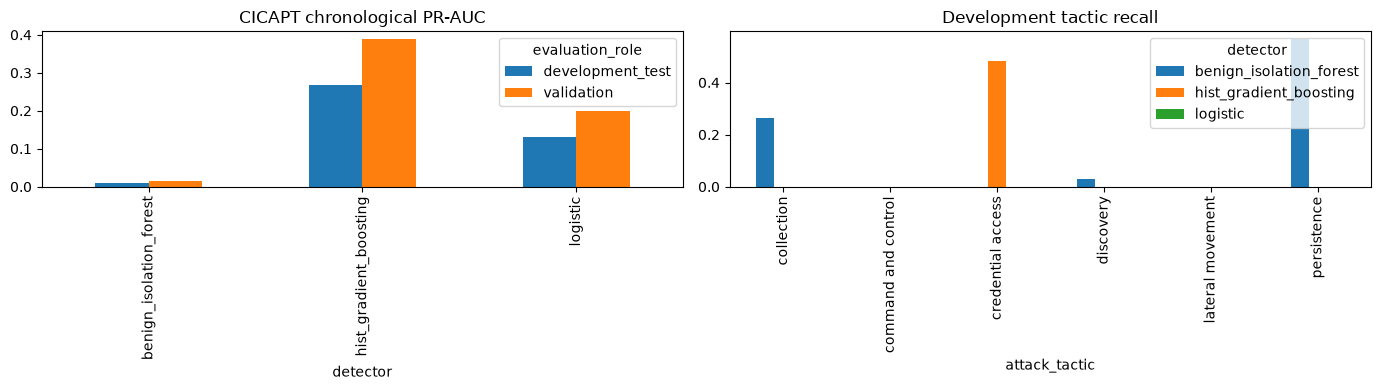

Result: HistGradientBoosting leads with 0.390 validation and 0.268 development PR-AUC; development recall is 9.15%.
Interpretation: early collection behavior does not generalize to most later APT tactics.
Expected/unusual: zero recall for unseen tactics is expected under strict chronology.
Implication: RL is blocked until detector uncertainty and provenance fusion improve evidence.
Recommended action: add provenance-only and leakage-safe late-fusion detectors.
Locked final rows scored: 0


In [67]:
cicapt_metrics = pd.read_csv(CICAPT_OUT / 'detector_temporal_metrics.csv')
cicapt_tactics = pd.read_csv(CICAPT_OUT / 'detector_tactic_recall.csv')
cicapt_status = json.loads((CICAPT_OUT / 'benchmark_status.json').read_text())
display(cicapt_metrics)
display(cicapt_tactics)
fig, axes = plt.subplots(1,2,figsize=(14,4))
cicapt_metrics.pivot(index='detector',columns='evaluation_role',values='pr_auc').plot.bar(ax=axes[0],title='CICAPT chronological PR-AUC')
cicapt_tactics.query("evaluation_role == 'development_test'").pivot(index='attack_tactic',columns='detector',values='recall').plot.bar(ax=axes[1],title='Development tactic recall')
plt.tight_layout(); plt.show()
print('Result: HistGradientBoosting leads with 0.390 validation and 0.268 development PR-AUC; development recall is 9.15%.')
print('Interpretation: early collection behavior does not generalize to most later APT tactics.')
print('Expected/unusual: zero recall for unseen tactics is expected under strict chronology.')
print('Implication: RL is blocked until detector uncertainty and provenance fusion improve evidence.')
print('Recommended action: add provenance-only and leakage-safe late-fusion detectors.')
print('Locked final rows scored:', cicapt_status['locked_rows_scored'])

## 65 — Downloaded feature-code inheritance audit

Seven dataset-supplied Python modules were inspected statically without executing them. Their feature names and formulas provide extractor provenance, but unsafe orchestration and incomplete helpers are not imported into the production pipeline. Reused behavior is independently implemented and tested.

In [68]:
source_audit = pd.read_csv(CICAPT_OUT / 'downloaded_source_audit.csv')
schema_audit = json.loads((CICAPT_OUT / 'downloaded_feature_schema_audit.json').read_text())
display(source_audit[['file','risks','safe_to_execute','reuse_policy']])
display(pd.Series(schema_audit, name='published feature-schema correspondence'))
print('Result: all 12 audited reference feature names exist in the real phase-2 CSV; three scripts contain execution risks.')
print('Interpretation: supplied code establishes feature provenance but is not production-quality runtime code.')
print('Expected/unusual: shell execution and temporary-file deletion are normal for an extractor script but unsafe inside a notebook pipeline.')
print('Implication: use the released CSV now; port only small formulas behind tests if PCAP re-extraction becomes necessary.')
print('Recommended action: retain static audit, pin dpkt/scapy versions, and build a sandboxed extractor parity test before touching PCAPs.')

,file,risks,safe_to_execute,reuse_policy
0,Communication_features.py,[],True,reviewed functions may be independently ported
1,Connectivity_features.py,"[""broad_except""]",False,schema/formula reference only
2,Dynamic_features.py,[],True,reviewed functions may be independently ported
3,Feature_extraction.py,"[""broad_except"", ""wildcard_import""]",False,schema/formula reference only
4,Generating_dataset.py,"[""broad_except"", ""file_deletion"", ""shell_execu...",False,schema/formula reference only
5,Layered_features.py,[],True,reviewed functions may be independently ported
6,Supporting_functions.py,[],True,reviewed functions may be independently ported


expected_reference_features    [Drate, Header_Length, IAT, Magnitue, Radius, ...
present_in_phase2              [Drate, Header_Length, IAT, Magnitue, Radius, ...
missing_from_phase2                                                           []
phase2_columns                                                                70
Name: published feature-schema correspondence, dtype: object

Result: all 12 audited reference feature names exist in the real phase-2 CSV; three scripts contain execution risks.
Interpretation: supplied code establishes feature provenance but is not production-quality runtime code.
Expected/unusual: shell execution and temporary-file deletion are normal for an extractor script but unsafe inside a notebook pipeline.
Implication: use the released CSV now; port only small formulas behind tests if PCAP re-extraction becomes necessary.
Recommended action: retain static audit, pin dpkt/scapy versions, and build a sandboxed extractor parity test before touching PCAPs.


## 66 — Network versus provenance versus late fusion

Both modalities are independently aggregated into one-minute chronological campaign windows and joined only by time. Labels, tactics, campaign steps and split roles remain hidden metadata. Dec 4 remains unscored.

,modality,calibration,evaluation_role,rows,attacks,pr_auc,precision,recall,brier,ece
0,network_only,raw,validation,1440,59,0.136876,0.076923,0.050847,0.055132,0.060662
1,network_only,raw,development_test,1440,44,0.056726,0.020408,0.022727,0.048593,0.056102
2,network_only,platt_validation_fit,development_test,1440,44,0.056726,0.000000,0.000000,0.029761,0.010484
3,provenance_only,raw,validation,1440,59,0.034584,0.032727,0.305085,0.309376,0.390360
4,provenance_only,raw,development_test,1440,44,0.028429,0.040268,0.136364,0.127222,0.192502
5,provenance_only,platt_validation_fit,development_test,1440,44,0.069885,0.000000,0.000000,0.029797,0.013931
6,late_fusion,raw,validation,1440,59,0.115047,0.113636,0.084746,0.055235,0.066206
7,late_fusion,raw,development_test,1440,44,0.075516,0.120000,0.068182,0.040060,0.048330
8,late_fusion,platt_validation_fit,development_test,1440,44,0.075516,0.000000,0.000000,0.029584,0.009761


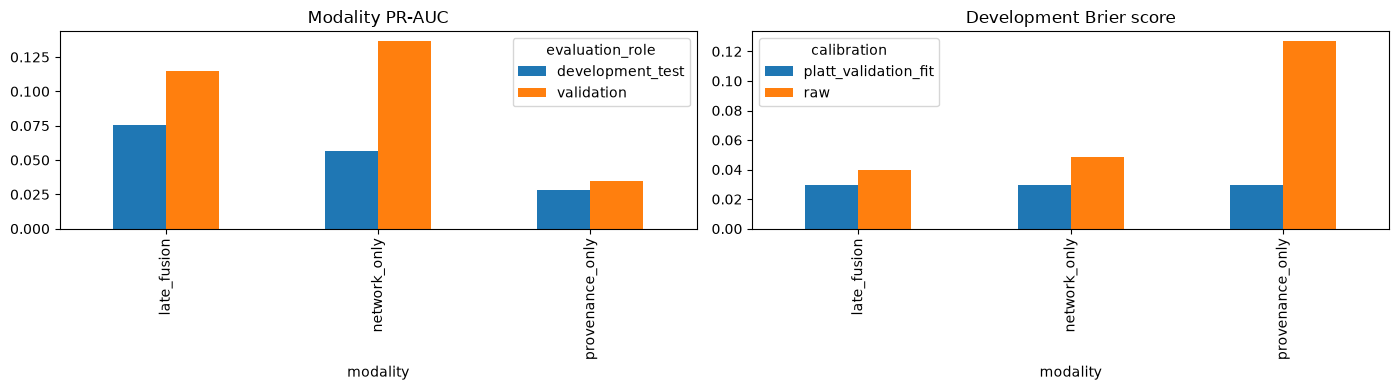

Result: late fusion leads development PR-AUC at 0.0755, versus 0.0567 network-only and 0.0284 provenance-only.
Interpretation: provenance adds ranking signal, but absolute quality remains poor.
Expected/unusual: Platt calibration improves Brier/ECE while the 0.5 threshold collapses recall to zero.
Implication: probability calibration and operational threshold selection are separate decisions.
Recommended action: improve graph features and select a recall-constrained validation threshold.
Locked final rows scored: 0


In [69]:
fusion_metrics = pd.read_csv(CICAPT_OUT / 'fusion_modality_metrics.csv')
fusion_manifest = json.loads((CICAPT_OUT / 'fusion_manifest.json').read_text())
display(fusion_metrics)
fig,axes=plt.subplots(1,2,figsize=(14,4))
fusion_metrics.query("calibration == 'raw'").pivot(index='modality',columns='evaluation_role',values='pr_auc').plot.bar(ax=axes[0],title='Modality PR-AUC')
fusion_metrics.query("evaluation_role == 'development_test'").pivot(index='modality',columns='calibration',values='brier').plot.bar(ax=axes[1],title='Development Brier score')
plt.tight_layout(); plt.show()
print('Result: late fusion leads development PR-AUC at 0.0755, versus 0.0567 network-only and 0.0284 provenance-only.')
print('Interpretation: provenance adds ranking signal, but absolute quality remains poor.')
print('Expected/unusual: Platt calibration improves Brier/ECE while the 0.5 threshold collapses recall to zero.')
print('Implication: probability calibration and operational threshold selection are separate decisions.')
print('Recommended action: improve graph features and select a recall-constrained validation threshold.')
print('Locked final rows scored:', fusion_manifest['locked_final_rows_scored'])

## 67 — Calibrated attack-tactic belief state

Late-fusion evidence becomes a fixed tactic-probability vector plus normal probability, history smoothing and uncertainty. Missing training tactics retain explicit zero entries. True tactics remain evaluation-only.

In [70]:
belief_metrics = json.loads((CICAPT_OUT / 'tactic_belief_metrics.json').read_text())
beliefs = pd.read_parquet(CICAPT_OUT / 'development_tactic_beliefs.parquet')
display(pd.Series(belief_metrics,name='development tactic-belief quality'))
display(beliefs.groupby(['true_tactic','predicted_tactic']).size().rename('windows').reset_index())
print('Result: overall top-1 accuracy is 96.88%, but attack-window macro-F1 is only 0.0168.')
print('Interpretation: normal-window dominance makes accuracy flattering; tactic recognition is nearly absent.')
print('Expected/unusual: mean uncertainty is only 0.007 despite poor attack F1, revealing overconfidence.')
print('Implication: this belief state is not safe enough for disruptive policy training.')
print('Recommended action: add OOD/unknown-tactic mass and calibrate uncertainty before policy comparison.')

development_windows                        1440
attack_windows                               44
top1_accuracy                           0.96875
attack_macro_f1                        0.016807
mean_uncertainty                       0.007003
locked_final_rows_scored                      0
fit_roles                   [train, validation]
evaluation_role                development_test
Name: development tactic-belief quality, dtype: object

,true_tactic,predicted_tactic,windows
0,collection,command_and_control,2
1,collection,normal,3
2,command_and_control,command_and_control,1
3,command_and_control,normal,3
4,credential_access,command_and_control,4
5,credential_access,normal,4
6,discovery,command_and_control,4
7,discovery,normal,16
8,lateral_movement,command_and_control,1
9,lateral_movement,normal,3


Result: overall top-1 accuracy is 96.88%, but attack-window macro-F1 is only 0.0168.
Interpretation: normal-window dominance makes accuracy flattering; tactic recognition is nearly absent.
Expected/unusual: mean uncertainty is only 0.007 despite poor attack F1, revealing overconfidence.
Implication: this belief state is not safe enough for disruptive policy training.
Recommended action: add OOD/unknown-tactic mass and calibrate uncertainty before policy comparison.


## 68 — Policy gate after multimodal evidence

The multimodal milestone is complete, but the policy gate remains closed. Rules, optimal stopping, LinUCB, DQN and constrained PPO will only be compared after the shared belief vector passes attack-recall, uncertainty and calibration gates.

In [71]:
policy_gate = {'network_vs_provenance_vs_fusion':'COMPLETE','best_development_modality':'late_fusion','best_development_pr_auc':0.07551552824412,'tactic_attack_macro_f1':belief_metrics['attack_macro_f1'],'mean_uncertainty':belief_metrics['mean_uncertainty'],'uncertainty_behavior':'FAIL — overconfident errors','Dec4_holdout':'LOCKED — 0 rows scored','RL_training':'BLOCKED','next_experiment':'graph structural features + OOD-aware tactic belief'}
display(pd.Series(policy_gate,name='CICAPT policy-readiness gate'))
print('Result: sequential RL has not yet earned access to the real CICAPT evidence stream.')
print('Interpretation: weak beliefs make policy comparisons measure detector-error propagation.')
print('Expected/unusual: the framework correctly blocks progress despite a small fusion gain.')
print('Implication: detector and uncertainty work remain the critical path.')
print('Recommended action: implement graph-neighborhood features and unknown-tactic abstention, then rerun this gate.')

network_vs_provenance_vs_fusion                                             COMPLETE
best_development_modality                                                late_fusion
best_development_pr_auc                                                     0.075516
tactic_attack_macro_f1                                                      0.016807
mean_uncertainty                                                            0.007003
uncertainty_behavior                                     FAIL — overconfident errors
Dec4_holdout                                                  LOCKED — 0 rows scored
RL_training                                                                  BLOCKED
next_experiment                    graph structural features + OOD-aware tactic b...
Name: CICAPT policy-readiness gate, dtype: object

Result: sequential RL has not yet earned access to the real CICAPT evidence stream.
Interpretation: weak beliefs make policy comparisons measure detector-error propagation.
Expected/unusual: the framework correctly blocks progress despite a small fusion gain.
Implication: detector and uncertainty work remain the critical path.
Recommended action: implement graph-neighborhood features and unknown-tactic abstention, then rerun this gate.
